# 자금세탁 탐지 AI — 방향 그래프 GNN 엣지 분류 **v9 (원인 해결 + 벤치마크)**

v8 「일반화 강화 2차」의 실행 결과에서 **반드시 해결해야 할 원인 3가지**를 정면으로 처리하고,
그 위에 벤치마크 상위권을 노리는 기법 후보들을 **검증(val) PR-AUC로만 채택 여부를 결정**하는 방식으로 얹은 버전입니다.

### v8 → v9 대응표 (요청사항 §1 · 원인 해결)

| # | v8에서 확인된 원인 | v9에서 한 일 | 위치 |
|---|---|---|---|
| **1-1** | `MegaConv` 가 fp32 로 모은 `agg` 를 `agg.to(msg.dtype)` 로 fp16 으로 되돌리면서 허브 계좌(`max|agg| ≈ 2.6 × 수신차수`)가 fp16 상한 65,504 를 넘어 NaN → v8 일반화판은 `USE_AMP=False` 로 **회피**만 한 상태 | ① `AMP_DTYPE` **bf16 우선** 자동 선택(지수 범위가 fp32와 동일 → 오버플로 원천 차단), fp16 은 폴백 ② **fp16 폴백일 때만** 캐스팅 직전 `clamp(-lim, lim)` ③ 레이어별 `max|agg|` **여유율을 에폭마다 학습 로그에 기록**하고 임계 초과 시 경고 ④ 안전장치 ON/OFF **A/B 로 val PR-AUC 동일성 확인** | §4 · §9-2 · §10 · §10-1 · §10-4 |
| **1-2** | GBT 대조군의 `class_weight` 를 GNN 스윕이 고른 `POS_WEIGHT_CAP` 에 종속시킴 → v8에서 cap 5 가 그대로 물려 GBT test PR-AUC 0.5022(v6) → **0.2837 로 붕괴**, "그래프 순수 기여분 +0.3119" 가 신뢰 불가 | ① GBT 가중치를 **완전 독립 변수**(`GBT_POS_WEIGHT`)로 분리하고 **GBT 전용 탐욕 스윕**(가중치/학습률/잎 수/L2/반복수)을 val PR-AUC 로 실행 ② GBT 입력이 GNN `EDGE_FEATURES` 와 **동일한지 코드로 검증**하고 GNN 만 추가로 보는 입력을 명시 ③ **GBT-B**(+계좌 전역 이력 피처) 대조군을 추가해 기여분을 2단 분해 ④ v6(+0.0720)·v8(+0.3119)과 나란히 비교 | §14 |
| **1-3** | 패턴 내 재현율 91.7% vs **패턴 밖 2.6%** (양성의 40.2%가 패턴 밖). 로컬 그래프 신호가 약한 고립 거래에서 GNN 강점이 발휘되지 않음 | ① **계좌 전역 이력 노드 피처**(학습 구간 전체 통계, 윈도우 밖 장기 신호) ② **focal loss / hard-example 가중** ③ **하이브리드 스코어링**(Isolation Forest·비그래프 GBT 결합, 결합 가중치도 val 로 선택) ④ **모든 ablation 행이 패턴 내/밖 재현율을 분리 보고** | §7-4 · §10 · §12-3 · §13-3 · §14-4 |

### 요청사항 §2 — 벤치마크 후보 (전부 강제 적용 아님, val PR-AUC 로 채택 결정)

| 후보 | 구현 | 채택 결정 |
|---|---|---|
| **PNA 스타일 다중 집계자** (sum/mean/max/std concat) | `MegaConv(aggrs=...)` — 2단계 집계의 ②(이웃 집계)를 다중 집계자로 확장 후 선형 사영 | §10-3 스윕 축 |
| **Ego-ID 피처** (Egressy et al. AAAI 2024) | 윈도우 단위 적응형 — "이 계좌가 이번 분류 대상 구간에 등장하는가 / 대상 차수" 2종을 노드 피처로. 포트 번호는 이미 반영돼 있어 **결합 효과를 별도 측정** | §10-3 스윕 축 |
| **양방향 엣지 업데이트 강도** | 역방향 메시지 전달은 유지하고 역방향 기여도 `REV_EDGE_W ∈ {1.0, 0.5, 0.0}` 를 스윕 (0.0 = 역방향 제거 ablation) | §10-3 스윕 축 |
| **Persistent account state** | 학습 구간 전체에 걸쳐 계좌 상태 벡터(`PERSIST_DIM`)를 유지 — 메모리/복잡도 트레이드오프를 §9-2 에 수치로 명시 | §10-3 스윕 축 |
| **앙상블 개수 대비 이득/비용** | 1~4시드 앙상블의 성능·파라미터·지연을 한 표로 | §12-4 |
| **타 세트 zero-shot 전이** | `LI-Small` 파일이 있으면 자동 실행 (없으면 스킵 후 §20에 미해결로 명시) | §15 |

### 반드시 지킨 원칙

1. **모든 채택 결정은 val PR-AUC로만.** test 컬럼은 표기만 하고 선택에 절대 쓰지 않습니다(선택 편향 금지).
2. **새로 추가한 모든 장치는 ON/OFF ablation 비교표를 남깁니다.** "추가했다"가 아니라 "얼마나 좋아졌는지 숫자로".
3. **해결 안 된 것은 §20 「여전히 남은 것」에 숨기지 않고 명시**합니다.

### 코드 감사에서 잡아 고친 것 (v9 자체 검증)

v9는 작성 후 **누수 / 수치 / 실험 프로토콜 / 실환경(5.08M행·GPU)** 4개 축으로 코드 감사를 돌렸고,
지적 27건 중 반증을 통과한 4건을 반영했습니다.

| 심각도 | 무엇이 틀렸었나 | 어떻게 고쳤나 |
|---|---|---|
| **높음** | clamp 발동 조건을 `msg.dtype` 으로 판단 → `LayerNorm` 이 autocast fp32 목록이라 **2번째 conv 부터 clamp 가 죽어** 있었음. 저정밀 캐스팅은 사라진 게 아니라 뒤따르는 `Linear` 안으로 옮겨간 것이라 **오버플로가 가장 큰 레이어가 무방비** → v8 크래시가 그대로 재현됨 | `autocast_lowp()` 로 **주변 autocast dtype** 을 직접 조회해 판단 (§9-2). 30k 차수 허브로 검증: 수정 전 logit NaN → 수정 후 유한, fp32 경로는 clamp on/off **비트 단위 동일** |
| **높음** | §13-3 LOO 의 "미채택" 행이 *스윕 전체 최댓값* vs *최종 구성* 을 비교 → 최대 8개 축이 동시에 달라 교란되고, 최종 구성이 스윕의 argmax 라 **Δval 이 구조적으로 항상 ≤ 0** | 시행 행에 `_base`(1축만 바꾸기 전 구성)를 기록해 **같은 단계의 1축 짝**만 인용 (§10-3·§13-3) |
| 중간 | `acct_state` 가 `persistent=False` 버퍼라 `best_state` 에 없음 → best 에폭 가중치 + **마지막 에폭 계좌상태** 라는 존재하지 않는 모델로 val/test 확률을 계산 (선택 기준과 보고 수치 불일치) | best 에폭에서 `acct_state` 도 스냅샷·복원하고 체크포인트에 함께 저장 (§10·§19) |
| 중간 | GBT 스윕이 기준 가중치를 중복 적합 (적합 1회 ≈ 3~4분) | 설정 키 기준 메모이제이션 (§14-2) |

> **[v9 정리]** v8 노트북은 §4 설정 셀 뒤에 임시 셀(`USE_AMP=False`, `LR=5e-4`, `GRAD_CLIP=1.0`)이 붙어
> 실제 실행값이 설정 셀과 달랐습니다. v9는 **실제 실행에 쓰인 값(LR 5e-4 / GRAD_CLIP 1.0)을 §4 에 정식 반영**하고
> 임시 셀을 제거했습니다. `HIDDEN/N_LAYERS/AUX_NODE_W/MSG_DROPOUT` 기본값도 v8 §10-3 이 val 기준으로
> 고른 `256 / 2 / 0.6 / 0.1` 을 출발점으로 씁니다.


## ⚠️ 화두 결론대로 진행할 때의 위험성 경고 (v9 갱신)

| 화두 결론 | 잠재 위험 | 완화책 (v9 기준) |
|---|---|---|
| **거래 1건씩 판정** (화두1) | 세탁은 여러 거래가 모인 *패턴* 현상 → 개별 거래 라벨은 노이즈가 크고, 고립 거래는 그래프 신호 자체가 약함 | 계좌 보조 헤드 + §12-2 계좌 단위 판정 + §12-3 시나리오 단위 평가 + **[v9] 전역 계좌 이력 피처·focal·하이브리드 스코어링** 으로 5중 완화 |
| **분 단위 배치** (화두2) | 거래 급증 시 배치가 커져 지연 SLA 위반 가능 | §18 배치 크기별 지연 측정 + **[v9] §12-4 앙상블 개수별 지연/이득 표** |
| **사후 탐지** (화두3) | 자금 이탈 후 탐지 → 동결 실효성↓ | §12-3 탐지 지연(체인 내 첫 적발 순번) 분포 모니터링 |
| **통화별 개별 표준화** (화두8) | 희소 통화의 불안정한 z-score | 희소 통화는 전체 통계로 폴백 |
| **로그 변환만, 극단값 방치** (화두9) | 초고액 이상치가 손실을 지배 | z-score 완화 + **[v9] focal loss 옵션이 쉬운 샘플 비중을 줄임** |
| **절대시간 제거, 순서만** (화두10·17) | 시간대 신호 손실 | 상대 Δt·최근 빈도만 도입(§7-3), §13-2 제거 A/B 로 의존도 수치화 |
| **완전 동일 중복 제거** (화두11) | 반복 송금 자체가 신호일 수 있음 | 제거 건수 로그. v9도 **미반영** — §20 남은 것에 유지 |
| **세트 미통합** (화두7) | 타 분포 일반화 검증 불가 | §15 zero-shot 전이 (파일 있을 때만). **없으면 §20에 미해결로 명시** |
| **혼합정밀(AMP)** | fp16 집계 오버플로 → NaN 크래시 (v8에서 실제 발생) | **[v9] bf16 우선 + fp16 clamp + 여유율 상시 로깅 + 안전장치 A/B** (§1-1) |
| **[v9] 전역 계좌 이력 피처** | train 구간 통계를 val/test 계좌에도 적용 → 미등장 계좌는 전부 0 | `g_seen` 플래그로 "이력 없음"을 모델에 명시. train 라벨/미래 정보는 일절 사용하지 않음(§7-4에서 검증 출력) |
| **[v9] focal loss** | γ 가 크면 라벨 노이즈가 있는 어려운 양성에 과적합 | γ 를 스윕 축으로 두고 **val 기준으로만** 채택. 미채택 시 BCE 유지 |
| **[v9] 하이브리드 스코어링** | 비그래프 보조 모델이 GNN 점수를 희석 | 결합 가중치를 val PR-AUC 로 선택하고 **w=0(순수 GNN)도 후보에 포함** → 이득이 없으면 자동으로 GNN 단독 선택 |
| **[v9] persistent account state** | 상태 버퍼 메모리 + 창 순서 의존성 | 학습(`model.train()`) 중에만 갱신하고 평가에서는 **읽기 전용** → 미래 정보 역류 차단. 메모리 비용은 §9-2에 수치로 표기 |
| **시드 앙상블** | 모델 4개 서빙 → 지연·운영비 증가 | **[v9] §12-4 개수별 이득/비용 표**로 필요한 개수만 쓰도록 |


## 4. 환경 설정


In [1]:
# 최초 1회만 실행하세요 (주석 해제 후):
%pip install pandas numpy matplotlib networkx scikit-learn torch --break-system-packages

import importlib
for pkg in ["pandas", "numpy", "matplotlib", "networkx", "sklearn", "torch"]:
    try:
        m = importlib.import_module(pkg)
        print(f"[OK] {pkg} {getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"[없음] {pkg} — 위 설치 셀을 실행하세요")


Note: you may need to restart the kernel to use updated packages.
[OK] pandas 3.0.5
[OK] numpy 2.5.2
[OK] matplotlib 3.11.1
[OK] networkx 3.6.1
[OK] sklearn 1.9.0
[OK] torch 2.10.0+cu126


In [2]:
import json, os, random, time, warnings, zipfile
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score)

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ============================= 설정 =============================
ZIP_PATH = Path("IBM_AML_dataset/archive (2).zip")
DATASET  = "HI-Small"        # 학습 세트. 화두7 검증은 §15 전이 평가에서 수행
MAX_ROWS = None

TRAIN_FRAC, VAL_FRAC = 0.6, 0.2
TAIL_MIN_FRAC = 0.05

# --- v6 구조 (유지) ---
WINDOW_SIZE   = 100_000
CONTEXT_EDGES = 100_000
USE_TIME_FEATS = True
USE_PORTS      = True
USE_MEGA       = True
NODE_FEAT_DIM  = 9           # 창-로컬 노드 피처 개수 (4 또는 9 — §13 ablation 사다리에서만 4로 내림)

# --- 학습 하이퍼파라미터 ---
#   [v9 정리] v8은 §4 뒤 임시 셀에서 LR/GRAD_CLIP 을 덮어쓴 채 실행됐습니다.
#   여기서는 v8이 **실제로 실행한 값**을 정식 기본값으로 반영합니다.
HIDDEN, N_LAYERS, DROPOUT = 256, 2, 0.15   # v8 §10-3 이 val 기준으로 고른 구성 = v9 출발점
LR, WEIGHT_DECAY = 5e-4, 1e-5
EPOCHS, PATIENCE = 60, 8
POS_WEIGHT_CAP = 5.0         # §10-2 스윕이 켜져 있으면 val 기준으로 갱신됨 (GNN 전용 — GBT와 무관)
GRAD_CLIP = 1.0

SEED_LIST = [0, 1, 2, 3]
SEED = SEED_LIST[0]
ALERT_BUDGET = 0.001         # 경보 예산: 전체 거래의 0.1%만 조사 인력에 이관 가정

# --- 계좌 보조 헤드 (v7~v8 유지) ---
USE_NODE_AUX = True
AUX_NODE_W   = 0.6           # v8 §10-3 선택값
MSG_DROPOUT  = 0.1           # v8 §10-3 선택값 (DropMessage)
AUX_LABEL_SCOPE = "train_global"   # "window" | "train_global"

# ══════════════════ [v9 · 1-1] AMP / NaN 근본 해결 ══════════════════
# 원인: MegaConv 는 집계를 fp32(index_add_)로 하지만 마지막에 `agg.to(msg.dtype)` 로 저정밀로
#       되돌립니다. sum 집계라 허브 계좌에서 max|agg| ≈ 2.6 × (수신 차수) 이고 학습이 진행되면
#       이 계수가 계속 커집니다. fp16 상한 65,504 를 넘는 순간 inf → MLP → LayerNorm 을 타고
#       전체 NaN → 한참 뒤 average_precision_score 에서 "Input contains NaN" 으로 터집니다.
USE_AMP = True               # [v9] 다시 켭니다 (v8 일반화판은 False 로 회피만 했음)
#  1순위: bf16 — 지수 범위가 fp32와 같아 오버플로가 원천적으로 사라집니다(Ampere 이상).
#         V100/T4 등 미지원 GPU 는 fp16 으로 폴백합니다.
AMP_DTYPE = (torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported())
             else torch.float16)
#  2순위(fp16 폴백일 때만 동작): 저정밀 캐스팅 직전에 집계값을 잘라내는 안전장치.
AGG_CLAMP      = True
AGG_CLAMP_FRAC = 0.25        # 상한의 25% 지점에서 clamp (fp16 → 약 16,376)
AMP_HEADROOM_WARN = 0.25     # 에폭 로그에서 여유율이 이 값을 넘으면 경고 출력
RUN_AMP_DIAG = True          # §10-1 오버플로 진단 (3스텝 계측)
RUN_AMP_AB   = True          # §10-4 안전장치 ON/OFF A/B (fp16 강제, 성능 동일성 확인)
AMP_AB_EPOCHS = 15           # A/B 는 짧은 동일 프로토콜로 비교 (양팔 완전히 동일 조건)

# ══════════════════ [v9 · 1-3] 패턴 밖(out-of-pattern) 재현율 ══════════════════
USE_GLOBAL_ACCT_FEATS = True   # ① 계좌 전역(학습 구간 전체) 이력 노드 피처 — §10-3 스윕이 최종 결정
LOSS_TYPE   = "bce"            # ② "bce" | "focal" — §10-3 스윕이 결정 (임의 기본값 금지)
FOCAL_GAMMA = 1.0
RUN_HYBRID  = True             # ③ 하이브리드 스코어링 (Isolation Forest / 비그래프 GBT 결합)
HYBRID_W_GRID = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]   # w=0(순수 GNN)도 후보 — 이득 없으면 자동 기각
IFOREST_FIT_ROWS = 200_000     # Isolation Forest 학습 표본 (train 구간에서 균등 추출)

# ══════════════════ [v9 · §2] 벤치마크 후보 ══════════════════
PNA_AGGRS   = ("sum",)         # ("sum",) | ("sum","mean","max","std") — §10-3 스윕이 결정
USE_EGO_ID  = False            # Ego-ID(윈도우 적응형) 노드 피처 — 스윕이 결정
REV_EDGE_W  = 1.0              # 역방향 메시지·엣지 업데이트 강도 — 스윕이 결정 (0.0 = 역방향 제거)
PERSIST_DIM   = 0              # persistent account state 차원 (0 = 사용 안 함) — 스윕이 결정
PERSIST_ALPHA = 0.3            # 상태 EMA 갱신률

# ══════════════════ [v9 · 1-2] GBT 대조군 — GNN과 완전 분리된 독립 변수 ══════════════════
RUN_GBT_SWEEP   = True
GBT_POS_WEIGHT  = 15.0         # ★ POS_WEIGHT_CAP 과 무관한 독립 변수 (스윕이 val 기준으로 갱신)
GBT_W_GRID      = [1.0, 5.0, 15.0, 30.0, 50.0]
GBT_LR_GRID     = [0.05, 0.1, 0.2]
GBT_LEAF_GRID   = [31, 63, 127]
GBT_L2_GRID     = [0.0, 1.0, 10.0]
GBT_ITER_PATH   = [100, 200, 300, 500]   # warm_start 로 한 번의 적합 체인에서 전부 평가
RUN_GBT_B       = True         # GBT-B(+계좌 전역 이력 피처) 대조군 — 기여분 2단 분해용

# --- 스윕 / 실험 플래그 ---
RUN_POS_SWEEP = True;  POS_CAP_SWEEP = [5.0, 15.0, 30.0]
RUN_HP_SWEEP  = True
HP_STAGES = [
    ("HIDDEN",      [128, 256]),                       # 용량
    ("N_LAYERS",    [2, 3]),                           # 수용 영역
    ("AUX_NODE_W",  [0.3, 0.6]),                       # 계좌 보조 손실
    ("MSG_DROPOUT", [0.0, 0.1]),                       # 전파 정규화
    ("GLOBAL_ACCT", [False, True]),                    # [v9 1-3 ①] 전역 계좌 이력 피처
    ("LOSS",        ["bce", "focal1.0", "focal2.0"]),  # [v9 1-3 ②] focal / hard-example
    ("AGGRS",       ["sum", "pna4"]),                  # [v9 §2] PNA 다중 집계자
    ("EGO",         [False, True]),                    # [v9 §2] Ego-ID
    ("REV_W",       [1.0, 0.5, 0.0]),                  # [v9 §2] 양방향 엣지 업데이트 강도
    ("PERSIST",     [0, 32]),                          # [v9 §2] persistent account state
]
RUN_SCENARIO_EVAL = True
RUN_ABLATION = True          # §13 누적 사다리 (v5→v9)
RUN_V9_LOO   = True          # §13-3 v9 신규 장치 leave-one-out (최종 구성에서 하나씩 끄기)
RUN_TIME_AB  = True          # §13-2 상대 시간차 제거 A/B
RUN_TRANSFER = True;  TRANSFER_SETS = ["LI-Small"]

DRIFT_WARN, DRIFT_ALERT = 0.10, 0.20
PSI_WARN, PSI_ALERT     = 0.10, 0.25

# --- 빠른 확인용 프리셋 (기본 False — True 로 두면 격자·시드·에폭을 줄여 30분대에 1회전) ---
FAST_PRESET = True
if FAST_PRESET:
    SEED_LIST = [0, 1]; SEED = 0
    EPOCHS, PATIENCE = 25, 5
    POS_CAP_SWEEP = [5.0, 15.0]
    HP_STAGES = [s for s in HP_STAGES if s[0] in
                 ("GLOBAL_ACCT", "LOSS", "AGGRS", "EGO", "REV_W", "PERSIST")]
    GBT_LR_GRID = [0.1]; GBT_LEAF_GRID = [63]; GBT_L2_GRID = [1.0]
    GBT_ITER_PATH = [100, 200]
    RUN_ABLATION = False
    AMP_AB_EPOCHS = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {DEVICE}")
print(f"AMP: {'on' if USE_AMP else 'off'} / dtype={str(AMP_DTYPE).split('.')[-1]} "
      f"/ fp16 clamp={AGG_CLAMP}(frac {AGG_CLAMP_FRAC})")
if DEVICE.type == "cuda":
    print(f"  GPU={torch.cuda.get_device_name(0)} / bf16 지원={torch.cuda.is_bf16_supported()}")
print(f"윈도우 = 대상 {WINDOW_SIZE:,} + 과거 컨텍스트 {CONTEXT_EDGES:,}")
print(f"실험 플래그: pos={RUN_POS_SWEEP}, hp={RUN_HP_SWEEP}, ampAB={RUN_AMP_AB}, "
      f"ablation={RUN_ABLATION}, v9LOO={RUN_V9_LOO}, GBT스윕={RUN_GBT_SWEEP}(B={RUN_GBT_B}), "
      f"하이브리드={RUN_HYBRID}, 전이={RUN_TRANSFER}{TRANSFER_SETS}")


device = cuda
AMP: on / dtype=bfloat16 / fp16 clamp=True(frac 0.25)
  GPU=Tesla V100-SXM2-32GB / bf16 지원=True
윈도우 = 대상 100,000 + 과거 컨텍스트 100,000
실험 플래그: pos=True, hp=True, ampAB=True, ablation=False, v9LOO=True, GBT스윕=True(B=True), 하이브리드=True, 전이=True['LI-Small']


In [3]:
# 한글 폰트 (Linux 환경에서 1회)
import matplotlib.font_manager as fm
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if Path(_fp).exists():
    fm.fontManager.addfont(_fp)
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    print("✅ 한글 폰트 설정 완료")
else:
    print("나눔고딕 없음 — 필요 시: !apt-get install -y fonts-nanum")


✅ 한글 폰트 설정 완료


## 5. 데이터 로드 (zip 스트리밍 + 손상 진단 + CSV 폴백)

로드를 `load_transactions()` 함수로 분리했습니다 — §15 전이 평가가 같은 코드로 타 세트를 읽습니다.


In [4]:
# ---------- 데이터 소스 준비: zip 검증 → 실패 시 CSV 폴백 ----------
CSV_SEARCH_DIRS = [Path("IBM_AML_dataset"), Path("."), ZIP_PATH.parent]

zf = None
if ZIP_PATH.exists():
    size_mb = ZIP_PATH.stat().st_size / 1e6
    with open(ZIP_PATH, "rb") as fh:
        magic = fh.read(4)
    if magic[:2] == b"PK":
        try:
            zf = zipfile.ZipFile(ZIP_PATH)
            print(f"[zip 정상] {ZIP_PATH} ({size_mb:,.1f} MB)")
        except zipfile.BadZipFile:
            print(f"[zip 손상] {ZIP_PATH} ({size_mb:,.1f} MB) — 시작은 zip(PK)인데 끝부분이 없습니다.")
            print("  → 압축을 풀어 필요한 CSV만 IBM_AML_dataset/ 폴더에 올리세요(권장).")
    else:
        print(f"[zip 아님] {ZIP_PATH} ({size_mb:,.1f} MB), 시작 바이트 = {magic!r}")
else:
    print(f"[zip 없음] {ZIP_PATH.resolve()}")

def open_member(fname):
    '''zip이 정상이면 zip에서, 아니면 폴더들에서 압축 해제된 파일을 찾는다.'''
    if zf is not None:
        names = set(zf.namelist())
        if fname in names:
            return zf.open(fname)
        inner = [n for n in names if n.endswith("/" + fname)]
        if inner:
            return zf.open(inner[0])
    for d in CSV_SEARCH_DIRS:
        p = Path(d) / fname
        if p.exists():
            print(f"[파일 사용] {p}")
            return open(p, "rb")
    raise FileNotFoundError(
        f"'{fname}' 를 찾지 못했습니다. zip을 온전히 재업로드하거나, "
        f"압축 해제한 파일을 {[str(Path(d)) for d in CSV_SEARCH_DIRS]} 중 한 곳에 두세요.")


def load_transactions(ds, nrows=MAX_ROWS):
    '''세트 이름으로 거래 CSV를 로드 — 본학습(§5)과 전이 평가(§15)가 공유.'''
    with open_member(f"{ds}_Trans.csv") as f:
        d = pd.read_csv(
            f,
            dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str,
                   "Receiving Currency": "category", "Payment Currency": "category",
                   "Payment Format": "category", "Is Laundering": np.int8},
            nrows=nrows)
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], format="%Y/%m/%d %H:%M")
    return d


t0 = time.time()
df = load_transactions(DATASET)
print(f"{len(df):,}건 로드 ({time.time()-t0:.1f}s)")
df.head()


[zip 손상] IBM_AML_dataset/archive (2).zip (1,165.0 MB) — 시작은 zip(PK)인데 끝부분이 없습니다.
  → 압축을 풀어 필요한 CSV만 IBM_AML_dataset/ 폴더에 올리세요(권장).
[파일 사용] IBM_AML_dataset/HI-Small_Trans.csv
5,078,345건 로드 (8.2s)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,03209,8000F4670,03209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,012,8000F5030,012,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,010,8000F5200,010,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## 6. 전처리 ① — 중복 제거·정렬·꼬리 절단 (화두 10·11·17)

`clean_frame()` 함수로 분리 — §15 전이 평가가 타 세트에 동일 규칙을 적용합니다.


In [5]:
def clean_frame(raw, verbose=True):
    '''중복 제거 → 시각 정렬 → 꼬리 절단. (정제된 df, 메타) 반환. v6 §6과 동일 규칙.'''
    n_raw = len(raw)
    d = raw.drop_duplicates()
    n_dup = n_raw - len(d)
    d = d.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)

    daily = d["Timestamp"].dt.floor("D").value_counts().sort_index()
    thr_ = daily.median() * TAIL_MIN_FRAC
    good_days = daily[daily >= thr_].index
    ms, me = good_days.min(), good_days.max()

    day = d["Timestamp"].dt.floor("D")
    mask_main = (day >= ms) & (day <= me)
    lost_pos = int(d.loc[~mask_main, "Is Laundering"].sum())
    if verbose:
        print(f"중복 제거: {n_dup:,}건 삭제 ({n_dup/max(n_raw,1)*100:.3f}%)")
        print(f"주 기간: {ms.date()} ~ {me.date()}  "
              f"(절단 {int((~mask_main).sum()):,}건, 그중 세탁 라벨 {lost_pos}건 유실)")
    d = d[mask_main].reset_index(drop=True)
    if verbose:
        print(f"최종 {len(d):,}건, 세탁 비율 {d['Is Laundering'].mean()*100:.4f}%")
    return d, dict(daily_counts_all=daily, thr=thr_, main_start=ms, main_end=me,
                   lost_pos=lost_pos, n_dup=n_dup)


df, CLEAN_META = clean_frame(df)
daily_counts_all, thr = CLEAN_META["daily_counts_all"], CLEAN_META["thr"]
main_start, main_end = CLEAN_META["main_start"], CLEAN_META["main_end"]
n = len(df)


중복 제거: 9건 삭제 (0.000%)
주 기간: 2022-09-01 ~ 2022-09-10  (절단 1,108건, 그중 세탁 라벨 655건 유실)
최종 5,077,228건, 세탁 비율 0.0891%


## 7. 전처리 ② — 피처 엔지니어링

피처 생성을 `add_base_features()` / `add_time_features()` / **[v9] `build_global_acct_feats()`** 로 분리했습니다.
§15 전이 평가는 **학습 세트의 범주 어휘(pf/pc/rc)** 를 그대로 넘겨 입력 차원을 일치시킵니다.


In [6]:
df["order_idx"] = np.arange(n, dtype=np.int64)

n_tr = int(n * TRAIN_FRAC)
n_va = int(n * (TRAIN_FRAC + VAL_FRAC))
split = np.full(n, "test", dtype=object)
split[:n_tr] = "train"; split[n_tr:n_va] = "val"
df["split"] = split
is_train = df["split"].eq("train").to_numpy()
print(f"train {n_tr:,} / val {n_va-n_tr:,} / test {n-n_va:,}")

src_key = df["From Bank"].astype(str) + "_" + df["Account"].astype(str)
dst_key = df["To Bank"].astype(str) + "_" + df["Account.1"].astype(str)
codes, uniques = pd.factorize(pd.concat([src_key, dst_key], ignore_index=True))
df["src_id"] = codes[:n].astype(np.int64)
df["dst_id"] = codes[n:].astype(np.int64)
NUM_ACCOUNTS = len(uniques)
print(f"계좌(노드) 수: {NUM_ACCOUNTS:,}")

df["self_loop"] = (df["src_id"] == df["dst_id"]).astype(np.float32)
print(f"자기송금: {int(df['self_loop'].sum()):,}건 유지")


train 3,046,336 / val 1,015,446 / test 1,015,446
계좌(노드) 수: 515,078
자기송금: 590,819건 유지


In [7]:
def add_base_features(d, is_tr, cats=None):
    '''기본 엣지 피처 (v6 §7과 동일 수식).

    is_tr : 통계 적합에 쓸 train 마스크 (누수 차단).
    cats  : (pf, pc, rc) 범주 어휘. None이면 train에서 적합, 주어지면(전이 평가) 그대로 사용.
    반환   : (피처가 추가된 d, 기본 피처 이름 목록, (pf, pc, rc) 어휘)
    '''
    def per_currency_z(amount_col, currency_col):
        # (화두 8·9) 통화별 log1p → z-score. train 통계만 사용, 희소/미등장 통화는 전체 통계로 폴백.
        la = np.log1p(d[amount_col].clip(lower=0).to_numpy(dtype=np.float64))
        cur = d[currency_col].astype(str)
        s = pd.DataFrame({"cur": cur, "la": la})
        st = s[is_tr].groupby("cur")["la"].agg(["mean", "std"])
        st["std"] = st["std"].replace(0, np.nan)
        g_mean, g_std = s.loc[is_tr, "la"].mean(), s.loc[is_tr, "la"].std()
        m_ = cur.map(st["mean"]).astype(np.float64).fillna(g_mean).to_numpy()
        sd = cur.map(st["std"]).astype(np.float64).fillna(g_std).to_numpy()
        return ((la - m_) / sd).astype(np.float32)

    d["amt_paid_z"] = per_currency_z("Amount Paid", "Payment Currency")
    d["amt_recv_z"] = per_currency_z("Amount Received", "Receiving Currency")
    d["cur_mismatch"] = (d["Payment Currency"].astype(str) != d["Receiving Currency"].astype(str)).astype(np.float32)
    d["amt_neq"] = (d["Amount Paid"] != d["Amount Received"]).astype(np.float32)

    def onehot(col, prefix, fixed, max_cats=20):
        cs = fixed if fixed is not None else d.loc[is_tr, col].astype(str).value_counts().index[:max_cats].tolist()
        v = d[col].astype(str)
        return pd.DataFrame({f"{prefix}_{c}": (v == c).astype(np.float32) for c in cs}, index=d.index), list(cs)

    pf_oh, pf_c = onehot("Payment Format", "pf", cats[0] if cats else None)
    pc_oh, pc_c = onehot("Payment Currency", "pc", cats[1] if cats else None)
    rc_oh, rc_c = onehot("Receiving Currency", "rc", cats[2] if cats else None)
    d = pd.concat([d, pf_oh, pc_oh, rc_oh], axis=1)

    # (화두 10) 순서 기반 시퀀스/간격 — 과거 방향만 사용
    nloc = len(d)
    logN = np.log1p(nloc)
    for role, key in [("src", "src_id"), ("dst", "dst_id")]:
        g = d.groupby(key)["order_idx"]
        d[f"{role}_seq"] = (np.log1p(g.cumcount()) / logN).astype(np.float32)
        prev = g.shift(1)
        d[f"{role}_first"] = prev.isna().astype(np.float32)
        d[f"{role}_gap"] = (np.log1p((d["order_idx"] - prev).fillna(nloc)) / logN).astype(np.float32)

    base = (["amt_paid_z", "amt_recv_z", "cur_mismatch", "amt_neq", "self_loop",
             "src_seq", "src_first", "src_gap", "dst_seq", "dst_first", "dst_gap"]
            + list(pf_oh.columns) + list(pc_oh.columns) + list(rc_oh.columns))
    return d, base, (pf_c, pc_c, rc_c)


df, BASE_FEATURES, (PF_CATS, PC_CATS, RC_CATS) = add_base_features(df, is_train)
print(f"기본 엣지 피처 {len(BASE_FEATURES)}차원")


기본 엣지 피처 48차원


### 7-3. 상대 시간차 피처 — 화두 10 재논의 반영

절대시각(시·요일·날짜)은 **여전히 쓰지 않고** 계좌·계좌쌍별 Δt와 최근 1h/24h 빈도만 도입합니다.

| 피처 | 의미 | AML 근거 |
|---|---|---|
| `src_dt`, `dst_dt` | 해당 계좌의 **직전 거래로부터 경과 시간** (log 정규화) | 휴면 계좌의 갑작스러운 활성화 |
| `pair_dt`, `pair_first` | **같은 (송→수) 쌍**의 직전 거래 경과 시간 / 첫 거래 여부 | 신규 상대방으로의 송금 |
| `out_cnt*`, `in_cnt*` | 최근 1시간·24시간 내 **보낸/받은 건수** | 팬아웃·팬인 속도 |
| `pair_cnt*` | 같은 쌍의 최근 반복 횟수 | 스머핑(분할 반복 송금) |

**누수 차단:** 모든 값은 `searchsorted(..., side="left")` 로 자기 자신·동시각 거래를 제외한 **과거만** 집계.
이 피처군의 의존도는 **§13-2 제거 A/B** 로 계속 수치화합니다.


In [8]:
def prior_stats(acct, tsec, windows):
    '''계좌(또는 계좌쌍)별 ① 직전 이벤트까지의 Δt ② 과거 W초 내 건수. 과거만 사용(누수 없음).'''
    K = np.int64(10_000_000)                       # 계좌 블록 분리용 (tsec < K 보장)
    keys = acct.astype(np.int64) * K + tsec
    skeys = np.sort(keys, kind="stable")
    pos = np.searchsorted(skeys, keys, side="left")            # 자기·동시각 제외
    prev_idx = pos - 1
    ok = prev_idx >= 0
    prev_key = np.where(ok, skeys[np.clip(prev_idx, 0, None)], -1)
    same = ok & ((prev_key // K) == acct.astype(np.int64))
    dt = np.where(same, tsec - (prev_key % K), -1).astype(np.float64)
    out = {"dt": dt, "is_first": (~same).astype(np.float32)}
    for w in windows:
        lo = np.searchsorted(skeys, acct.astype(np.int64) * K + np.maximum(tsec - w, 0), side="left")
        out[f"cnt{w}"] = (pos - lo).astype(np.float32)
    return out


def add_time_features(d):
    '''상대 시간차 피처 (v6 §7-3과 동일 수식). (d, 피처 이름 목록) 반환.'''
    if not USE_TIME_FEATS:
        return d, []
    nloc = len(d)
    tfeats = []
    ts_abs = d["Timestamp"].to_numpy().astype("datetime64[s]").astype(np.int64)
    tsec = ts_abs - ts_abs.min()          # 상대 초. 절대시각 자체는 피처로 쓰지 않음
    assert tsec.max() < 10_000_000
    LOGT = np.log1p(86400.0 * 14)         # 정규화 상수 (2주)
    LOGC = np.log(50.0)
    WIN = [3600, 86400]
    src_np, dst_np = d["src_id"].to_numpy(), d["dst_id"].to_numpy()
    pair_id = pd.factorize(pd.Series(src_np * np.int64(1 << 21) + dst_np))[0].astype(np.int64)

    both = prior_stats(np.concatenate([src_np, dst_np]), np.concatenate([tsec, tsec]), WIN)
    for role, sl in [("src", slice(0, nloc)), ("dst", slice(nloc, 2 * nloc))]:
        dd = both["dt"][sl]
        d[f"{role}_dt"] = np.where(dd < 0, 1.0, np.log1p(np.maximum(dd, 0)) / LOGT).astype(np.float32)
        d[f"{role}_dt_first"] = both["is_first"][sl]
        tfeats += [f"{role}_dt", f"{role}_dt_first"]
        for w in WIN:
            d[f"{role}_cnt{w}"] = (np.log1p(both[f"cnt{w}"][sl]) / LOGC).astype(np.float32)
            tfeats.append(f"{role}_cnt{w}")

    out_s, in_s = prior_stats(src_np, tsec, WIN), prior_stats(dst_np, tsec, WIN)
    for w in WIN:
        d[f"out_cnt{w}"] = (np.log1p(out_s[f"cnt{w}"]) / LOGC).astype(np.float32)
        d[f"in_cnt{w}"] = (np.log1p(in_s[f"cnt{w}"]) / LOGC).astype(np.float32)
        tfeats += [f"out_cnt{w}", f"in_cnt{w}"]

    pr = prior_stats(pair_id, tsec, WIN)
    d["pair_dt"] = np.where(pr["dt"] < 0, 1.0, np.log1p(np.maximum(pr["dt"], 0)) / LOGT).astype(np.float32)
    d["pair_first"] = pr["is_first"]
    tfeats += ["pair_dt", "pair_first"]
    for w in WIN:
        d[f"pair_cnt{w}"] = (np.log1p(pr[f"cnt{w}"]) / LOGC).astype(np.float32)
        tfeats.append(f"pair_cnt{w}")
    return d, tfeats


df, TIME_FEATURES = add_time_features(df)
EDGE_FEATURES = BASE_FEATURES + TIME_FEATURES
print(f"상대 시간차 피처 {len(TIME_FEATURES)}종 추가 → 엣지 피처 총 {len(EDGE_FEATURES)}차원")


상대 시간차 피처 16종 추가 → 엣지 피처 총 64차원


### 7-4. [v9 신규 · 1-3 ①] 계좌 전역 이력 피처 — 윈도우 로컬 신호 의존 탈피

**원인 진단.** v8 §12-3 에서 패턴 내 재현율 91.7% vs **패턴 밖 2.6%** 라는 극단적 격차가 나왔습니다.
구조적 이유는 GNN의 핵심 신호원이 *이웃 메시지 집계*이기 때문입니다 — 팬인/팬아웃/사이클처럼 조밀한
로컬 구조를 가진 거래에는 강하게 작동하지만, **고립된 개별 세탁 거래는 `CONTEXT_EDGES` 윈도우 안에
이웃 자체가 거의 없어** 집계에서 얻을 정보가 없습니다.

**대응.** 윈도우 밖의 **장기 계좌 이력**을 노드 피처로 주입해, 로컬 이웃이 비어 있어도
"이 계좌가 원래 어떤 계좌인가"를 알 수 있게 합니다.

| 피처 | 정의 | 노리는 신호 |
|---|---|---|
| `g_out_cnt`, `g_in_cnt` | 학습 구간 전체의 송신/수신 건수 (log 정규화) | 전체 기간 거래 빈도 |
| `g_amt_mean`, `g_amt_std` | 그 계좌 거래 금액 z-score 의 평균/표준편차 | **평균 금액 이탈도**(변동성) |
| `g_peers` | 고유 상대 계좌 수 | 활동 계좌(상대방) 수 |
| `g_days` | 활동한 서로 다른 날짜 수 | 상시 계좌 vs 단발 계좌 |
| `g_burst` | 하루 최대 거래 건수 | 특정일 폭주 |
| `g_seen` | 학습 구간 등장 여부 (0/1) | **이력 없음**을 모델에 명시 |

**누수 차단 (반드시 확인):**
* 통계는 **train 구간(`0:n_tr`)의 입력 필드만** 사용합니다 — val/test 구간 행과 **라벨은 일절 사용하지 않습니다.**
* val/test 에만 등장하는 계좌는 전 항목 0 + `g_seen=0` 이 됩니다 (운영에서 신규 계좌를 만나는 상황과 동일).
* 아래 셀이 **train 전용 통계임을 검증하는 출력**(미등장 계좌 비율, train-only 산출 확인)을 찍습니다.

> 채택 여부는 §10-3 스윕(`GLOBAL_ACCT` 축)이 **val PR-AUC로만** 결정하고,
> §13-3 에서 **패턴 내/밖 재현율을 분리해** 실제로 패턴 밖을 끌어올렸는지 확인합니다.


In [9]:
GACC_NAMES = ["g_out_cnt", "g_in_cnt", "g_amt_mean", "g_amt_std",
              "g_peers", "g_days", "g_burst", "g_seen"]
GACC_DIM = len(GACC_NAMES)


def build_global_acct_feats(src, dst, ap, ar, day, n_tr_local, n_acct):
    '''계좌별 전역(학습 구간 전체) 이력 통계. **train 구간 입력만** 사용 — 라벨·미래 정보 미사용.

    반환: (n_acct, GACC_DIM) float32
    '''
    s, d = src[:n_tr_local].astype(np.int64), dst[:n_tr_local].astype(np.int64)
    amt = np.concatenate([ap[:n_tr_local], ar[:n_tr_local]]).astype(np.float64)
    acct_all = np.concatenate([s, d])
    dy = day[:n_tr_local].astype(np.int64)
    LOGC = np.log(50.0)

    out_cnt = np.bincount(s, minlength=n_acct).astype(np.float64)
    in_cnt  = np.bincount(d, minlength=n_acct).astype(np.float64)
    tot     = out_cnt + in_cnt
    cnt     = np.maximum(tot, 1.0)

    s1 = np.bincount(acct_all, weights=amt, minlength=n_acct)
    s2 = np.bincount(acct_all, weights=amt * amt, minlength=n_acct)
    mean = s1 / cnt
    std  = np.sqrt(np.maximum(s2 / cnt - mean * mean, 0.0))

    # 고유 상대방 수 (양방향)
    K = np.int64(n_acct)
    pair = np.concatenate([s * K + d, d * K + s])
    upair = np.unique(pair)
    peers = np.bincount(upair // K, minlength=n_acct).astype(np.float64)
    del pair, upair

    # 활동 일수 / 하루 최대 건수 — (계좌, 날짜) 고유쌍에서 계산
    nd = int(dy.max()) + 1 if len(dy) else 1
    adk = acct_all * np.int64(nd) + np.concatenate([dy, dy])
    uad, cad = np.unique(adk, return_counts=True)
    aid = uad // nd                                   # np.unique 결과는 정렬 → aid 는 비감소
    days = np.bincount(aid, minlength=n_acct).astype(np.float64)
    starts = np.r_[0, np.flatnonzero(aid[1:] != aid[:-1]) + 1]
    burst = np.zeros(n_acct, dtype=np.float64)
    if len(starts):
        burst[aid[starts]] = np.maximum.reduceat(cad, starts)
    del adk, uad, cad, aid

    G = np.stack([
        np.log1p(out_cnt) / LOGC,
        np.log1p(in_cnt) / LOGC,
        np.clip(mean, -5.0, 5.0),
        np.clip(std, 0.0, 5.0),
        np.log1p(peers) / LOGC,
        np.log1p(days) / np.log(15.0),
        np.log1p(burst) / LOGC,
        (tot > 0).astype(np.float64),
    ], axis=1).astype(np.float32)
    assert np.isfinite(G).all(), "전역 계좌 피처에 비유한값이 있습니다."
    return G


# 날짜 인덱스 (전역 계좌 피처 전용 — 절대시각을 모델 입력으로 쓰는 것이 아님)
_ts = df["Timestamp"].to_numpy().astype("datetime64[s]").astype(np.int64)
DAY_IDX = ((_ts - _ts.min()) // 86400).astype(np.int64)
del _ts

GACC = build_global_acct_feats(df["src_id"].to_numpy(), df["dst_id"].to_numpy(),
                               df["amt_paid_z"].to_numpy(), df["amt_recv_z"].to_numpy(),
                               DAY_IDX, n_tr, NUM_ACCOUNTS)
print(f"전역 계좌 이력 피처 {GACC_DIM}종 × 계좌 {NUM_ACCOUNTS:,}개 "
      f"({GACC.nbytes/1e6:.1f} MB)")

# ── 누수 검증 출력 ───────────────────────────────────────────────
_seen = GACC[:, GACC_NAMES.index("g_seen")] > 0
_te_acct = np.unique(np.concatenate([df["src_id"].to_numpy()[n_va:], df["dst_id"].to_numpy()[n_va:]]))
_va_acct = np.unique(np.concatenate([df["src_id"].to_numpy()[n_tr:n_va], df["dst_id"].to_numpy()[n_tr:n_va]]))
print(f"[누수 검증] 통계 산출에 쓴 행: 0:{n_tr:,} (train 전용) / 라벨 사용: 없음")
print(f"  train 등장 계좌 {int(_seen.sum()):,} / 전체 {NUM_ACCOUNTS:,} ({_seen.mean()*100:.1f}%)")
print(f"  val 계좌 중 train 미등장 {int((~_seen[_va_acct]).sum()):,}/{len(_va_acct):,} "
      f"({(~_seen[_va_acct]).mean()*100:.1f}%) → 전 항목 0 + g_seen=0 으로 처리")
print(f"  test 계좌 중 train 미등장 {int((~_seen[_te_acct]).sum()):,}/{len(_te_acct):,} "
      f"({(~_seen[_te_acct]).mean()*100:.1f}%)")

# 패턴 밖 양성이 실제로 로컬 이웃이 빈약한지 — 이 피처를 넣는 근거 확인용 (§8-4에서 재확인)
del _seen, _te_acct, _va_acct


전역 계좌 이력 피처 8종 × 계좌 515,078개 (16.5 MB)
[누수 검증] 통계 산출에 쓴 행: 0:3,046,336 (train 전용) / 라벨 사용: 없음
  train 등장 계좌 512,713 / 전체 515,078 (99.5%)
  val 계좌 중 train 미등장 1,183/236,110 (0.5%) → 전 항목 0 + g_seen=0 으로 처리
  test 계좌 중 train 미등장 1,326/356,260 (0.4%)


## 8. 탐색적 데이터 분석(EDA) 시각화


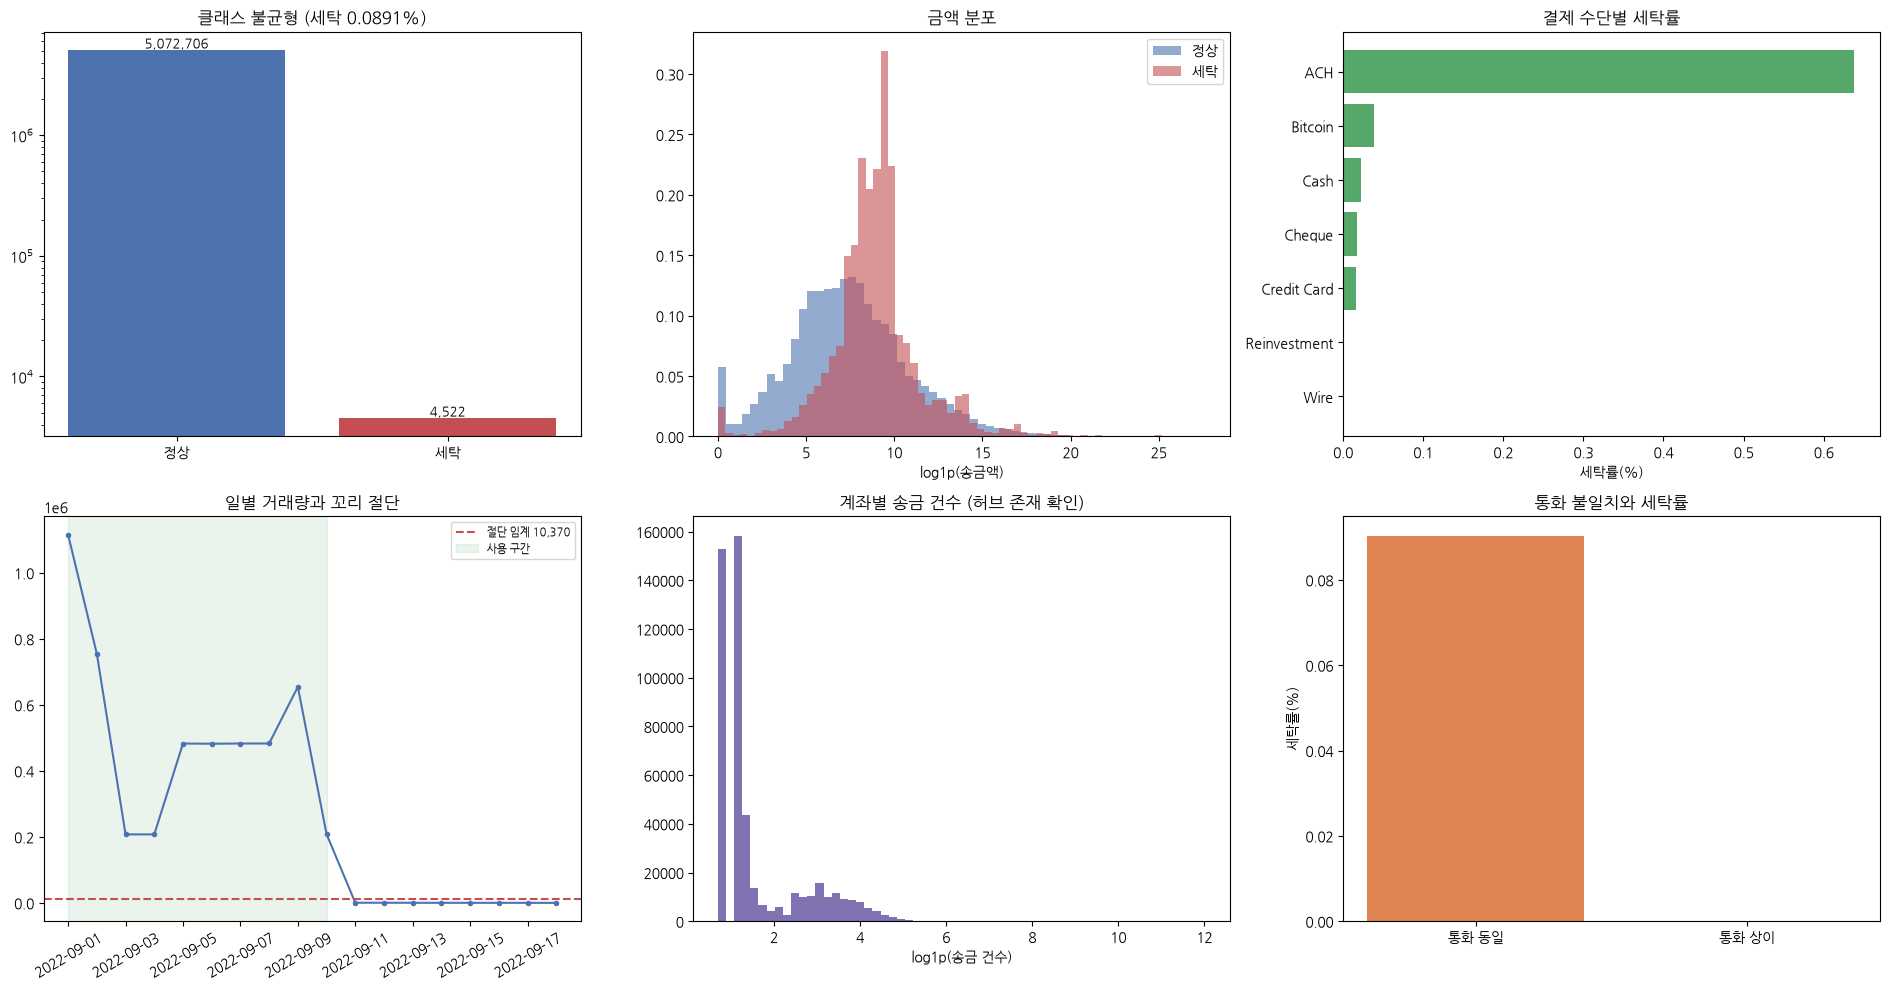

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
# (1) 클래스 불균형
vc = df["Is Laundering"].value_counts()
axes[0, 0].bar(["정상", "세탁"], vc.values, color=["#4C72B0", "#C44E52"])
axes[0, 0].set_yscale("log")
for i, v in enumerate(vc.values):
    axes[0, 0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0, 0].set_title(f"클래스 불균형 (세탁 {df['Is Laundering'].mean()*100:.4f}%)")

# (2) 금액 분포
for lab, msk, c in [("정상", df["Is Laundering"] == 0, "#4C72B0"), ("세탁", df["Is Laundering"] == 1, "#C44E52")]:
    axes[0, 1].hist(np.log1p(df.loc[msk, "Amount Paid"]), bins=60, alpha=0.6, density=True, label=lab, color=c)
axes[0, 1].set_xlabel("log1p(송금액)"); axes[0, 1].legend(); axes[0, 1].set_title("금액 분포")

# (3) 결제 수단별 세탁률
pf_rate = df.groupby("Payment Format", observed=True)["Is Laundering"].agg(["mean", "size"])
pf_rate = pf_rate[pf_rate["size"] > 100].sort_values("mean", ascending=False)
axes[0, 2].barh(pf_rate.index.astype(str)[::-1], pf_rate["mean"].values[::-1] * 100, color="#55A868")
axes[0, 2].set_xlabel("세탁률(%)"); axes[0, 2].set_title("결제 수단별 세탁률")

# (4) 일별 거래량 + 꼬리 절단 지점
axes[1, 0].plot(daily_counts_all.index, daily_counts_all.values, "o-", ms=3, color="#4C72B0")
axes[1, 0].axhline(thr, color="#C44E52", ls="--", label=f"절단 임계 {thr:,.0f}")
axes[1, 0].axvspan(main_start, main_end, alpha=0.12, color="#55A868", label="사용 구간")
axes[1, 0].legend(fontsize=8); axes[1, 0].set_title("일별 거래량과 꼬리 절단")
axes[1, 0].tick_params(axis="x", rotation=30)

# (5) 계좌 차수 분포
deg_out = df["src_id"].value_counts()
axes[1, 1].hist(np.log1p(deg_out.values), bins=60, color="#8172B2")
axes[1, 1].set_xlabel("log1p(송금 건수)"); axes[1, 1].set_title("계좌별 송금 건수 (허브 존재 확인)")

# (6) 통화 쌍 불일치와 세탁
mm = df.groupby(df["Payment Currency"].astype(str) != df["Receiving Currency"].astype(str),
                observed=True)["Is Laundering"].mean() * 100
axes[1, 2].bar(["통화 동일", "통화 상이"], mm.reindex([False, True]).fillna(0).values, color="#DD8452")
axes[1, 2].set_ylabel("세탁률(%)"); axes[1, 2].set_title("통화 불일치와 세탁률")
plt.tight_layout(); plt.show()


### 8-2. 상대 시간차 피처의 판별력 확인


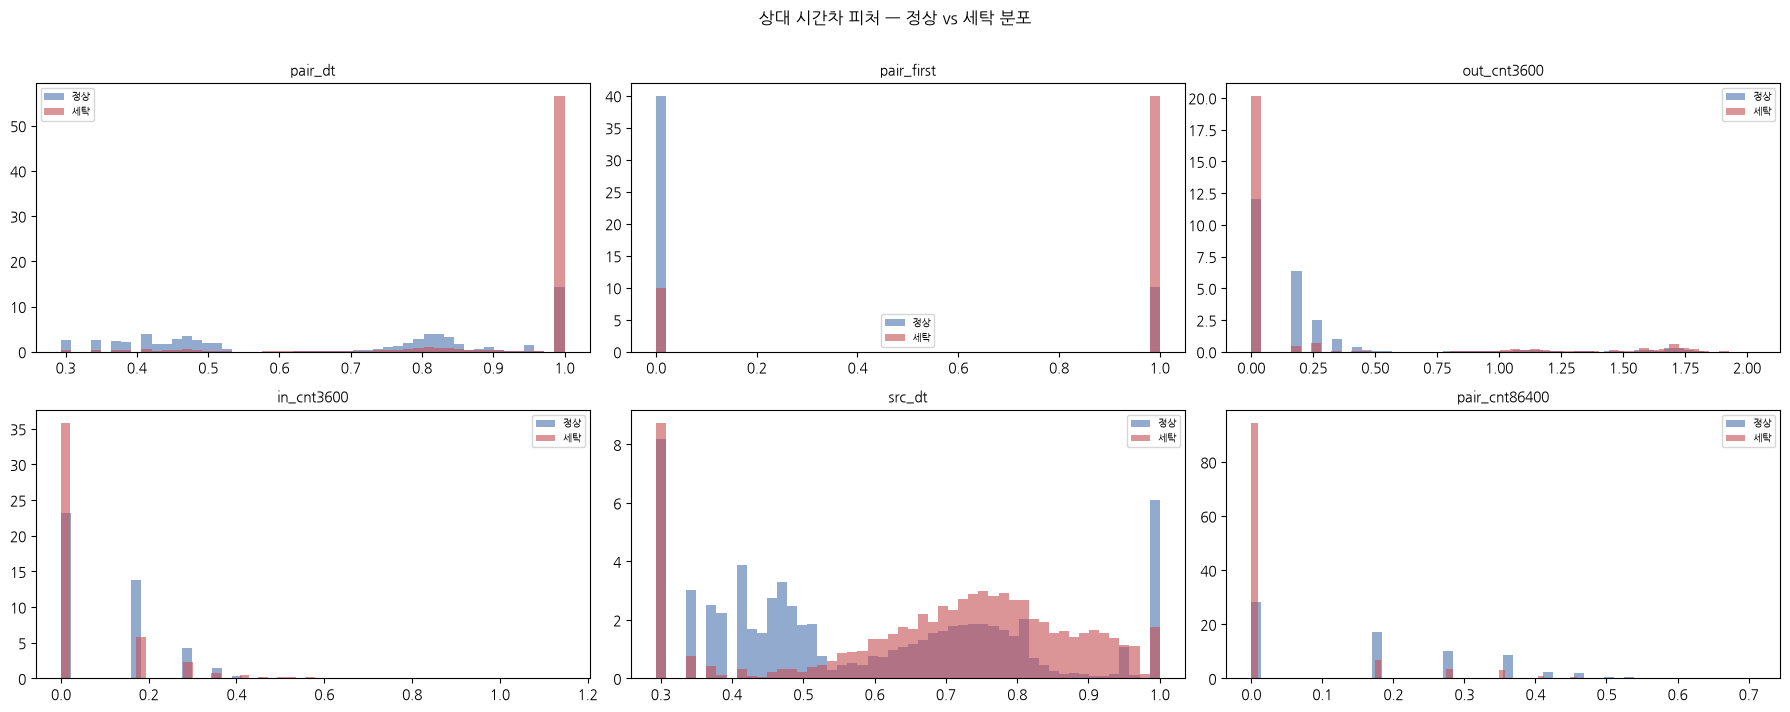

           피처  세탁 평균  정상 평균  표준화 차이
   pair_first 0.7994 0.2018  1.4874
      pair_dt 0.9364 0.6853  1.0375
pair_cnt86400 0.0347 0.1669 -0.8383
 pair_cnt3600 0.0131 0.0909 -0.6960
       src_dt 0.6921 0.5867  0.4891
       dst_dt 0.6847 0.6131  0.3507
   in_cnt3600 0.0668 0.1067 -0.3014
  dst_cnt3600 0.0761 0.1180 -0.2901
 dst_dt_first 0.0166 0.0741 -0.2196
 src_dt_first 0.0250 0.0860 -0.2177
  in_cnt86400 0.2409 0.2634 -0.1257
 dst_cnt86400 0.3218 0.3471 -0.1177
 out_cnt86400 0.4704 0.5002 -0.0513
  src_cnt3600 0.2221 0.2346 -0.0310
  out_cnt3600 0.2139 0.2240 -0.0252
 src_cnt86400 0.5668 0.5739 -0.0126


In [11]:
if USE_TIME_FEATS:
    show = [c for c in ["pair_dt", "pair_first", "out_cnt3600", "in_cnt3600", "src_dt", "pair_cnt86400"]
            if c in df.columns]
    fig, axes = plt.subplots(2, 3, figsize=(18, 7))
    for ax, c in zip(axes.ravel(), show):
        for lab, msk, col in [("정상", df["Is Laundering"] == 0, "#4C72B0"),
                              ("세탁", df["Is Laundering"] == 1, "#C44E52")]:
            ax.hist(df.loc[msk, c], bins=50, alpha=0.6, density=True, label=lab, color=col)
        ax.set_title(c, fontsize=10); ax.legend(fontsize=7)
    plt.suptitle("상대 시간차 피처 — 정상 vs 세탁 분포", y=1.01)
    plt.tight_layout(); plt.show()

    rows = []
    for c in TIME_FEATURES:
        a = df.loc[df["Is Laundering"] == 1, c].mean()
        b = df.loc[df["Is Laundering"] == 0, c].mean()
        sd = df[c].std()
        rows.append({"피처": c, "세탁 평균": a, "정상 평균": b,
                     "표준화 차이": (a - b) / (sd if sd > 0 else 1)})
    print(pd.DataFrame(rows).sort_values("표준화 차이", key=np.abs, ascending=False)
          .round(4).to_string(index=False))
else:
    print("USE_TIME_FEATS = False — 생략")


### 8-3. 실제 세탁 패턴 서브그래프 시각화 (`*_Patterns.txt`)


[파일 사용] IBM_AML_dataset/HI-Small_Patterns.txt
세탁 시나리오 블록 370개 파싱


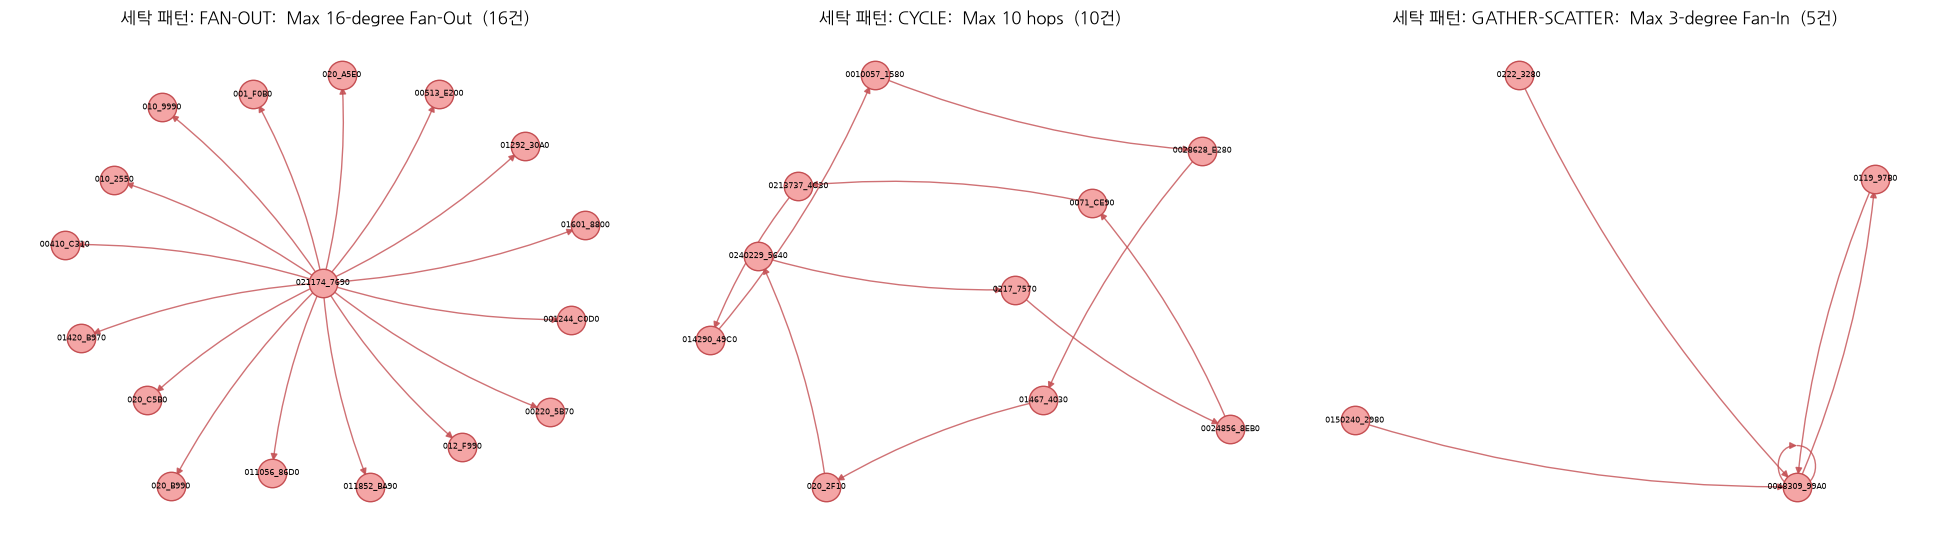

In [12]:
with open_member(f"{DATASET}_Patterns.txt") as f:
    pat_lines = f.read().decode("utf-8", errors="ignore").splitlines()

pattern_blocks, cur = [], None
for ln in pat_lines:
    if ln.startswith("BEGIN LAUNDERING ATTEMPT"):
        cur = {"name": ln.split("-", 1)[-1].strip(), "rows": []}
    elif ln.startswith("END LAUNDERING ATTEMPT"):
        if cur and cur["rows"]:
            pattern_blocks.append(cur)
        cur = None
    elif cur is not None and ln.strip():
        parts = ln.split(",")
        if len(parts) >= 11:
            cur["rows"].append(parts)
print(f"세탁 시나리오 블록 {len(pattern_blocks):,}개 파싱")

seen_types, picks = set(), []
for b in pattern_blocks:
    t = b["name"].split(":")[0].strip()
    if t not in seen_types and 3 <= len(b["rows"]) <= 40:
        seen_types.add(t); picks.append(b)
    if len(picks) == 3:
        break

if picks:
    fig, axes = plt.subplots(1, len(picks), figsize=(6.5 * len(picks), 5.5))
    axes = np.atleast_1d(axes)
    for ax, blk in zip(axes, picks):
        G = nx.MultiDiGraph()
        for r in blk["rows"]:
            G.add_edge(f"{r[1]}_{r[2][-4:]}", f"{r[3]}_{r[4][-4:]}")
        pos = nx.spring_layout(G, seed=SEED, k=1.2)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_size=420, node_color="#F4A5A5", edgecolors="#C44E52")
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#C44E52", arrows=True,
                               connectionstyle="arc3,rad=0.08", alpha=0.8)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
        ax.set_title(f"세탁 패턴: {blk['name']}  ({len(blk['rows'])}건)")
        ax.axis("off")
    plt.tight_layout(); plt.show()


### 8-4. [v9 신규] 패턴 블록 ↔ 거래 역매칭을 **선행 계산**

v8은 이 매칭을 §12-3 안에서 앙상블 점수와 함께 한 번만 수행했습니다. v9는 **모델과 무관한 매칭 결과를
먼저 만들어 두고**, 이후 모든 평가·ablation 행이 같은 인덱스로 **패턴 내/밖 재현율을 분리 보고**합니다
(요청사항 1-3 ④ — "전체 PR-AUC만 좋아지고 패턴 밖은 그대로인 경우"를 걸러내기 위함).

매칭 키는 원거래 필드(시각·은행·계좌·수단·금액) 완전 일치이며, 꼬리 절단·중복 제거로 사라진
패턴 거래는 매칭 불가로 집계해 개수를 출력합니다.


In [13]:
from collections import defaultdict, deque

KNOWN_TYPES = ["SCATTER-GATHER", "GATHER-SCATTER", "FAN-OUT", "FAN-IN",
               "BIPARTITE", "STACK", "CYCLE", "RANDOM"]

def block_type(name):
    u = name.upper()
    for k in KNOWN_TYPES:
        if k in u:
            return k
    return name.split(":")[0].strip() or "UNKNOWN"


_amt = df["Amount Paid"].map(lambda v: f"{v:.2f}")
_key = (df["Timestamp"].dt.strftime("%Y/%m/%d %H:%M") + "|" +
        df["From Bank"].astype(str) + "|" + df["Account"].astype(str) + "|" +
        df["To Bank"].astype(str) + "|" + df["Account.1"].astype(str) + "|" +
        df["Payment Format"].astype(str) + "|" + _amt)
_lut = defaultdict(deque)
for _i, _k in enumerate(_key.to_numpy()):
    _lut[_k].append(_i)

PAT_BLOCKS, PAT_UNMATCHED = [], 0
PAT_MASK = np.zeros(n, dtype=bool)
for _blk in pattern_blocks:
    _idxs = []
    for _r in _blk["rows"]:
        k = (_r[0].strip() + "|" + _r[1].strip() + "|" + _r[2].strip() + "|" +
             _r[3].strip() + "|" + _r[4].strip() + "|" + _r[9].strip() + "|" +
             f"{float(_r[7]):.2f}")
        q = _lut.get(k)
        if q:
            gi = q.popleft(); _idxs.append(gi); PAT_MASK[gi] = True
        else:
            PAT_UNMATCHED += 1
    if _idxs:
        _idxs.sort()
        PAT_BLOCKS.append(dict(type=block_type(_blk["name"]), idxs=np.array(_idxs, dtype=np.int64)))
del _lut, _key, _amt

Y_ALL = df["Is Laundering"].to_numpy().astype(np.float32)
_pos_te = np.flatnonzero(Y_ALL[n_va:] > 0) + n_va
_in_p = PAT_MASK[_pos_te]
print(f"패턴 블록 {len(pattern_blocks)}개 중 매칭 성공 {len(PAT_BLOCKS)}개 "
      f"(미매칭 거래 {PAT_UNMATCHED}건 — 꼬리 절단/중복 제거분 포함)")
print(f"test 구간 양성 {len(_pos_te):,}건 = 패턴 내 {int(_in_p.sum()):,}건 "
      f"({_in_p.mean()*100:.1f}%) / 패턴 밖 {int((~_in_p).sum()):,}건 ({(~_in_p).mean()*100:.1f}%)")

# ── 패턴 밖 양성이 실제로 "로컬 그래프 신호가 약한" 거래인지 확인 (1-3 원인 진단의 직접 근거) ──
_deg_all = (np.bincount(df["src_id"].to_numpy(), minlength=NUM_ACCOUNTS)
            + np.bincount(df["dst_id"].to_numpy(), minlength=NUM_ACCOUNTS))
_src_te, _dst_te = df["src_id"].to_numpy(), df["dst_id"].to_numpy()
_pos_deg = np.minimum(_deg_all[_src_te[_pos_te]], _deg_all[_dst_te[_pos_te]])
print(f"\n[원인 진단] 양성 거래의 양 끝 계좌 중 '작은 쪽' 총 차수 중앙값")
print(f"  패턴 내 {np.median(_pos_deg[_in_p]):.0f}건 vs 패턴 밖 {np.median(_pos_deg[~_in_p]):.0f}건")
print(f"  → 패턴 밖 양성은 이웃이 빈약해 메시지 집계에서 얻을 정보가 적습니다 "
      f"(§7-4 전역 계좌 피처·§14-4 하이브리드의 근거).")
del _deg_all, _pos_deg, _src_te, _dst_te, _pos_te, _in_p


패턴 블록 370개 중 매칭 성공 363개 (미매칭 거래 655건 — 꼬리 절단/중복 제거분 포함)
test 구간 양성 1,143건 = 패턴 내 684건 (59.8%) / 패턴 밖 459건 (40.2%)

[원인 진단] 양성 거래의 양 끝 계좌 중 '작은 쪽' 총 차수 중앙값
  패턴 내 12건 vs 패턴 밖 11건
  → 패턴 밖 양성은 이웃이 빈약해 메시지 집계에서 얻을 정보가 적습니다 (§7-4 전역 계좌 피처·§14-4 하이브리드의 근거).


## 9. 그래프 구성과 모델

### 9-1. 컨텍스트 겹침 윈도우 (v6~v8 유지) + [v9] 노드 피처 확장·캐시 시그니처

윈도우마다 앞쪽에 `CONTEXT_EDGES` 건을 그래프 컨텍스트로 붙이고, **분류·손실은 대상 구간에만** 적용합니다.

```
[ctx][==대상1==]
     [ctx      ][==대상2==]     ← 모든 대상 거래가 과거 맥락을 가짐 (학습-서빙 정합)
```

**[v9] 노드 피처 구성**

| 블록 | 개수 | 출처 | 스위치 |
|---|---|---|---|
| 창-로컬 구조 (차수·평균금액·고유 상대방·비대칭) | `NODE_FEAT_DIM` (4 또는 9) | 윈도우 내부 | §13 사다리에서만 4로 내림 |
| **전역 계좌 이력** | `GACC_DIM` = 8 | §7-4 (train 구간 전체) | `USE_GLOBAL_ACCT_FEATS` |
| **Ego-ID (윈도우 적응형)** | 2 | 대상 구간 등장 여부·대상 차수 | `USE_EGO_ID` |

**[v9] 캐시 시그니처.** v8은 설정을 바꿀 때 `MAIN["cache"].clear()` 를 **수동으로** 불러야 했고, 빠뜨리면
낡은 창이 조용히 재사용되는 위험이 있었습니다. v9는 창 구성에 영향을 주는 설정들의 시그니처를 캐시에
같이 저장해 **시그니처가 달라지면 자동으로 무효화**합니다(스윕이 창 설정을 계속 바꾸므로 필수).


In [14]:
SRC = df["src_id"].to_numpy()
DST = df["dst_id"].to_numpy()
Y   = Y_ALL
EF  = np.ascontiguousarray(df[EDGE_FEATURES].to_numpy(dtype=np.float32))
A_PAID = df["amt_paid_z"].to_numpy()
A_RECV = df["amt_recv_z"].to_numpy()

def window_ranges(lo, hi, size=None, ctx=None):
    '''(ctx_lo, lo, hi) 삼중항 목록. ctx_lo 는 구간 시작 이전 ctx 건.'''
    size = size or WINDOW_SIZE
    ctx = CONTEXT_EDGES if ctx is None else ctx
    return [(max(a - ctx, 0), a, min(a + size, hi)) for a in range(lo, hi, size)]


def node_dim_total():
    '''모델 입력 노드 차원 — 현재 전역 스위치 기준.'''
    return (NODE_FEAT_DIM
            + (GACC_DIM if USE_GLOBAL_ACCT_FEATS else 0)
            + (2 if USE_EGO_ID else 0))


def refresh_dims():
    '''창 설정이 바뀌면 파생 상수/윈도우 목록을 다시 만든다.'''
    g = globals()
    g["EDGE_EXTRA"] = 2 + (2 if USE_PORTS else 0)
    g["EDGE_DIM"]   = len(EDGE_FEATURES) + g["EDGE_EXTRA"]
    g["TRAIN_W"]    = window_ranges(0, n_tr)
    g["VAL_W"]      = window_ranges(n_tr, n_va)
    g["TEST_W"]     = window_ranges(n_va, n)


# [v7~] 본학습 데이터 번들 — §15 전이 평가는 타 세트로 같은 구조를 만든다
MAIN = dict(SRC=SRC, DST=DST, Y=Y, EF=EF, AP=A_PAID, AR=A_RECV, GACC=GACC,
            n=n, n_tr=n_tr, n_va=n_va, cache={}, cache_sig=None, ef_tag="full")

# [v8] train 구간 전역 계좌 연루 라벨 — train 라벨만 사용 (val/test 라벨 불사용 → 평가 누수 없음)
_acct_pos = np.zeros(NUM_ACCOUNTS, dtype=bool)
_tr_pos = Y[:n_tr] > 0
_acct_pos[SRC[:n_tr][_tr_pos]] = True
_acct_pos[DST[:n_tr][_tr_pos]] = True
MAIN["ACCT_POS"] = _acct_pos
print(f"train 전역 세탁 관여 계좌: {int(_acct_pos.sum()):,} / {NUM_ACCOUNTS:,} "
      f"({_acct_pos.mean()*100:.3f}%)  — AUX_LABEL_SCOPE={AUX_LABEL_SCOPE}")


def build_window(ctx_lo, lo, hi, D=None):
    '''[ctx_lo, hi) 로 방향 멀티그래프를 만들고, [lo, hi) 만 분류 대상으로 표시.'''
    D = MAIN if D is None else D
    m = hi - ctx_lo                                    # 그래프에 들어가는 원본 엣지 수
    s, d = D["SRC"][ctx_lo:hi], D["DST"][ctx_lo:hi]
    nodes, inv = np.unique(np.concatenate([s, d]), return_inverse=True)
    inv = inv.reshape(-1)
    sl, dl = inv[:m].astype(np.int64), inv[m:].astype(np.int64)
    nn_ = len(nodes)
    tgt = slice(lo - ctx_lo, hi - ctx_lo)
    sl_t, dl_t = sl[tgt], dl[tgt]

    out_deg = np.bincount(sl, minlength=nn_).astype(np.float32)
    in_deg  = np.bincount(dl, minlength=nn_).astype(np.float32)
    ap, ar  = D["AP"][ctx_lo:hi], D["AR"][ctx_lo:hi]
    mean_out = (np.bincount(sl, weights=ap, minlength=nn_) / np.maximum(out_deg, 1)).astype(np.float32)
    mean_in  = (np.bincount(dl, weights=ar, minlength=nn_) / np.maximum(in_deg, 1)).astype(np.float32)

    pair_f = sl * nn_ + dl                             # 윈도우 내 (u,v) 쌍 코드
    cols = [np.log1p(out_deg), np.log1p(in_deg), mean_out, mean_in]
    if NODE_FEAT_DIM > 4:
        uf = np.unique(pair_f)
        n_out_nb = np.bincount(uf // nn_, minlength=nn_).astype(np.float32)   # 고유 수신 상대방 수
        n_in_nb  = np.bincount(uf % nn_,  minlength=nn_).astype(np.float32)   # 고유 송신 상대방 수
        deg = out_deg + in_deg
        cols += [np.log1p(n_out_nb), np.log1p(n_in_nb),
                 ((out_deg - in_deg) / np.maximum(deg, 1)).astype(np.float32),
                 (out_deg / np.maximum(n_out_nb, 1)).astype(np.float32),
                 (in_deg / np.maximum(n_in_nb, 1)).astype(np.float32)]
        del uf
    # [v9 · 1-3 ①] 전역 계좌 이력 — 윈도우 밖 장기 신호
    if USE_GLOBAL_ACCT_FEATS and D.get("GACC") is not None:
        gsel = D["GACC"][nodes]                        # (nn_, GACC_DIM)
        cols += [np.ascontiguousarray(gsel[:, j]) for j in range(gsel.shape[1])]
        del gsel
    # [v9 · §2] Ego-ID (윈도우 적응형) — "이번 분류 대상에 등장하는 계좌인가"
    if USE_EGO_ID:
        is_tgt = np.zeros(nn_, np.float32); is_tgt[sl_t] = 1.0; is_tgt[dl_t] = 1.0
        tdeg = (np.bincount(sl_t, minlength=nn_) + np.bincount(dl_t, minlength=nn_)).astype(np.float32)
        cols += [is_tgt, (np.log1p(tdeg) / np.log(20.0)).astype(np.float32)]
    x = np.stack(cols, axis=1).astype(np.float32)

    ei = np.stack([sl, dl])
    ei_full = np.concatenate([ei, ei[::-1]], axis=1)   # 역방향 메시지 전달용
    ea = D["EF"][ctx_lo:hi]
    extra = np.zeros((2 * m, EDGE_EXTRA), dtype=np.float32)
    extra[:m, 0] = 1.0; extra[m:, 1] = 1.0             # [1,0]=정방향, [0,1]=역방향
    if USE_PORTS:
        o = np.argsort(pair_f, kind="stable")
        srt = pair_f[o]
        newg = np.r_[True, srt[1:] != srt[:-1]]
        gid = np.cumsum(newg) - 1
        start = np.flatnonzero(newg)
        rank = np.empty(m, np.int64); rank[o] = np.arange(m) - start[gid]
        mult_srt = np.bincount(gid, minlength=len(start)).astype(np.float32)[gid]
        mult = np.empty(m, np.float32); mult[o] = mult_srt
        pn = (np.log1p(rank) / np.log(20)).astype(np.float32)
        mv = (np.log1p(mult) / np.log(20)).astype(np.float32)
        extra[:m, 2] = pn; extra[m:, 2] = pn
        extra[:m, 3] = mv; extra[m:, 3] = mv
    ea_full = np.concatenate([np.concatenate([ea, ea], axis=0), extra], axis=1)

    # 병렬 엣지 그룹 (MEGA 2단계 집계용) — 양방향 전체
    pf_full = np.concatenate([pair_f, dl * nn_ + sl])
    pu, pinv = np.unique(pf_full, return_inverse=True)
    pinv = pinv.reshape(-1)
    pair_dst = (pu % nn_).astype(np.int64)

    # 계좌 보조 라벨 — 스코프 선택: train 전역(기본) 또는 창-로컬
    y_t = D["Y"][lo:hi]
    if AUX_LABEL_SCOPE == "train_global" and D.get("ACCT_POS") is not None:
        node_y = D["ACCT_POS"][nodes].astype(np.float32)
    else:
        node_y = np.zeros(nn_, np.float32)
        pos_m = y_t > 0
        if pos_m.any():
            node_y[sl_t[pos_m]] = 1.0
            node_y[dl_t[pos_m]] = 1.0
    node_mask = np.zeros(nn_, bool)
    node_mask[sl_t] = True; node_mask[dl_t] = True

    return dict(x=torch.from_numpy(x), ei=torch.from_numpy(ei_full), ea=torch.from_numpy(ea_full),
                y=torch.from_numpy(y_t), m=m,
                pinv=torch.from_numpy(pinv.astype(np.int64)),
                pair_dst=torch.from_numpy(pair_dst), n_pairs=len(pu),
                node_y=torch.from_numpy(node_y), node_mask=torch.from_numpy(node_mask),
                nodes=torch.from_numpy(nodes.astype(np.int64)), tgt=tgt)


# ── [v9] 창 캐시: 시그니처가 바뀌면 자동 무효화 ────────────────────────────
CACHE_WINDOWS = True

def window_sig(D):
    return (bool(USE_PORTS), int(NODE_FEAT_DIM), bool(USE_GLOBAL_ACCT_FEATS), bool(USE_EGO_ID),
            str(AUX_LABEL_SCOPE), int(WINDOW_SIZE), int(CONTEXT_EDGES), str(D.get("ef_tag", "?")))


def get_window(w, D=None):
    D = MAIN if D is None else D
    if not CACHE_WINDOWS:
        return build_window(*w, D=D)
    sig = window_sig(D)
    if D.get("cache_sig") != sig:                # 설정이 바뀌었다 → 낡은 창 전량 폐기
        D["cache"].clear(); D["cache_sig"] = sig
    if w not in D["cache"]:
        D["cache"][w] = build_window(*w, D=D)
    return D["cache"][w]


@contextmanager
def window_config(**kw):
    '''창 구성/모델 입력에 영향을 주는 전역 스위치를 일시 변경 (스윕·ablation 용).'''
    keys = ["USE_PORTS", "NODE_FEAT_DIM", "USE_GLOBAL_ACCT_FEATS", "USE_EGO_ID",
            "USE_MEGA", "USE_TIME_FEATS", "WINDOW_SIZE", "CONTEXT_EDGES", "AUX_LABEL_SCOPE"]
    g = globals()
    old = {k: g[k] for k in keys}
    try:
        for k, v in kw.items():
            assert k in keys, f"window_config: 알 수 없는 키 {k}"
            g[k] = v
        refresh_dims()
        yield
    finally:
        g.update(old)
        refresh_dims()


refresh_dims()
print(f"윈도우: train {len(TRAIN_W)} / val {len(VAL_W)} / test {len(TEST_W)}")
print(f"엣지 피처 {EDGE_DIM}차원 (기본 {len(BASE_FEATURES)} + 시간 {len(TIME_FEATURES)} + 구조 {EDGE_EXTRA})")
print(f"노드 피처 {node_dim_total()}차원 "
      f"(창-로컬 {NODE_FEAT_DIM} + 전역계좌 {GACC_DIM if USE_GLOBAL_ACCT_FEATS else 0} "
      f"+ ego {2 if USE_EGO_ID else 0})")
_g = build_window(*TRAIN_W[min(1, len(TRAIN_W) - 1)])
print(f"예시 윈도우: 노드 {_g['x'].shape[0]:,} / 노드피처 {_g['x'].shape[1]} / "
      f"방향엣지 {_g['ei'].shape[1]:,} / 병렬쌍 {_g['n_pairs']:,} / "
      f"분류 대상 {_g['tgt'].stop - _g['tgt'].start:,} / 대상 관여 계좌 {int(_g['node_mask'].sum()):,}")
assert _g["x"].shape[1] == node_dim_total(), "노드 피처 차원 불일치"
del _g


train 전역 세탁 관여 계좌: 3,170 / 515,078 (0.615%)  — AUX_LABEL_SCOPE=train_global
윈도우: train 31 / val 11 / test 11
엣지 피처 68차원 (기본 48 + 시간 16 + 구조 4)
노드 피처 17차원 (창-로컬 9 + 전역계좌 8 + ego 0)
예시 윈도우: 노드 185,098 / 노드피처 17 / 방향엣지 400,000 / 병렬쌍 213,466 / 분류 대상 100,000 / 대상 관여 계좌 105,513


### 9-2. MEGA-GNN식 다중엣지 집계 + [v9] PNA 다중 집계자 / 역방향 강도 / 계좌 상태 / AMP 안전장치

**MEGA 2단계 집계 (v6~ 유지).** 같은 (u→v) 병렬 엣지를 먼저 합쳐 "이 상대와의 관계" 벡터를 만들고(①),
그 관계 벡터들을 노드로 모읍니다(②).

$$h_v' = \mathrm{MLP}\Big((1+\epsilon)\,h_v + \psi\big[\;\underset{u \in \mathcal N(v)}{\square}\;\underbrace{\textstyle\sum_{e \in E_{uv}} \phi(h_u, e)}_{\text{① 병렬 엣지}}\;\big]\Big)$$

**[v9 · §2] PNA 스타일 다중 집계자.** 위 식의 $\square$ 를 단일 `sum` 대신
**`sum · mean · max · std` 를 concat 한 뒤 선형 사영 $\psi$** 로 되돌립니다 (`PNA_AGGRS`).
sum 하나는 "차수"에, mean 은 "평균 성향"에, max 는 "가장 튀는 이웃"에, std 는 "이웃 다양성"에 각각 민감해
표현력이 올라간다고 알려진 기법입니다. **degree scaler(증폭/감쇠)는 미구현** — §20에 명시합니다.

**[v9 · §2] 역방향 강도 `REV_EDGE_W`.** 역방향 메시지 전달은 그대로 유지하되, 역방향 절반의
메시지와 엣지 업데이트에 곱해지는 계수를 스윕 축으로 둡니다. `0.0` 이면 역방향 제거 ablation과 같습니다.

**[v9 · §2] Persistent account state.** 창마다 초기화되던 계좌 표현 대신, 계좌별 상태 벡터
`acct_state[NUM_ACCOUNTS, PERSIST_DIM]` 를 학습 구간 전체에 걸쳐 EMA 로 유지해 입력에 더합니다.

| 항목 | 비용/제약 |
|---|---|
| 메모리 | `NUM_ACCOUNTS × PERSIST_DIM × 4B` (예: 515,078 × 32 × 4B ≈ **66 MB**, GPU 상주) |
| 갱신 시점 | **`model.train()` 일 때만** 갱신, 평가에서는 읽기 전용 → 미래(val/test) 정보가 학습으로 역류하지 않음 |
| 초기화 | 에폭 시작마다 0 으로 리셋 (창 순서 무작위 → 상태가 무한히 표류하지 않도록) |
| 저장 | `persistent=False` 버퍼 — 체크포인트에 넣지 않습니다. 서빙 시 워밍업 필요 |
| 남는 제약 | 창 순서가 무작위라 "스트리밍 상태"의 시간 의미가 완전하지는 않습니다 (§20에 명시) |

**[v9 · 1-1] AMP 안전장치.** 집계(`index_add`/`index_reduce`)는 **항상 fp32** 로 수행하고,
저정밀로 되돌리기 **직전에만** 자릅니다. bf16 은 지수 범위가 fp32와 같아 clamp 가 사실상 무동작이고,
fp16 일 때만 상한의 `AGG_CLAMP_FRAC` 지점에서 잘립니다. 레이어별 `max|agg|` 는 **동기화 없는 GPU 텐서로
누적**해 에폭당 1회만 읽어오므로 학습 속도에 영향이 없습니다.

> ⚠️ **함정 하나 (v9에서 실제로 잡은 버그).** clamp 발동 여부를 `msg.dtype` 으로 판단하면 안 됩니다.
> `nn.LayerNorm` 은 CUDA autocast 의 **fp32 목록**이라 2번째 conv 부터 `h` 가 fp32 이고,
> `msg = relu(h[u] + e)` 도 fp32 로 승격됩니다. 그러면 `msg.dtype != float32` 조건이 거짓이 되어
> **clamp 가 1번 레이어에서만 작동**하는데, 정작 저정밀 캐스팅은 사라진 게 아니라 바로 뒤
> `self.proj`/`self.mlp` 의 autocast `Linear` 안으로 옮겨간 것이라 **오버플로가 가장 큰 뒤쪽 레이어가
> 무방비**가 됩니다. 그래서 v9는 `autocast_lowp()` 로 **주변 autocast dtype** 을 직접 조회해 판단합니다.


In [15]:
AGG_CHOICES = ("sum", "mean", "max", "std")


def autocast_lowp(device_type):
    '''지금 autocast 가 실제로 캐스팅할 저정밀 dtype (autocast 꺼져 있으면 fp32).

    [v9 1-1 중요] clamp 를 `msg.dtype` 으로 판단하면 안 됩니다.
    `nn.LayerNorm` 은 CUDA autocast 의 fp32 목록이라 2번째 conv 부터 h 가 fp32 이고
    msg = relu(h[ei[0]] + e) 도 fp32 로 승격됩니다. 그렇다고 저정밀 캐스팅이 사라지는 것이
    아니라 바로 뒤 self.proj / self.mlp 의 autocast Linear 안으로 옮겨갈 뿐이므로,
    msg.dtype 기준으로 자르면 **1번 레이어만 보호되고 오버플로가 가장 큰 뒤쪽 레이어가 무방비**가 됩니다.
    '''
    try:
        if torch.is_autocast_enabled(device_type):
            return torch.get_autocast_dtype(device_type)
    except TypeError:                                    # torch < 2.4 폴백
        if device_type == "cuda" and torch.is_autocast_enabled():
            return torch.get_autocast_gpu_dtype()
    return torch.float32


class MegaConv(nn.Module):
    '''GINe + (옵션) 병렬 엣지 2단계 집계 + [v9] PNA 다중 집계자 + AMP 안전장치.

    집계(index_add_/index_reduce)는 항상 fp32로 수행 — V100에서 fp16 atomicAdd 가 2배 이상 느리고,
    fp32 로 모아야 저정밀 오버플로를 캐스팅 직전 한 지점에서만 통제할 수 있습니다.
    '''
    def __init__(self, hidden, mega=True, msg_dropout=0.0, aggrs=("sum",),
                 agg_clamp=True, clamp_frac=0.25):
        super().__init__()
        self.mega = mega
        self.msg_dropout = float(msg_dropout)
        self.aggrs = tuple(aggrs)
        assert all(a in AGG_CHOICES for a in self.aggrs), f"알 수 없는 집계자: {self.aggrs}"
        self.agg_clamp = bool(agg_clamp)
        self.clamp_frac = float(clamp_frac)
        self.eps = nn.Parameter(torch.zeros(1))
        # 다중 집계자면 concat 후 hidden 으로 되돌리는 선형 사영
        self.proj = nn.Linear(len(self.aggrs) * hidden, hidden) if len(self.aggrs) > 1 else None
        self.mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        # [v9 1-1 ③] 진단용 — 동기화 없이 GPU에 누적, 에폭당 1회만 읽는다
        self.register_buffer("agg_absmax_t", torch.zeros(()), persistent=False)

    @property
    def agg_absmax(self):
        return float(self.agg_absmax_t.detach().cpu())

    def reset_diag(self):
        with torch.no_grad():
            self.agg_absmax_t.zero_()

    def _multi_agg(self, src32, index, n_out):
        '''index 기준 다중 집계 — 전부 fp32. 반환: 집계자 순서대로의 리스트.'''
        H = src32.size(1)
        need_sum = any(a in ("sum", "mean", "std") for a in self.aggrs)
        ssum = cnt = None
        if need_sum:
            ssum = torch.zeros(n_out, H, device=src32.device, dtype=torch.float32)
            ssum = ssum.index_add(0, index, src32)
        if any(a in ("mean", "std") for a in self.aggrs):
            cnt = torch.zeros(n_out, device=src32.device, dtype=torch.float32)
            cnt = cnt.index_add(0, index, torch.ones(index.numel(), device=src32.device,
                                                     dtype=torch.float32))
            cnt = cnt.clamp(min=1.0).unsqueeze(1)
        outs = []
        for a in self.aggrs:
            if a == "sum":
                outs.append(ssum)
            elif a == "mean":
                outs.append(ssum / cnt)
            elif a == "max":
                base = torch.zeros(n_out, H, device=src32.device, dtype=torch.float32)
                outs.append(base.index_reduce(0, index, src32, "amax", include_self=False))
            elif a == "std":
                s2 = torch.zeros(n_out, H, device=src32.device, dtype=torch.float32)
                s2 = s2.index_add(0, index, src32 * src32)
                mu = ssum / cnt
                outs.append(torch.sqrt(torch.clamp(s2 / cnt - mu * mu, min=0.0) + 1e-6))
        return outs

    def forward(self, h, ei, e, pinv, pair_dst, n_pairs, m=None, rev_w=1.0):
        msg = F.relu(h[ei[0]] + e)
        if rev_w != 1.0 and m is not None:                    # [v9] 역방향 기여 강도
            msg = torch.cat([msg[:m], msg[m:] * rev_w], dim=0)
        if self.msg_dropout > 0:
            msg = F.dropout(msg, self.msg_dropout, self.training)   # DropMessage
        m32 = msg.float()
        if self.mega:
            pair = torch.zeros(n_pairs, m32.size(1), device=m32.device, dtype=torch.float32)
            pair = pair.index_add(0, pinv, m32)               # ① 같은 계좌쌍의 병렬 엣지끼리
            aggs = self._multi_agg(pair, pair_dst, h.size(0))  # ② 이웃(계좌쌍) 단위로
        else:
            aggs = self._multi_agg(m32, ei[1], h.size(0))      # 기존 GINe: 한 번에 전부
        agg = torch.cat(aggs, dim=1) if len(aggs) > 1 else aggs[0]

        # [v9 1-1 ③] 진단 계측 (동기화 없음)
        if agg.numel():
            with torch.no_grad():
                self.agg_absmax_t.copy_(torch.maximum(self.agg_absmax_t,
                                                      agg.detach().abs().amax()))
        # [v9 1-1 ②] 저정밀 캐스팅 직전 안전장치 — fp16 일 때만 실제로 자릅니다.
        #   bf16 은 상한이 3.4e38 이라 clamp 가 사실상 무동작(성능 영향 없음)이고,
        #   fp32(autocast off)는 캐스팅 자체가 없으므로 건너뜁니다.
        #   판단 기준은 msg.dtype 이 아니라 **주변 autocast dtype** 입니다 (autocast_lowp 주석 참조).
        lowp = autocast_lowp(agg.device.type)
        if self.agg_clamp and lowp != torch.float32:
            lim = torch.finfo(lowp).max * self.clamp_frac
            agg = agg.clamp(-lim, lim)
        agg = agg.to(msg.dtype)
        if self.proj is not None:
            agg = self.proj(agg)
        return self.mlp((1 + self.eps) * h + agg)


class EdgeGINe(nn.Module):
    '''MEGA/PNA 집계 + 엣지 업데이트 + 역방향 메시지 전달 + 계좌 보조 헤드 + [v9] 계좌 상태.'''
    def __init__(self, node_dim, edge_dim, hidden=128, layers=3, dropout=0.15, mega=True,
                 msg_dropout=0.0, aggrs=("sum",), rev_w=1.0,
                 persist_dim=0, persist_alpha=0.3, n_accounts=0,
                 agg_clamp=True, clamp_frac=0.25):
        super().__init__()
        self.node_in = nn.Linear(node_dim, hidden)
        self.edge_in = nn.Linear(edge_dim, hidden)
        self.convs = nn.ModuleList([MegaConv(hidden, mega, msg_dropout, aggrs, agg_clamp, clamp_frac)
                                    for _ in range(layers)])
        self.eupds = nn.ModuleList([nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                                  nn.Linear(hidden, hidden)) for _ in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(layers)])
        self.dropout = dropout
        self.rev_w = float(rev_w)
        self.head = nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.node_head = nn.Sequential(nn.Linear(hidden, hidden // 2), nn.ReLU(),
                                       nn.Linear(hidden // 2, 1))          # 계좌 보조
        # [v9 §2] persistent account state
        self.persist_dim = int(persist_dim)
        self.persist_alpha = float(persist_alpha)
        if self.persist_dim > 0:
            self.persist_in = nn.Linear(self.persist_dim, hidden)
            self.persist_out = nn.Linear(hidden, self.persist_dim)
            for p in self.persist_out.parameters():   # 상태 인코더는 고정 랜덤 사영
                p.requires_grad_(False)               # (detach 로 학습 신호가 끊기므로 명시적으로 고정)
            self.register_buffer("acct_state", torch.zeros(n_accounts, self.persist_dim),
                                 persistent=False)

    def reset_state(self):
        if self.persist_dim > 0:
            with torch.no_grad():
                self.acct_state.zero_()

    def reset_diag(self):
        for c in self.convs:
            c.reset_diag()

    def agg_headroom(self, dtype):
        '''레이어별 max|agg| 를 dtype 상한 대비 비율로. (최대 여유율, 레이어별 값)'''
        vals = [c.agg_absmax for c in self.convs]
        lim = torch.finfo(dtype).max
        return (max(vals) / lim if vals else 0.0), vals

    def forward(self, g):
        ei, m = g["ei"], g["m"]
        h = self.node_in(g["x"])
        use_state = self.persist_dim > 0 and ("nodes" in g) and self.acct_state.numel() > 0
        if use_state:
            h = h + self.persist_in(self.acct_state[g["nodes"]].to(h.dtype))
        e = self.edge_in(g["ea"])
        for conv, eupd, norm in zip(self.convs, self.eupds, self.norms):
            h = F.relu(norm(conv(h, ei, e, g["pinv"], g["pair_dst"], g["n_pairs"], m, self.rev_w)))
            h = F.dropout(h, self.dropout, self.training)
            upd = eupd(torch.cat([h[ei[0]], h[ei[1]], e], dim=1))       # 엣지 업데이트
            if self.rev_w != 1.0:
                upd = torch.cat([upd[:m], upd[m:] * self.rev_w], dim=0)
            e = e + upd
        # [v9] 계좌 상태 갱신 — 학습 중에만 (평가는 읽기 전용 → 미래 정보 역류 차단)
        if use_state and self.training:
            with torch.no_grad(), torch.autocast(device_type=h.device.type, enabled=False):
                new = torch.tanh(self.persist_out(h.detach().float()))
                idx = g["nodes"]
                self.acct_state[idx] = ((1.0 - self.persist_alpha) * self.acct_state[idx]
                                        + self.persist_alpha * new)
        tgt = g["tgt"]
        fi = ei[:, :m][:, tgt]                       # 정방향 엣지 중 "대상 구간"만 분류
        z = torch.cat([h[fi[0]], h[fi[1]], e[:m][tgt]], dim=1)
        return self.head(z).squeeze(-1), self.node_head(h).squeeze(-1)


def make_model(cfg=None, n_accounts=None):
    '''현재 전역 설정(또는 cfg)으로 모델 생성 — 스윕/ablation 전부 이 함수를 통과합니다.'''
    c = cfg or {}
    aggrs = c.get("AGGRS", tuple(PNA_AGGRS))
    if isinstance(aggrs, str):
        aggrs = ("sum", "mean", "max", "std") if aggrs == "pna4" else ("sum",)
    return EdgeGINe(
        node_dim=node_dim_total(), edge_dim=EDGE_DIM,
        hidden=int(c.get("HIDDEN", HIDDEN)), layers=int(c.get("N_LAYERS", N_LAYERS)),
        dropout=DROPOUT, mega=USE_MEGA,
        msg_dropout=float(c.get("MSG_DROPOUT", MSG_DROPOUT)),
        aggrs=tuple(aggrs), rev_w=float(c.get("REV_W", REV_EDGE_W)),
        persist_dim=int(c.get("PERSIST", PERSIST_DIM)), persist_alpha=PERSIST_ALPHA,
        n_accounts=(NUM_ACCOUNTS if n_accounts is None else n_accounts),
        agg_clamp=bool(c.get("AGG_CLAMP", AGG_CLAMP)), clamp_frac=AGG_CLAMP_FRAC)


_m = make_model()
_np_tot = sum(p.numel() for p in _m.parameters())
print(f"파라미터 수(현재 기본 구성 h{HIDDEN}/L{N_LAYERS}/aggr{len(_m.convs[0].aggrs)}): {_np_tot:,} "
      f"(계좌 보조 헤드 {sum(p.numel() for p in _m.node_head.parameters()):,} 포함)")
_m4 = EdgeGINe(node_dim_total(), EDGE_DIM, HIDDEN, N_LAYERS, DROPOUT, USE_MEGA,
               MSG_DROPOUT, ("sum", "mean", "max", "std"), 1.0, 0, PERSIST_ALPHA, NUM_ACCOUNTS)
print(f"  PNA 4집계자 적용 시: {sum(p.numel() for p in _m4.parameters()):,} "
      f"(+{sum(p.numel() for p in _m4.parameters()) - _np_tot:,})")
print(f"  persistent state 32차원 사용 시 버퍼: "
      f"{NUM_ACCOUNTS * 32 * 4 / 1e6:.1f} MB (GPU 상주, 체크포인트 미포함)")
del _m, _m4, _np_tot


파라미터 수(현재 기본 구성 h256/L2/aggr1): 1,041,924 (계좌 보조 헤드 33,025 포함)
  PNA 4집계자 적용 시: 1,566,724 (+524,800)
  persistent state 32차원 사용 시 버퍼: 65.9 MB (GPU 상주, 체크포인트 미포함)


## 10. 학습 — 시드별 재현 가능한 학습 함수

* **손실**: `BCEWithLogitsLoss(pos_weight)` (상한 `POS_WEIGHT_CAP` — §10-2 스윕으로 결정)
  또는 **[v9] focal loss** `-(1-p)^γ log p` (γ 는 §10-3 스윕이 결정, γ=0 이면 BCE와 동일)
* **계좌 보조 손실**: `loss = 엣지 손실 + AUX_NODE_W × 노드 BCE`
* **모델 선택**: 검증 PR-AUC 조기종료 (일반화 우선)
* **[v9 · 1-1] 혼합정밀 안전 운전**:
  1. `AMP_DTYPE` 는 bf16 우선 자동 선택
  2. 집계는 fp32 → 저정밀 캐스팅 직전에만 clamp(fp16 폴백일 때만 실제 동작)
  3. **에폭마다 `max|agg|` 여유율을 로그에 남기고** `AMP_HEADROOM_WARN` 초과 시 경고
  4. 비유한 손실/그래디언트 스텝은 **backward 전에 건너뛰고** 누적 개수를 보고
  5. 추론 확률에 비유한값이 있으면 **그 자리에서** 원인(마지막 `max|agg|`·dtype 상한)과 함께 예외


In [16]:
def to_dev(g):
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v) for k, v in g.items()}


# ── [v9 · 1-3 ②] focal loss / hard-example 가중 ────────────────────────────
def focal_bce_with_logits(logits, targets, pos_weight, gamma):
    '''pos_weight 를 유지한 focal BCE. gamma=0 이면 BCEWithLogitsLoss(pos_weight) 와 동일.

    쉬운 샘플(이미 잘 맞히는 것)의 손실 기여를 (1-p)^γ / p^γ 로 줄여,
    **그래프 신호가 약해 잘 못 맞히는 양성(패턴 밖 세탁)** 의 상대 비중을 키웁니다.
    '''
    p = torch.sigmoid(logits)
    logp, log1mp = F.logsigmoid(logits), F.logsigmoid(-logits)
    loss_pos = -torch.pow(torch.clamp(1.0 - p, min=0.0), gamma) * logp
    loss_neg = -torch.pow(torch.clamp(p, min=0.0), gamma) * log1mp
    return (pos_weight * targets * loss_pos + (1.0 - targets) * loss_neg).mean()


def parse_loss(tag):
    '''"bce" | "focal1.0" | "focal2.0" → (종류, gamma)'''
    t = str(tag)
    if t.startswith("focal"):
        return "focal", float(t[5:] or 1.0)
    return "bce", 0.0


def cfg_from_globals():
    '''현재 전역 설정을 스윕 cfg 형태로.'''
    return dict(HIDDEN=int(HIDDEN), N_LAYERS=int(N_LAYERS),
                AUX_NODE_W=float(AUX_NODE_W if USE_NODE_AUX else 0.0),
                MSG_DROPOUT=float(MSG_DROPOUT), POS_CAP=float(POS_WEIGHT_CAP),
                GLOBAL_ACCT=bool(USE_GLOBAL_ACCT_FEATS), EGO=bool(USE_EGO_ID),
                LOSS=("focal%g" % FOCAL_GAMMA if LOSS_TYPE == "focal" else "bce"),
                AGGRS=("pna4" if len(tuple(PNA_AGGRS)) > 1 else "sum"),
                REV_W=float(REV_EDGE_W), PERSIST=int(PERSIST_DIM))


def cfg_label(c):
    return (f"h{c['HIDDEN']}/L{c['N_LAYERS']}/aux{c['AUX_NODE_W']:g}/md{c['MSG_DROPOUT']:g}"
            f"/glob{int(c['GLOBAL_ACCT'])}/{c['LOSS']}/{c['AGGRS']}"
            f"/ego{int(c['EGO'])}/rev{c['REV_W']:g}/pst{c['PERSIST']}")


def cfg_key(c):
    return tuple(sorted((k, (round(v, 4) if isinstance(v, float) else v)) for k, v in c.items()))


def train_one_seed(seed, cfg=None, epochs=None, patience=None, verbose=True,
                   amp_dtype=None, agg_clamp=None):
    '''시드 하나를 학습. cfg 로 모든 구조/손실 축을 오버라이드할 수 있습니다(스윕·ablation 공용).'''
    c = cfg_from_globals()
    if cfg:
        c.update(cfg)
    epochs = EPOCHS if epochs is None else int(epochs)
    patience = PATIENCE if patience is None else int(patience)
    cap = float(c["POS_CAP"]); aw = float(c["AUX_NODE_W"])
    loss_kind, gamma = parse_loss(c["LOSS"])
    dt_req = AMP_DTYPE if amp_dtype is None else amp_dtype
    clamp_on = AGG_CLAMP if agg_clamp is None else bool(agg_clamp)

    with window_config(USE_GLOBAL_ACCT_FEATS=bool(c["GLOBAL_ACCT"]), USE_EGO_ID=bool(c["EGO"])):
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        if DEVICE.type == "cuda":
            torch.cuda.manual_seed_all(seed)

        model = make_model({**c, "AGG_CLAMP": clamp_on}).to(DEVICE)
        pos = float(Y[:n_tr].sum())
        pw = torch.tensor(min((n_tr - pos) / max(pos, 1.0), cap), device=DEVICE)
        bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                      lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5,
                                                              patience=3, min_lr=1e-5)
        amp_on = USE_AMP and DEVICE.type == "cuda"
        amp_dt = dt_req if amp_on else torch.float32
        use_scaler = amp_on and amp_dt == torch.float16      # bf16 은 GradScaler 불필요
        scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
        skipped = 0

        def edge_loss(logits, target):
            if loss_kind == "focal":
                return focal_bce_with_logits(logits, target, pw, gamma)
            return bce(logits, target)

        @torch.no_grad()
        def predict(windows):
            model.eval(); ps = []
            for w in windows:
                g = to_dev(get_window(w))
                with torch.autocast("cuda", amp_dt, enabled=amp_on):
                    logit, _ = model(g)
                p = torch.sigmoid(logit.float())
                if not bool(torch.isfinite(p).all()):        # 여기서 잡아야 원인이 보입니다
                    head, vals = model.agg_headroom(amp_dt)
                    raise FloatingPointError(
                        f"추론 확률에 비유한값 {int((~torch.isfinite(p)).sum()):,}개 (윈도우 {w}).\n"
                        f"  레이어별 max|agg| = {['%.3g' % v for v in vals]} / "
                        f"{str(amp_dt).split('.')[-1]} 상한 {torch.finfo(amp_dt).max:,.0f} "
                        f"(여유율 {head*100:.1f}%)\n"
                        f"  → 저정밀 오버플로입니다. §10-1 진단 셀을 실행하고 "
                        f"AMP_DTYPE=torch.bfloat16 또는 AGG_CLAMP=True 로 두십시오.")
                ps.append(p.cpu().numpy())
                del g, logit, p
            return np.concatenate(ps)

        hist = {"train_loss": [], "val_ap": [], "headroom": []}
        best_ap, best_state, best_acct, left = -1.0, None, None, patience
        vy = Y[n_tr:n_va]
        warn_shown = False
        for epoch in range(1, epochs + 1):
            model.train(); model.reset_diag(); model.reset_state()
            ep_loss, n_step, t0 = 0.0, 0, time.time()
            for wi in np.random.permutation(len(TRAIN_W)):
                g = to_dev(get_window(TRAIN_W[wi]))
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast("cuda", amp_dt, enabled=amp_on):
                    el, nl = model(g)
                    loss = edge_loss(el.float(), g["y"])
                    if aw > 0:
                        nm = g["node_mask"]
                        if bool(nm.any()):               # 빈 마스크 BCE = NaN 가드
                            ny = g["node_y"][nm]
                            npos = ny.sum()
                            pwn = torch.clamp((nm.sum().float() - npos) / torch.clamp(npos, min=1.0),
                                              max=cap)
                            aux = F.binary_cross_entropy_with_logits(nl[nm].float(), ny, pos_weight=pwn)
                            if bool(torch.isfinite(aux)):
                                loss = loss + aw * aux
                if not bool(torch.isfinite(loss)):        # 비유한 손실은 backward 전에 폐기
                    skipped += 1; del g; continue
                scaler.scale(loss).backward()
                if use_scaler:
                    scaler.unscale_(optimizer)
                gnorm = nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad],
                                                 GRAD_CLIP)
                if bool(torch.isfinite(gnorm)):
                    scaler.step(optimizer)
                else:
                    skipped += 1
                scaler.update()
                ep_loss += float(loss.detach()); n_step += 1; del g
            ep_loss /= max(n_step, 1)

            head, _vals = model.agg_headroom(amp_dt)      # [v9 1-1 ③] 에폭당 1회만 동기화
            val_ap = average_precision_score(vy, predict(VAL_W))
            scheduler.step(val_ap)
            hist["train_loss"].append(ep_loss); hist["val_ap"].append(float(val_ap))
            hist["headroom"].append(float(head))
            mark = ""
            if val_ap > best_ap:
                best_ap, left = val_ap, patience
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                # [v9] acct_state 는 persistent=False 버퍼라 state_dict 에 없습니다.
                #   따로 스냅샷하지 않으면 "best 에폭 가중치 + 마지막 에폭 계좌상태" 라는
                #   존재하지 않는 모델로 val_prob/test_prob 이 계산됩니다(선택 기준과 보고 수치 불일치).
                best_acct = (model.acct_state.detach().cpu().clone()
                             if model.persist_dim > 0 else None)
                mark = "  <- best"
            else:
                left -= 1
            warn = ""
            if head > AMP_HEADROOM_WARN:
                warn = f"  ⚠️ max|agg| 여유율 {head*100:.1f}% (>{AMP_HEADROOM_WARN*100:.0f}%)"
                if not warn_shown and verbose:
                    print(f"    ⚠️ 집계가 {str(amp_dt).split('.')[-1]} 상한의 "
                          f"{head*100:.1f}% 를 사용 중입니다 — bf16 전환 또는 AGG_CLAMP 유지 필요",
                          flush=True)
                    warn_shown = True
            if verbose:
                print(f"  seed{seed} ep {epoch:>2}/{epochs}  loss={ep_loss:.4f}  "
                      f"val PR-AUC={val_ap:.4f}  lr={optimizer.param_groups[0]['lr']:.1e}  "
                      f"agg여유율={head*100:.2f}%  ({time.time()-t0:.0f}s){mark}{warn}", flush=True)
            if left == 0:
                if verbose:
                    print("  조기종료 (검증 PR-AUC 개선 없음)")
                break

        if skipped and verbose:
            print(f"    ⚠️ 비유한 손실/그래디언트로 건너뛴 스텝 누적 {skipped}개 — 오버플로 신호")
        if best_state is None:
            raise RuntimeError("best_state 가 없습니다 — 모든 에폭에서 학습 실패. §10-1 진단을 먼저 실행하십시오.")
        model.load_state_dict(best_state)
        if best_acct is not None:                     # [v9] 계좌 상태도 best 에폭 것으로 복원
            with torch.no_grad():
                model.acct_state.copy_(best_acct.to(model.acct_state.device))
        out = dict(seed=seed, model=model, state=best_state, acct_state=best_acct,
                   val_ap=float(best_ap), history=hist,
                   skipped_steps=skipped, cfg=dict(c), amp_dtype=str(amp_dt).split(".")[-1],
                   agg_clamp=clamp_on, max_headroom=float(max(hist["headroom"] or [0.0])),
                   n_params=int(sum(p.numel() for p in model.parameters())),
                   val_prob=predict(VAL_W), test_prob=predict(TEST_W))
    return out


# ── 평가 헬퍼 (스윕·ablation·§12 이후 공용) ──────────────────────────────
val_y, test_y = Y[n_tr:n_va], Y[n_va:]

def tuned_threshold(vy, vp):
    p_c, r_c, t_c = precision_recall_curve(vy, vp)
    f1_c = 2 * p_c * r_c / np.maximum(p_c + r_c, 1e-12)
    return float(t_c[int(np.nanargmax(f1_c[:-1]))])

def metrics(y_true, y_prob, thr):
    yp = (y_prob >= thr).astype(int)
    return dict(P=precision_score(y_true, yp, zero_division=0) * 100,
                R=recall_score(y_true, yp, zero_division=0) * 100,
                F1=f1_score(y_true, yp, zero_division=0) * 100)

def evaluate(vp, tp, name, vy=None, ty=None):
    '''vy/ty 를 넘기면 타 세트(전이 평가)에도 같은 프로토콜을 적용할 수 있다.'''
    vy = val_y if vy is None else vy
    ty = test_y if ty is None else ty
    thr_f1 = tuned_threshold(vy, vp)
    thr_bud = float(np.quantile(tp, 1 - ALERT_BUDGET))
    row = {"모델": name, "val PR-AUC": average_precision_score(vy, vp),
           "test PR-AUC": average_precision_score(ty, tp)}
    for tag, th in [("@0.5", 0.5), ("@F1튜닝", thr_f1), ("@예산0.1%", thr_bud)]:
        m = metrics(ty, tp, th)
        row |= {f"P{tag}": m["P"], f"R{tag}": m["R"], f"F1{tag}": m["F1"]}
    row["thr_F1"], row["thr_예산"] = thr_f1, thr_bud
    return row


# ── [v9 · 1-3 ④] 시나리오/패턴 분리 지표 — 모든 ablation 행이 이 함수를 통과합니다 ──
def scenario_metrics(tp, budget=None, thr=None, with_type=False):
    '''test 확률 벡터 → 시나리오 재현율 · 탐지 지연 · **패턴 내/밖 거래 재현율**.

    §12-3 의 전체 리포트와 스윕/ablation 표가 같은 정의를 공유하도록 함수로 분리했습니다.
    '''
    if not PAT_BLOCKS:
        return None
    budget = ALERT_BUDGET if budget is None else budget
    thr = float(np.quantile(tp, 1 - budget)) if thr is None else float(thr)
    hit = tp >= thr

    cov = det = 0
    ranks, fracs, per_type = [], [], {}
    for b in PAT_BLOCKS:
        idxs = b["idxs"]
        if not (idxs >= n_va).any():
            continue
        cov += 1
        pos_rank = None
        for rk, gi in enumerate(idxs, start=1):
            if gi >= n_va and hit[gi - n_va]:
                pos_rank = rk; break
        t_ = per_type.setdefault(b["type"], [0, 0])
        t_[0] += 1
        if pos_rank is not None:
            det += 1; t_[1] += 1
            ranks.append(pos_rank); fracs.append(pos_rank / len(idxs))

    pos_te = np.flatnonzero(Y[n_va:] > 0) + n_va
    in_p = PAT_MASK[pos_te]
    h_pos = hit[pos_te - n_va]
    r_in = float(h_pos[in_p].mean() * 100) if in_p.any() else float("nan")
    r_out = float(h_pos[~in_p].mean() * 100) if (~in_p).any() else float("nan")

    out = dict(threshold=thr, blocks_test_covered=cov, blocks_detected=det,
               scenario_recall=(det / cov if cov else float("nan")),
               median_detection_rank=(float(np.median(ranks)) if ranks else None),
               median_detection_frac=(float(np.median(fracs)) if fracs else None),
               tx_recall_in_pattern=r_in, tx_recall_out_pattern=r_out,
               n_pos_in=int(in_p.sum()), n_pos_out=int((~in_p).sum()))
    if with_type:
        out["per_type"] = [{"type": k, "블록수": v[0], "탐지": v[1], "재현율%": v[1] / v[0] * 100}
                           for k, v in sorted(per_type.items(), key=lambda kv: -kv[1][1] / max(kv[1][0], 1))]
    return out


SCEN_COLS = ["패턴내 R@예산", "패턴밖 R@예산", "시나리오 재현율%"] if PAT_BLOCKS else []

def scen_get(row, key):
    '''표 행에서 패턴 지표를 안전하게 꺼낸다 (패턴 파일이 없으면 nan).'''
    try:
        v = row[key]
    except (KeyError, IndexError):
        return float("nan")
    return float(v) if v is not None else float("nan")

def eval_full(vp, tp, name):
    '''evaluate() + 패턴 내/밖 재현율 — 스윕·ablation 표 전용 (전체 PR-AUC만 좋아지는 경우를 걸러냄).'''
    row = evaluate(vp, tp, name)
    s = scenario_metrics(tp)
    if s:
        row |= {"패턴내 R@예산": s["tx_recall_in_pattern"],
                "패턴밖 R@예산": s["tx_recall_out_pattern"],
                "시나리오 재현율%": s["scenario_recall"] * 100}
    return row

print("학습·평가 헬퍼 준비 완료 "
      f"(손실={LOSS_TYPE}, AMP dtype={str(AMP_DTYPE).split('.')[-1]}, clamp={AGG_CLAMP})")


학습·평가 헬퍼 준비 완료 (손실=bce, AMP dtype=bfloat16, clamp=True)


### 10-1. [v9 · 1-1 ③] 오버플로 진단 — 스윕 전에 1회 실행

`ValueError: Input contains NaN` 은 **증상**이고, 원인은 이 셀에서 드러납니다.
① 입력 피처에 NaN/inf 가 있는가 → ② 윈도우의 최대 수신 차수는 얼마인가 →
③ 순전파에서 어느 레이어의 집계가 저정밀 상한의 몇 %를 쓰는가.

`max|agg|` 가 사용 중 dtype 상한의 25% 를 넘기 시작하면 **학습이 진행되며 계수가 커져 반드시 터집니다**
(v8 성능판에서 실제로 발생). 그 경우 `AMP_DTYPE = torch.bfloat16` 또는 `AGG_CLAMP = True` 를 유지하십시오.


In [17]:
if RUN_AMP_DIAG:
    # ── ① 입력 피처 유한성 ────────────────────────────────────────────
    print(f"[1] EF 전체 유한: {np.isfinite(EF).all()} / 절대값 최대 {np.abs(EF).max():.3g}")
    print(f"    GACC 유한: {np.isfinite(GACC).all()} / 절대값 최대 {np.abs(GACC).max():.3g}")
    for _nm, _arr in [("A_PAID", A_PAID), ("A_RECV", A_RECV), ("Y", Y)]:
        assert np.isfinite(_arr).all(), f"{_nm} 에 비유한값이 있습니다."
    print("    A_PAID / A_RECV / Y 전부 유한 ✅")

    # ── ② 윈도우 최대 수신 차수 ───────────────────────────────────────
    _worst = None
    for _w in (TRAIN_W[:3] + VAL_W[:2]):
        _g = get_window(_w)
        for _k in ("x", "ea"):
            if not bool(torch.isfinite(_g[_k]).all()):
                print(f"    ⛔ 윈도우 {_w} 의 '{_k}' 에 비유한값 존재")
        _dm = int(torch.bincount(_g["ei"][1], minlength=_g["x"].shape[0]).max())
        if _worst is None or _dm > _worst[1]:
            _worst = (_w, _dm)
    print(f"[2] 윈도우 내 최대 수신 차수 = {_worst[1]:,} (윈도우 {_worst[0]})")
    print(f"    경험식 max|agg| ≈ 2.6 × 차수 × (학습 진행 계수) → 초기 추정 {2.6*_worst[1]:,.0f}")

    # ── ③ 3스텝 계측 ─────────────────────────────────────────────────
    _amp_on = USE_AMP and DEVICE.type == "cuda"
    _dt = AMP_DTYPE if _amp_on else torch.float32
    _lim = torch.finfo(_dt).max
    print(f"\n[3] dtype={str(_dt).split('.')[-1]} / 상한 {_lim:,.0f} — 3스텝 계측 "
          f"(clamp={AGG_CLAMP}, frac={AGG_CLAMP_FRAC})")

    torch.manual_seed(42); np.random.seed(42)
    _mdl = make_model().to(DEVICE)
    _opt = torch.optim.AdamW([p for p in _mdl.parameters() if p.requires_grad],
                             lr=LR, weight_decay=WEIGHT_DECAY)
    _pos = float(Y[:n_tr].sum())
    _pw = torch.tensor(min((n_tr - _pos) / max(_pos, 1.0), POS_WEIGHT_CAP), device=DEVICE)
    _crit = nn.BCEWithLogitsLoss(pos_weight=_pw)
    _sc = torch.amp.GradScaler("cuda", enabled=_amp_on and _dt == torch.float16)

    print(f"    {'step':>5} {'loss':>10} "
          + " ".join(f"{'L'+str(i+1)+' max|agg|':>15}" for i in range(len(_mdl.convs)))
          + f" {'여유율':>9}")
    _mdl.train()
    for _step in range(1, 4):
        _mdl.reset_diag()
        _g = to_dev(get_window(TRAIN_W[min(_step, len(TRAIN_W) - 1)]))
        _opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", _dt, enabled=_amp_on):
            _el, _nl = _mdl(_g)
            _loss = _crit(_el.float(), _g["y"])
        _head, _aggs = _mdl.agg_headroom(_dt)
        _flag = "  ⛔ 위험" if _head > 0.25 else ("  ⚠️ 주의" if _head > 0.05 else "  ✅")
        print(f"    {_step:>5} {float(_loss):>10.4f} " + " ".join(f"{a:>15,.0f}" for a in _aggs)
              + f" {_head*100:>8.3f}%{_flag}")
        if bool(torch.isfinite(_loss)):
            _sc.scale(_loss).backward()
            if _sc.is_enabled():
                _sc.unscale_(_opt)
            _gn = nn.utils.clip_grad_norm_([p for p in _mdl.parameters() if p.requires_grad], GRAD_CLIP)
            if bool(torch.isfinite(_gn)):
                _sc.step(_opt)
            _sc.update()
        else:
            print("      ⛔ 손실이 비유한 — 이미 오버플로 발생")
        del _g

    _h, _ = _mdl.agg_headroom(_dt)
    print("\n[판정]")
    if _dt == torch.float32:
        print(f"  ✅ fp32 경로 — 저정밀 캐스팅이 없어 이 오버플로는 발생하지 않습니다 "
              f"(여유율 {_h*100:.4f}%).")
    elif _dt == torch.bfloat16:
        print(f"  ✅ bf16 — 지수 범위가 fp32와 같아(상한 3.4e38) 오버플로가 원천적으로 사라집니다 "
              f"(여유율 {_h*100:.6f}%).")
        print("     clamp 는 이 경로에서 사실상 무동작이므로 성능에 영향이 없습니다(§10-4 A/B로 확인).")
    elif _h > 0.25:
        print(f"  ⛔ 집계가 fp16 상한의 {_h*100:.1f}% 를 이미 사용합니다. 학습 중 오버플로가 확실합니다.")
        print("     → AGG_CLAMP=True 유지(크래시 방지) 또는 USE_AMP=False 로 전환하십시오.")
    elif _h > 0.05:
        print(f"  ⚠️ 여유율 {_h*100:.1f}%. 학습이 진행되면 집계 계수가 3~10배 커지므로 위험합니다.")
        print("     → AGG_CLAMP=True 유지를 권장합니다.")
    else:
        print(f"  ✅ 여유율 {_h*100:.3f}%. 현재 dtype 으로 진행 가능합니다.")
    AMP_DIAG = {"dtype": str(_dt).split(".")[-1], "limit": float(_lim),
                "max_recv_degree": int(_worst[1]), "headroom_3step": float(_h),
                "clamp": bool(AGG_CLAMP), "clamp_frac": float(AGG_CLAMP_FRAC)}
    del _mdl, _opt
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    AMP_DIAG = None
    print("RUN_AMP_DIAG = False — 진단 생략.")


[1] EF 전체 유한: True / 절대값 최대 9.85
    GACC 유한: True / 절대값 최대 5
    A_PAID / A_RECV / Y 전부 유한 ✅
[2] 윈도우 내 최대 수신 차수 = 7,911 (윈도우 (2946336, 3046336, 3146336))
    경험식 max|agg| ≈ 2.6 × 차수 × (학습 진행 계수) → 초기 추정 20,569

[3] dtype=bfloat16 / 상한 338,953,138,925,153,547,590,470,800,371,487,866,880 — 3스텝 계측 (clamp=True, frac=0.25)
     step       loss     L1 max|agg|     L2 max|agg|       여유율
        1     0.6577           2,416           4,658    0.000%  ✅
        2     0.2925           2,488           4,462    0.000%  ✅
        3     0.1340           4,998           8,122    0.000%  ✅

[판정]
  ✅ bf16 — 지수 범위가 fp32와 같아(상한 3.4e38) 오버플로가 원천적으로 사라집니다 (여유율 0.000000%).
     clamp 는 이 경로에서 사실상 무동작이므로 성능에 영향이 없습니다(§10-4 A/B로 확인).


### 10-2. `POS_WEIGHT_CAP` 스윕 (GNN 전용)

시드 42 고정, 동일 분할·동일 프로토콜로 cap만 바꿔 학습합니다.

> **선택 편향 방지:** 최적 cap은 **검증 PR-AUC로만** 고릅니다. test 컬럼은 참고용입니다.
> **[v9 · 1-2]** 이 값은 **GNN 손실 전용**입니다. GBT 대조군은 §14에서 **완전히 독립된**
> `GBT_POS_WEIGHT` 를 자체 스윕으로 고릅니다 — v8이 이 둘을 묶어 GBT를 붕괴시킨 것이 원인이었습니다.


POS_WEIGHT_CAP 스윕 [5.0, 15.0] — 시드 42 고정, 선택 기준 = val PR-AUC

  cap=   5  val PR-AUC=0.6054  (test=0.5621, F1@튜닝=58.75%, 패턴내/밖=83.8/3.3%)  8.1분
  cap=  15  val PR-AUC=0.5771  (test=0.5206, F1@튜닝=55.37%, 패턴내/밖=79.4/4.6%)  5.7분

── 스윕 결과 ──
 cap  val PR-AUC  test PR-AUC  F1@F1튜닝  F1@예산0.1%  패턴내 R@예산  패턴밖 R@예산  시나리오 재현율%  학습(분)
 5.0      0.6054       0.5621  58.7459    54.4697   83.7719    3.2680    95.0820    8.1
15.0      0.5771       0.5206  55.3749    52.2464   79.3860    4.5752    92.8962    5.7


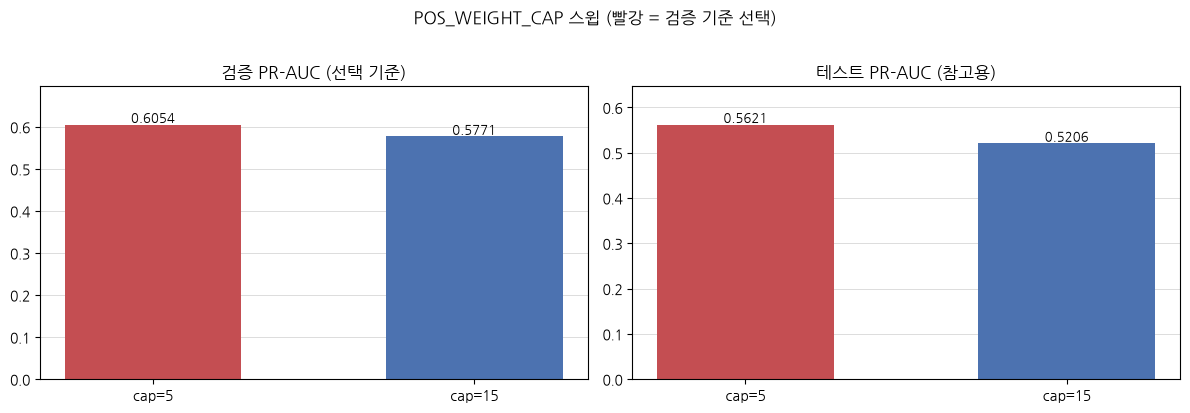


>>> 선택: POS_WEIGHT_CAP = 5 (val PR-AUC 0.6054) — §10-3·§11 에 적용됩니다. (GBT 와는 무관)


In [18]:
POS_SWEEP_ROWS, POS_SWEEP_BEST_RUN = [], None
if RUN_POS_SWEEP:
    print(f"POS_WEIGHT_CAP 스윕 {POS_CAP_SWEEP} — 시드 42 고정, 선택 기준 = val PR-AUC\n")
    _best_ap, _best_cap = -1.0, POS_WEIGHT_CAP
    for _cap in POS_CAP_SWEEP:
        _t0 = time.time()
        _r = train_one_seed(42, cfg={"POS_CAP": _cap}, verbose=False)
        _row = eval_full(_r["val_prob"], _r["test_prob"], f"cap={_cap:g}")
        _row = {"cap": _cap, **{k: v for k, v in _row.items() if k != "모델"},
                "학습(분)": round((time.time() - _t0) / 60, 1)}
        POS_SWEEP_ROWS.append(_row)
        print(f"  cap={_cap:>4g}  val PR-AUC={_row['val PR-AUC']:.4f}  "
              f"(test={_row['test PR-AUC']:.4f}, F1@튜닝={_row['F1@F1튜닝']:.2f}%, "
              f"패턴내/밖={_row.get('패턴내 R@예산', float('nan')):.1f}/"
              f"{_row.get('패턴밖 R@예산', float('nan')):.1f}%)  {_row['학습(분)']}분", flush=True)
        if _r["val_ap"] > _best_ap:
            _best_ap, _best_cap = _r["val_ap"], _cap
            POS_SWEEP_BEST_RUN = {"val_prob": _r["val_prob"], "test_prob": _r["test_prob"],
                                  "pos_cap": _cap}
        del _r
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    _sw = pd.DataFrame(POS_SWEEP_ROWS)
    print("\n── 스윕 결과 ──")
    print(_sw[["cap", "val PR-AUC", "test PR-AUC", "F1@F1튜닝", "F1@예산0.1%"] + SCEN_COLS + ["학습(분)"]]
          .round(4).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, colname, ttl in [(axes[0], "val PR-AUC", "검증 PR-AUC (선택 기준)"),
                             (axes[1], "test PR-AUC", "테스트 PR-AUC (참고용)")]:
        colors = ["#C44E52" if c == _best_cap else "#4C72B0" for c in _sw["cap"]]
        bars = ax.bar([f"cap={c:g}" for c in _sw["cap"]], _sw[colname], color=colors, width=0.55)
        for b, v in zip(bars, _sw[colname]):
            ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(ttl); ax.set_ylim(0, float(_sw[colname].max()) * 1.15)
        ax.grid(axis="y", lw=0.6, alpha=0.5); ax.set_axisbelow(True)
    plt.suptitle("POS_WEIGHT_CAP 스윕 (빨강 = 검증 기준 선택)", y=1.02)
    plt.tight_layout(); plt.show()

    POS_WEIGHT_CAP = float(_best_cap)
    print(f"\n>>> 선택: POS_WEIGHT_CAP = {POS_WEIGHT_CAP:g} (val PR-AUC {_best_ap:.4f}) — "
          f"§10-3·§11 에 적용됩니다. (GBT 와는 무관)")
else:
    print(f"RUN_POS_SWEEP = False — 스윕 생략, POS_WEIGHT_CAP = {POS_WEIGHT_CAP:g} 유지.")


### 10-3. 확장 탐욕 스윕 — v9 신규 축 포함

§10-2와 같은 원칙 — **시드 42 고정, 검증 PR-AUC로만 선택, test는 참고 표기** — 을 유지하고
탐색 축에 **요청사항 1-3·§2 항목을 전부** 넣었습니다.

| 순서 | 축 | 후보 | 대응 요청사항 |
|---|---|---|---|
| 1 | `HIDDEN` | 128 / 256 | 용량 |
| 2 | `N_LAYERS` | 2 / 3 | 수용 영역 |
| 3 | `AUX_NODE_W` | 0.3 / 0.6 | 계좌 보조 손실 |
| 4 | `MSG_DROPOUT` | 0 / 0.1 | 전파 정규화 |
| 5 | `GLOBAL_ACCT` | off / **on** | **1-3 ①** 계좌 전역 이력 피처 |
| 6 | `LOSS` | bce / focal γ=1 / focal γ=2 | **1-3 ②** focal · hard-example |
| 7 | `AGGRS` | sum / **PNA 4집계자** | **§2** 다중 집계자 |
| 8 | `EGO` | off / **on** | **§2** Ego-ID (포트 번호와의 결합 효과) |
| 9 | `REV_W` | 1.0 / 0.5 / 0.0 | **§2** 양방향 엣지 업데이트 강도 |
| 10 | `PERSIST` | 0 / 32 | **§2** persistent account state |

* 전체 격자 대신 한 축씩 확정하는 **탐욕 탐색** — 최대 13회 추가 학습
* **모든 행이 패턴 내/밖 재현율을 함께 기록**합니다 (요청사항 1-3 ④). 전체 PR-AUC만 오르고
  패턴 밖이 그대로인 기법을 이 표에서 바로 걸러낼 수 있습니다
* 이 표는 §13-3 ablation 의 1차 근거로도 그대로 재사용됩니다 (같은 시드·같은 프로토콜)


In [19]:
HP_SWEEP_ROWS, HP_BEST_RUN, FINAL_CFG = [], None, None
if RUN_HP_SWEEP:
    _seen = {}

    def _measure(cfg, tag="", base=None):
        k = cfg_key(cfg)
        if k in _seen:
            return _seen[k]
        _t0 = time.time()
        r = train_one_seed(42, cfg=cfg, verbose=False)
        row = eval_full(r["val_prob"], r["test_prob"], cfg_label(cfg))
        rec = {"설정": cfg_label(cfg), "축": tag,
               **{kk: vv for kk, vv in row.items() if kk != "모델"},
               "파라미터": r["n_params"], "학습(분)": round((time.time() - _t0) / 60, 1),
               "_val": r["val_ap"], "_probs": (r["val_prob"], r["test_prob"]), "_cfg": dict(cfg),
               # [v9] 이 시행이 "어떤 구성에서 1축만 바꾼 것"인지 기록 →
               #      §13-3 이 교란 없는 1축 ON/OFF 짝을 인용할 수 있게 합니다.
               "_base": (cfg_key(base) if base is not None else None)}
        del r
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        _seen[k] = rec
        HP_SWEEP_ROWS.append(rec)
        print(f"  [{tag:<11s}] {rec['설정']:<62s} val={rec['val PR-AUC']:.4f} "
              f"(test={rec['test PR-AUC']:.4f}, 패턴내/밖="
              f"{rec.get('패턴내 R@예산', float('nan')):.1f}/{rec.get('패턴밖 R@예산', float('nan')):.1f}%)"
              f"  {rec['학습(분)']}분", flush=True)
        return rec

    print("확장 탐욕 스윕 — 시드 42 고정, 선택 기준 = 검증 PR-AUC (test 는 표기만)\n")
    cur = cfg_from_globals(); cur["POS_CAP"] = float(POS_WEIGHT_CAP)
    best = _measure(cur, "기준")
    for _pname, _cands in HP_STAGES:
        for _v in _cands:
            if _v == cur[_pname]:
                continue
            _trial = dict(cur); _trial[_pname] = _v
            _rec = _measure(_trial, _pname, base=cur)
            if _rec["_val"] > best["_val"]:
                best, cur = _rec, _trial
        print(f"  ── {_pname} 확정: {cur[_pname]}", flush=True)

    FINAL_CFG = dict(cur)
    HP_BEST_RUN = {"val_prob": best["_probs"][0], "test_prob": best["_probs"][1],
                   "config": dict(cur)}

    # 전역 반영 — §11 본학습 / §13 ablation / §14 비교가 전부 같은 구성으로 돕니다
    HIDDEN, N_LAYERS = int(cur["HIDDEN"]), int(cur["N_LAYERS"])
    AUX_NODE_W, MSG_DROPOUT = float(cur["AUX_NODE_W"]), float(cur["MSG_DROPOUT"])
    USE_NODE_AUX = AUX_NODE_W > 0
    USE_GLOBAL_ACCT_FEATS = bool(cur["GLOBAL_ACCT"])
    USE_EGO_ID = bool(cur["EGO"])
    LOSS_TYPE, FOCAL_GAMMA = parse_loss(cur["LOSS"])
    PNA_AGGRS = ("sum", "mean", "max", "std") if cur["AGGRS"] == "pna4" else ("sum",)
    REV_EDGE_W = float(cur["REV_W"])
    PERSIST_DIM = int(cur["PERSIST"])
    refresh_dims()

    _hp = pd.DataFrame([{k: v for k, v in r_.items() if not k.startswith("_")} for r_ in HP_SWEEP_ROWS])
    print("\n── 스윕 전체 결과 (패턴 내/밖 재현율 포함) ──")
    print(_hp[["축", "설정", "val PR-AUC", "test PR-AUC", "F1@F1튜닝"] + SCEN_COLS + ["파라미터", "학습(분)"]]
          .round(4).to_string(index=False))
    print(f"\n>>> 최종 선택: {cfg_label(cur)}")
    print(f"    (val PR-AUC {best['_val']:.4f}) — §11 본학습(4시드)에 적용됩니다.")
    print(f"    노드 피처 {node_dim_total()}차원 / 손실={LOSS_TYPE}(γ={FOCAL_GAMMA:g}) / "
          f"집계자={PNA_AGGRS} / rev_w={REV_EDGE_W:g} / persist={PERSIST_DIM}")
else:
    FINAL_CFG = cfg_from_globals()
    print(f"RUN_HP_SWEEP = False — 확장 스윕 생략 ({cfg_label(FINAL_CFG)}).")


확장 탐욕 스윕 — 시드 42 고정, 선택 기준 = 검증 PR-AUC (test 는 표기만)

  [기준         ] h256/L2/aux0.6/md0.1/glob1/bce/sum/ego0/rev1/pst0              val=0.6080 (test=0.5620, 패턴내/밖=86.1/1.5%)  7.9분
  [GLOBAL_ACCT] h256/L2/aux0.6/md0.1/glob0/bce/sum/ego0/rev1/pst0              val=0.6335 (test=0.5843, 패턴내/밖=89.8/2.2%)  8.1분
  ── GLOBAL_ACCT 확정: False
  [LOSS       ] h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego0/rev1/pst0         val=0.6351 (test=0.5823, 패턴내/밖=89.9/1.7%)  7.8분
  [LOSS       ] h256/L2/aux0.6/md0.1/glob0/focal2.0/sum/ego0/rev1/pst0         val=0.6327 (test=0.5747, 패턴내/밖=89.0/2.0%)  7.8분
  ── LOSS 확정: focal1.0
  [AGGRS      ] h256/L2/aux0.6/md0.1/glob0/focal1.0/pna4/ego0/rev1/pst0        val=0.6291 (test=0.5857, 패턴내/밖=90.2/2.2%)  9.6분
  ── AGGRS 확정: sum
  [EGO        ] h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego1/rev1/pst0         val=0.6322 (test=0.5734, 패턴내/밖=89.9/2.0%)  8.0분
  ── EGO 확정: False
  [REV_W      ] h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego0/rev0.5/pst0       val=0.6354 (test=0

### 10-4. [v9 신규 · 1-1 ④] AMP 안전장치 A/B — "성능 저하 없이 안정성만 확보했는가"

요청사항 1-1 ④ 에 대한 직접 답입니다. **양팔 완전히 동일한 조건**(같은 시드·같은 구성·같은 에폭 수)에서
안전장치만 켜고 끄고 비교합니다.

| 팔 | dtype | clamp | 확인하려는 것 |
|---|---|---|---|
| **A** | fp16 강제 | **ON** | 안전장치를 켠 fp16 이 정상 학습되는가 |
| **B** | fp16 강제 | **OFF** | v8에서 터진 그 경로 — 실제로 NaN 이 나는가 |
| **C** | bf16 (기본 경로) | (무동작) | v9 기본 경로의 성능 — A와 같아야 안전장치가 공짜 |

**판정 논리 (중요).** clamp 는 `|agg| > 상한×AGG_CLAMP_FRAC` 인 원소에만 작용합니다.
따라서 학습 중 관측된 **최대 여유율이 `AGG_CLAMP_FRAC` 미만이면 clamp 는 수학적으로 항등함수**이고,
성능 차이가 있을 수 없습니다. 아래 표는 그 여유율을 함께 출력해 **"동일함"을 우연이 아니라 구조적으로**
보이도록 했습니다.

> GPU가 없거나 CUDA 미사용이면 이 셀은 자동 스킵됩니다(fp32 경로에는 이 오버플로가 존재하지 않음).


In [20]:
AMP_AB_RESULT = None
if RUN_AMP_AB and DEVICE.type == "cuda" and USE_AMP:
    _arms = [("A: fp16 + clamp(ON)", torch.float16, True),
             ("B: fp16, clamp 없음(OFF)", torch.float16, False)]
    if torch.cuda.is_bf16_supported():
        _arms.append(("C: bf16 (v9 기본 경로)", torch.bfloat16, True))

    _rows = []
    print(f"AMP 안전장치 A/B — 시드 42, {AMP_AB_EPOCHS} 에폭 동일 프로토콜, 구성={cfg_label(FINAL_CFG)}\n")
    for _nm, _dt, _cl in _arms:
        _t0 = time.time()
        try:
            _r = train_one_seed(42, cfg=FINAL_CFG, epochs=AMP_AB_EPOCHS, patience=AMP_AB_EPOCHS,
                                verbose=False, amp_dtype=_dt, agg_clamp=_cl)
            _rows.append({"팔": _nm, "dtype": _r["amp_dtype"], "clamp": _cl,
                          "val PR-AUC": _r["val_ap"],
                          "test PR-AUC": float(average_precision_score(test_y, _r["test_prob"])),
                          "max 여유율(%)": _r["max_headroom"] * 100,
                          "건너뛴 스텝": _r["skipped_steps"], "상태": "정상",
                          "학습(분)": round((time.time() - _t0) / 60, 1)})
            del _r
        except (FloatingPointError, RuntimeError, ValueError) as _e:
            _rows.append({"팔": _nm, "dtype": str(_dt).split(".")[-1], "clamp": _cl,
                          "val PR-AUC": float("nan"), "test PR-AUC": float("nan"),
                          "max 여유율(%)": float("nan"), "건너뛴 스텝": None,
                          "상태": f"💥 크래시: {type(_e).__name__}",
                          "학습(분)": round((time.time() - _t0) / 60, 1)})
            print(f"  [{_nm}] 크래시 — {str(_e)[:200]}")
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  [{_nm}] {_rows[-1]['상태']}  val={_rows[-1]['val PR-AUC']:.4f}  "
              f"여유율={_rows[-1]['max 여유율(%)']:.2f}%  {_rows[-1]['학습(분)']}분", flush=True)

    _ab = pd.DataFrame(_rows)
    print("\n── AMP 안전장치 A/B ──")
    print(_ab.round(4).to_string(index=False))

    _a = next((r for r in _rows if r["팔"].startswith("A")), None)
    _b = next((r for r in _rows if r["팔"].startswith("B")), None)
    _c = next((r for r in _rows if r["팔"].startswith("C")), None)
    _verdict = []
    if _a and _c and np.isfinite(_a["val PR-AUC"]) and np.isfinite(_c["val PR-AUC"]):
        _d = _a["val PR-AUC"] - _c["val PR-AUC"]
        _verdict.append(f"A(fp16+clamp) vs C(bf16): val PR-AUC 차이 {_d:+.4f} "
                        f"({abs(_d)/max(_c['val PR-AUC'],1e-9)*100:.2f}%)")
    if _a and np.isfinite(_a["max 여유율(%)"]):
        _hf = _a["max 여유율(%)"] / 100
        _verdict.append(
            f"관측 최대 여유율 {_hf*100:.2f}% vs clamp 발동선 {AGG_CLAMP_FRAC*100:.0f}% → "
            + ("clamp 는 **한 번도 발동하지 않았습니다(항등함수)** — 성능 저하가 구조적으로 불가능"
               if _hf < AGG_CLAMP_FRAC else
               "clamp 가 실제로 발동했습니다 — 아래 val 차이가 그 대가입니다"))
    if _b:
        _verdict.append("B(clamp OFF) 결과: " + str(_b["상태"]) +
                        (f", val={_b['val PR-AUC']:.4f}" if np.isfinite(_b["val PR-AUC"]) else ""))
    print("\n[판정]")
    for _v in _verdict:
        print("  •", _v)
    if _a is not None and not np.isfinite(_a["val PR-AUC"]):
        print("  ⛔ **A(안전장치 ON) 팔이 크래시했습니다** — 1-1 안전장치가 제 역할을 못 하고 있습니다. "
              "clamp 게이팅(autocast_lowp)·AGG_CLAMP_FRAC 을 점검하거나 USE_AMP=False 로 두십시오.")
    print(f"  • 주의: A/B 는 {AMP_AB_EPOCHS} 에폭 단축 프로토콜입니다. B가 살아남더라도 "
          f"'안전하다'는 증거가 아닙니다 — v8 성능판에서는 본학습 중반(집계 계수가 3~10배로 커진 뒤)에 터졌습니다.")
    AMP_AB_RESULT = {"rows": _rows, "epochs": AMP_AB_EPOCHS,
                     "clamp_frac": AGG_CLAMP_FRAC, "verdict": _verdict}
else:
    print("RUN_AMP_AB=False 이거나 CUDA/AMP 미사용 — A/B 스킵 "
          "(fp32 경로에는 저정밀 캐스팅 오버플로가 존재하지 않습니다).")


AMP 안전장치 A/B — 시드 42, 6 에폭 동일 프로토콜, 구성=h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego0/rev0.5/pst0

  [A: fp16 + clamp(ON)] 정상  val=0.4958  여유율=19.67%  0.7분
  [B: fp16, clamp 없음(OFF)] 정상  val=0.4945  여유율=19.67%  0.7분
  [C: bf16 (v9 기본 경로)] 정상  val=0.4935  여유율=0.00%  2.0분

── AMP 안전장치 A/B ──
                     팔    dtype  clamp  val PR-AUC  test PR-AUC  max 여유율(%)  건너뛴 스텝 상태  학습(분)
   A: fp16 + clamp(ON)  float16   True      0.4958       0.4714     19.6709       0 정상    0.7
B: fp16, clamp 없음(OFF)  float16  False      0.4945       0.4705     19.6709       0 정상    0.7
    C: bf16 (v9 기본 경로) bfloat16   True      0.4935       0.4697      0.0000       0 정상    2.0

[판정]
  • A(fp16+clamp) vs C(bf16): val PR-AUC 차이 +0.0022 (0.45%)
  • 관측 최대 여유율 19.67% vs clamp 발동선 25% → clamp 는 **한 번도 발동하지 않았습니다(항등함수)** — 성능 저하가 구조적으로 불가능
  • B(clamp OFF) 결과: 정상, val=0.4945
  • 주의: A/B 는 6 에폭 단축 프로토콜입니다. B가 살아남더라도 '안전하다'는 증거가 아닙니다 — v8 성능판에서는 본학습 중반(집계 계수가 3~10배로 커진 뒤)에 터졌습니다.


## 11. 다중 시드 학습

단일 시드 결과는 운이 섞입니다. 평균±표준편차 보고 + 시드 앙상블(분산을 줄이는 가장 저렴한 일반화 개선책).
§10-2·§10-3 에서 **검증 PR-AUC로만** 선택된 구성이 그대로 적용됩니다.


본학습 구성: h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego0/rev0.5/pst0 / cap=5 / AMP=bfloat16

===== seed 0 =====
  seed0 ep  1/25  loss=0.1798  val PR-AUC=0.0139  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  2/25  loss=0.1283  val PR-AUC=0.0950  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  3/25  loss=0.1237  val PR-AUC=0.3735  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  4/25  loss=0.1196  val PR-AUC=0.4291  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  5/25  loss=0.1157  val PR-AUC=0.5050  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  6/25  loss=0.1125  val PR-AUC=0.5154  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  7/25  loss=0.1120  val PR-AUC=0.5400  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  8/25  loss=0.1113  val PR-AUC=0.5596  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep  9/25  loss=0.1104  val PR-AUC=0.5667  lr=5.0e-04  agg여유율=0.00%  (19s)  <- best
  seed0 ep 10/25  loss=0.1085  val PR-AUC=0.5765  lr=5.0e-04  agg여유율=0.00

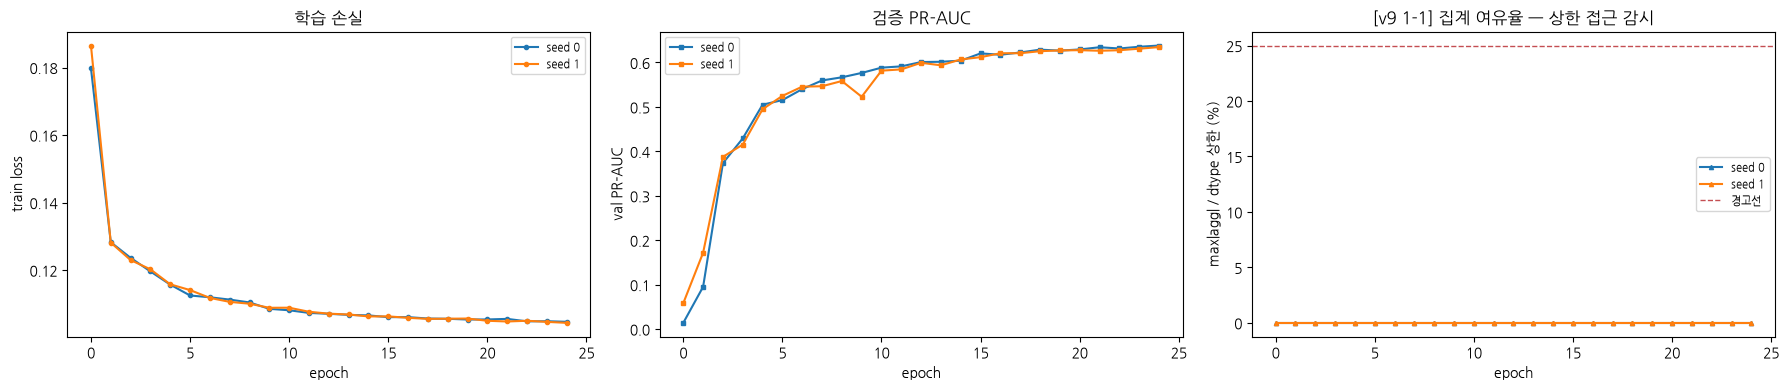

In [21]:
t_all = time.time()
runs = []
print(f"본학습 구성: {cfg_label(FINAL_CFG)} / cap={POS_WEIGHT_CAP:g} / "
      f"AMP={str(AMP_DTYPE).split('.')[-1] if (USE_AMP and DEVICE.type=='cuda') else 'off(fp32)'}\n")
for s in SEED_LIST:
    print(f"===== seed {s} =====", flush=True)
    r = train_one_seed(s, cfg=FINAL_CFG)
    print(f"  best val PR-AUC = {r['val_ap']:.4f} / max agg 여유율 {r['max_headroom']*100:.2f}% / "
          f"건너뛴 스텝 {r['skipped_steps']}", flush=True)
    runs.append(r)
print(f"\n총 학습 시간 {(time.time()-t_all)/60:.1f}분")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for r in runs:
    axes[0].plot(r["history"]["train_loss"], "o-", ms=3, label=f"seed {r['seed']}")
    axes[1].plot(r["history"]["val_ap"], "s-", ms=3, label=f"seed {r['seed']}")
    axes[2].plot(np.array(r["history"]["headroom"]) * 100, "^-", ms=3, label=f"seed {r['seed']}")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("train loss"); axes[0].set_title("학습 손실")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val PR-AUC"); axes[1].set_title("검증 PR-AUC")
axes[2].axhline(AMP_HEADROOM_WARN * 100, color="#C44E52", ls="--", lw=1, label="경고선")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("max|agg| / dtype 상한 (%)")
axes[2].set_title("[v9 1-1] 집계 여유율 — 상한 접근 감시")
for a in axes: a.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 12. 평가 — 소수클래스 Precision / Recall / F1 (테스트셋)

| 임계값 | 정의 | 왜 보는가 |
|---|---|---|
| **0.5** | 고정 | 팀원 GBT 프로토콜과 동일 조건 비교용 |
| **F1 튜닝** | 검증셋 F1 최대점 | 검증→테스트 분포 이동에 민감 |
| **경보 예산** | 테스트 거래의 상위 `ALERT_BUDGET`(0.1%)만 알림 | **운영 현실**: 조사 인력이 하루에 볼 수 있는 건수는 고정 |


In [22]:
rows = [evaluate(r["val_prob"], r["test_prob"], f"GNN seed {r['seed']}") for r in runs]
ens_v = np.mean([r["val_prob"] for r in runs], axis=0)
ens_t = np.mean([r["test_prob"] for r in runs], axis=0)
row_ens = evaluate(ens_v, ens_t, f"GNN 앙상블({len(runs)}시드)")

res = pd.DataFrame(rows)
summary = pd.DataFrame([
    {"모델": f"GNN 단일(평균±표준편차, n={len(runs)})",
     **{c: f"{res[c].mean():.2f} ± {res[c].std(ddof=1):.2f}" for c in res.columns if c != "모델"}},
    {"모델": row_ens["모델"], **{c: f"{row_ens[c]:.2f}" for c in row_ens if c != "모델"}},
])
pd.set_option("display.width", 220, "display.max_columns", 60)
print("── 시드별 원시 결과 ──")
print(res.round(4).to_string(index=False))
print("\n── 요약 ──")
print(summary.to_string(index=False))
GNN_ENS, GNN_MEAN = row_ens, res


── 시드별 원시 결과 ──
        모델  val PR-AUC  test PR-AUC   P@0.5   R@0.5  F1@0.5  P@F1튜닝  R@F1튜닝  F1@F1튜닝  P@예산0.1%  R@예산0.1%  F1@예산0.1%  thr_F1  thr_예산
GNN seed 0      0.6382       0.5891 50.7849 56.6054 53.5374 83.5994 50.3937  62.8821   61.2967   54.5932    57.7510  0.7813  0.5756
GNN seed 1      0.6347       0.5803 77.0323 52.2310 62.2523 78.8694 51.2686  62.1421   61.2365   54.5932    57.7243  0.5244  0.3951

── 요약 ──
                  모델  val PR-AUC test PR-AUC         P@0.5        R@0.5       F1@0.5       P@F1튜닝       R@F1튜닝      F1@F1튜닝     P@예산0.1%     R@예산0.1%    F1@예산0.1%      thr_F1      thr_예산
GNN 단일(평균±표준편차, n=2) 0.64 ± 0.00 0.58 ± 0.01 63.91 ± 18.56 54.42 ± 3.09 57.89 ± 6.16 81.23 ± 3.34 50.83 ± 0.62 62.51 ± 0.52 61.27 ± 0.04 54.59 ± 0.00 57.74 ± 0.02 0.65 ± 0.18 0.49 ± 0.13
        GNN 앙상블(2시드)        0.64        0.59         64.72        54.24        59.02        81.14        51.18        62.77        61.61        54.77        57.99        0.64        0.48


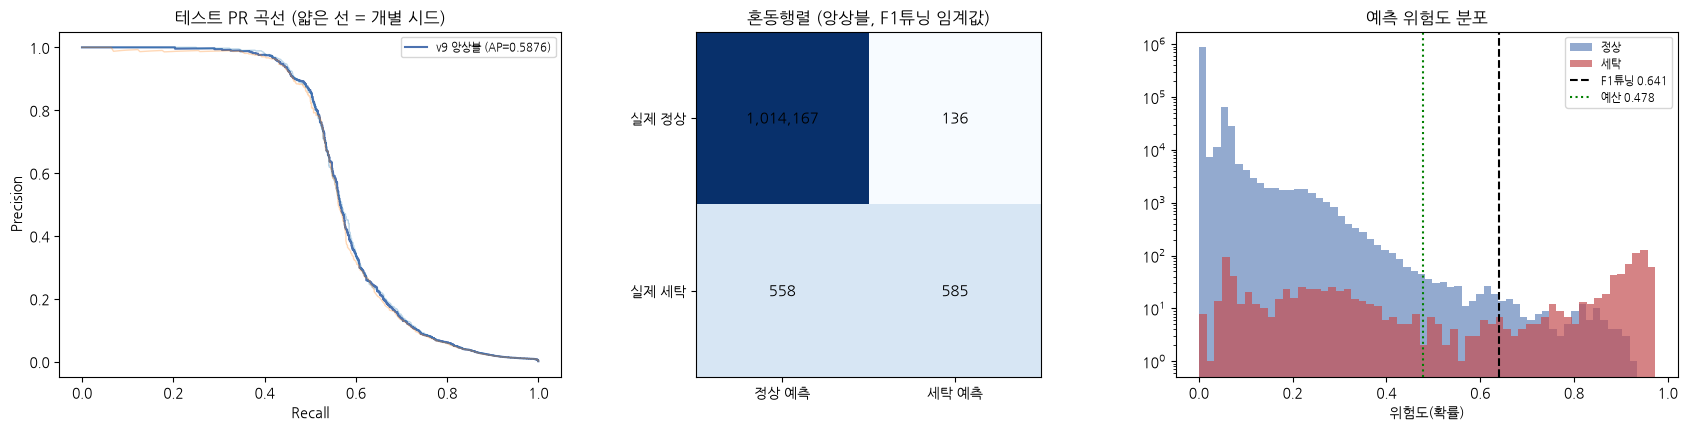

기준선(전부 정상 예측) 정확도 = 99.8874%
주의: 세탁 비율이 극히 낮아 정확도는 모델 비교에 쓰지 마세요 (PR-AUC/F1 사용).


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
test_pred = (ens_t >= row_ens["thr_F1"]).astype(int)

tp_c, tr_c, _ = precision_recall_curve(test_y, ens_t)
axes[0].plot(tr_c, tp_c, color="#4C72B0", label=f"v9 앙상블 (AP={row_ens['test PR-AUC']:.4f})")
for r in runs:
    p_, r_, _ = precision_recall_curve(test_y, r["test_prob"])
    axes[0].plot(r_, p_, alpha=0.3, lw=1)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].legend(fontsize=8)
axes[0].set_title("테스트 PR 곡선 (얇은 선 = 개별 시드)")

cm = confusion_matrix(test_y, test_pred)
axes[1].imshow(np.log1p(cm), cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11)
axes[1].set_xticks([0, 1], ["정상 예측", "세탁 예측"])
axes[1].set_yticks([0, 1], ["실제 정상", "실제 세탁"])
axes[1].set_title("혼동행렬 (앙상블, F1튜닝 임계값)")

axes[2].hist(ens_t[test_y == 0], bins=60, alpha=0.6, label="정상", color="#4C72B0", log=True)
axes[2].hist(ens_t[test_y == 1], bins=60, alpha=0.7, label="세탁", color="#C44E52", log=True)
axes[2].axvline(row_ens["thr_F1"], color="k", ls="--", label=f"F1튜닝 {row_ens['thr_F1']:.3f}")
axes[2].axvline(row_ens["thr_예산"], color="g", ls=":", label=f"예산 {row_ens['thr_예산']:.3f}")
axes[2].legend(fontsize=8); axes[2].set_title("예측 위험도 분포"); axes[2].set_xlabel("위험도(확률)")
plt.tight_layout(); plt.show()

print(f"기준선(전부 정상 예측) 정확도 = {(1-test_y.mean())*100:.4f}%")
print("주의: 세탁 비율이 극히 낮아 정확도는 모델 비교에 쓰지 마세요 (PR-AUC/F1 사용).")


### 12-2. 계좌 단위 보조 판정 (화두 1)

개별 거래 라벨의 노이즈는 거래 단위 모델로는 못 없앱니다. 그래서 **판정의 최종 단위를 계좌로 끌어올린**
보조 지표를 병행합니다 — 실무(조사·STR)도 결국 계좌/고객 단위로 진행됩니다.


테스트 구간 등장 계좌 356,260개, 세탁 관여 계좌 1,671개 (0.4690%)

── 판정 단위 비교 (동일 예산 0.1%) ──
      판정 단위  PR-AUC  P@예산0.1%  R@예산0.1%  경보 수
    계좌(최댓값)  0.5429  100.0000   21.3645   357
 계좌(상위3 평균)  0.3687   81.5126   17.4147   357
거래(§12 앙상블)  0.5876   61.6142   54.7682  1016


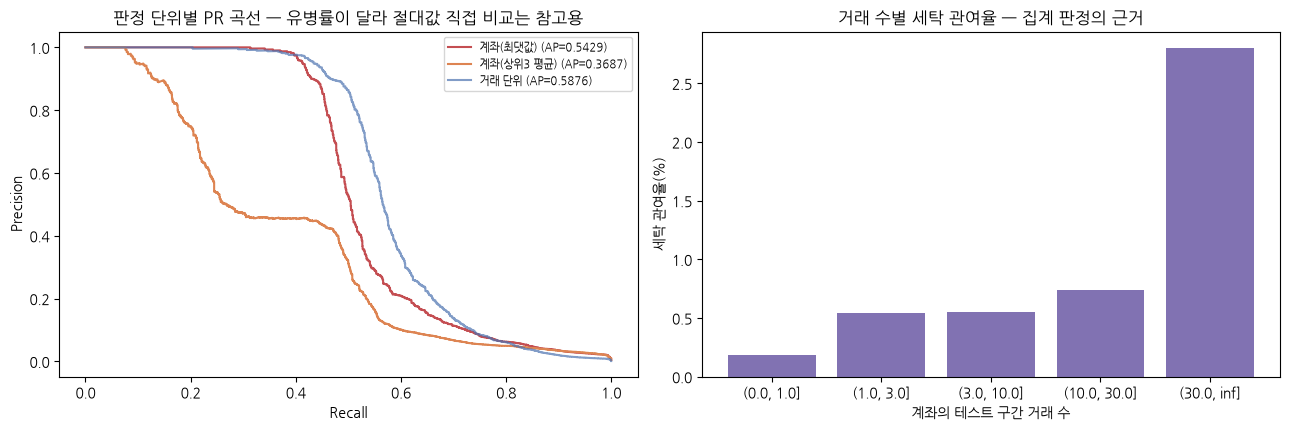

In [24]:
tdf = df.iloc[n_va:]
acct2 = np.concatenate([tdf["src_id"].to_numpy(), tdf["dst_id"].to_numpy()])
prob2 = np.concatenate([ens_t, ens_t])
lab2  = np.concatenate([test_y, test_y])

A = pd.DataFrame({"acct": acct2, "p": prob2, "y": lab2})
acct_df = A.groupby("acct").agg(score_max=("p", "max"), n_tx=("p", "size"), y=("y", "max"))
top3 = (A.sort_values("p", ascending=False).groupby("acct").head(3)
        .groupby("acct")["p"].mean().rename("score_top3"))
acct_df = acct_df.join(top3)
acct_y = acct_df["y"].to_numpy()
print(f"테스트 구간 등장 계좌 {len(acct_df):,}개, 세탁 관여 계좌 {int(acct_y.sum()):,}개 "
      f"({acct_y.mean()*100:.4f}%)")

acct_rows = []
for colname, tag in [("score_max", "계좌(최댓값)"), ("score_top3", "계좌(상위3 평균)")]:
    sc = acct_df[colname].to_numpy()
    thr_b = float(np.quantile(sc, 1 - ALERT_BUDGET))
    yp = (sc >= thr_b).astype(int)
    acct_rows.append({"판정 단위": tag, "PR-AUC": average_precision_score(acct_y, sc),
                      "P@예산0.1%": precision_score(acct_y, yp, zero_division=0) * 100,
                      "R@예산0.1%": recall_score(acct_y, yp, zero_division=0) * 100,
                      "경보 수": int(yp.sum())})
acct_rows.append({"판정 단위": "거래(§12 앙상블)", "PR-AUC": row_ens["test PR-AUC"],
                  "P@예산0.1%": row_ens["P@예산0.1%"], "R@예산0.1%": row_ens["R@예산0.1%"],
                  "경보 수": int((ens_t >= row_ens["thr_예산"]).sum())})
acct_res = pd.DataFrame(acct_rows)
print("\n── 판정 단위 비교 (동일 예산 0.1%) ──")
print(acct_res.round(4).to_string(index=False))
ACCT_RESULT = acct_res.to_dict("records")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for colname, lab_, c_ in [("score_max", "계좌(최댓값)", "#C44E52"),
                          ("score_top3", "계좌(상위3 평균)", "#DD8452")]:
    p_, r_, _ = precision_recall_curve(acct_y, acct_df[colname].to_numpy())
    axes[0].plot(r_, p_, color=c_,
                 label=f"{lab_} (AP={average_precision_score(acct_y, acct_df[colname]):.4f})")
p_, r_, _ = precision_recall_curve(test_y, ens_t)
axes[0].plot(r_, p_, color="#4C72B0", alpha=0.7, label=f"거래 단위 (AP={row_ens['test PR-AUC']:.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("판정 단위별 PR 곡선 — 유병률이 달라 절대값 직접 비교는 참고용")
axes[0].legend(fontsize=8)
grp = acct_df.groupby(pd.cut(acct_df["n_tx"], [0, 1, 3, 10, 30, np.inf]), observed=True)["y"].mean() * 100
axes[1].bar([str(i) for i in grp.index], grp.values, color="#8172B2")
axes[1].set_xlabel("계좌의 테스트 구간 거래 수"); axes[1].set_ylabel("세탁 관여율(%)")
axes[1].set_title("거래 수별 세탁 관여율 — 집계 판정의 근거")
plt.tight_layout(); plt.show()


### 12-3. 시나리오(패턴 블록) 단위 평가 + 패턴 내/밖 분리 재현율

거래 단위 재현율은 "라벨 1인 행을 몇 개 맞혔나"입니다. 실무 의미가 큰 질문은 따로 있습니다 —
**세탁 사건(시나리오) 중 몇 개를, 얼마나 일찍 적발했는가.**

* **시나리오 재현율** = 탐지 블록 수 ÷ test 구간에 거래가 걸친 블록 수
* **탐지 지연** = 블록의 거래를 시간순으로 세웠을 때 몇 번째에서 첫 적발했는가
* **패턴 내/밖 분리 재현율** ← **v9의 핵심 지표.** §8-4에서 선행 계산한 인덱스를 쓰며,
  §10-3 스윕·§13 ablation·§14-4 하이브리드가 **전부 같은 함수(`scenario_metrics`)** 로 보고합니다.


패턴 블록 매칭 363개 (미매칭 거래 655건)
test 구간에 거래가 걸친 블록: 183개

■ 시나리오 재현율(경보 예산 0.1%): 173/183 = 94.5%
■ 탐지 지연: 첫 적발이 체인의 중앙값 2번째 거래 (체인 길이 대비 67% 지점)

■ 거래 단위 재현율 분리(@예산): 패턴 내 89.9% (684건) vs 패턴 밖 2.4% (459건)
   → v8 기록: 패턴 내 91.7% vs 패턴 밖 2.6% (양성의 40.2%가 패턴 밖). v9의 §13-3 ablation 이 각 장치가 '패턴 밖'을 실제로 올렸는지 개별로 보고합니다.

── 유형별 시나리오 재현율 (test 걸친 블록 기준) ──
                블록수  탐지    재현율%
type                           
STACK            23  23  100.00
SCATTER-GATHER   23  23  100.00
CYCLE            25  24   96.00
FAN-IN           19  18   94.74
RANDOM           17  16   94.12
BIPARTITE        17  16   94.12
GATHER-SCATTER   39  36   92.31
FAN-OUT          20  17   85.00


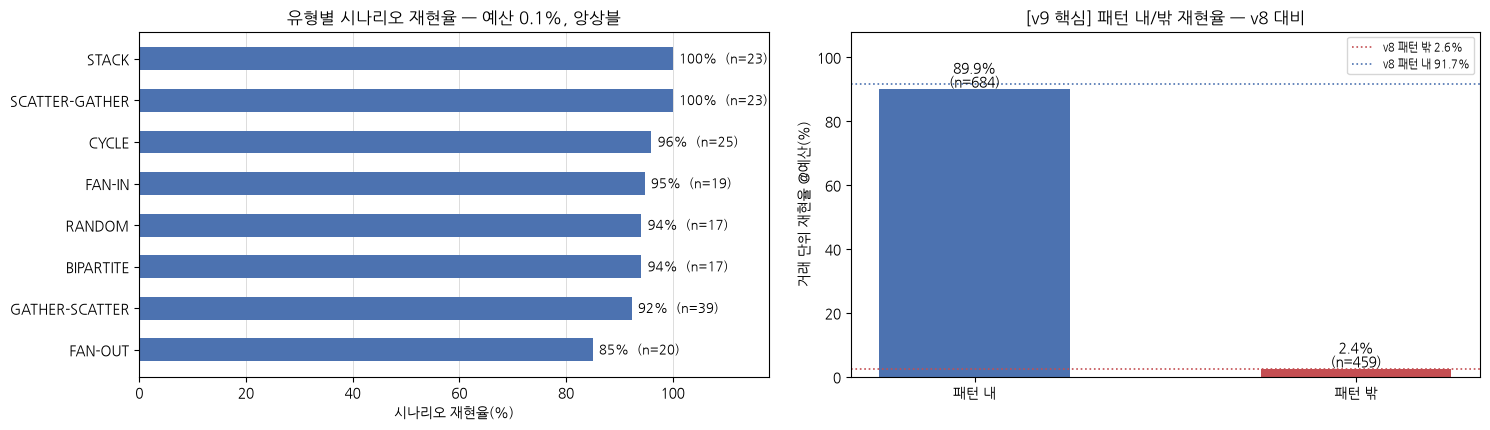

In [25]:
SCENARIO_RESULT = None
if RUN_SCENARIO_EVAL and PAT_BLOCKS:
    s = scenario_metrics(ens_t, thr=float(row_ens["thr_예산"]), with_type=True)
    print(f"패턴 블록 매칭 {len(PAT_BLOCKS)}개 (미매칭 거래 {PAT_UNMATCHED}건)")
    print(f"test 구간에 거래가 걸친 블록: {s['blocks_test_covered']}개")
    print(f"\n■ 시나리오 재현율(경보 예산 {ALERT_BUDGET*100:.1f}%): "
          f"{s['blocks_detected']}/{s['blocks_test_covered']} = {s['scenario_recall']*100:.1f}%")
    if s["median_detection_rank"]:
        print(f"■ 탐지 지연: 첫 적발이 체인의 중앙값 {s['median_detection_rank']:.0f}번째 거래 "
              f"(체인 길이 대비 {s['median_detection_frac']*100:.0f}% 지점)")
    print(f"\n■ 거래 단위 재현율 분리(@예산): 패턴 내 {s['tx_recall_in_pattern']:.1f}% "
          f"({s['n_pos_in']:,}건) vs 패턴 밖 {s['tx_recall_out_pattern']:.1f}% ({s['n_pos_out']:,}건)")
    print("   → v8 기록: 패턴 내 91.7% vs 패턴 밖 2.6% (양성의 40.2%가 패턴 밖). "
          "v9의 §13-3 ablation 이 각 장치가 '패턴 밖'을 실제로 올렸는지 개별로 보고합니다.")

    g = pd.DataFrame(s["per_type"]).set_index("type")
    print("\n── 유형별 시나리오 재현율 (test 걸친 블록 기준) ──")
    print(g.round(2).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
    bars = axes[0].barh(g.index[::-1], g["재현율%"][::-1], color="#4C72B0", height=0.55)
    for b, (nb_, v) in zip(bars, zip(g["블록수"][::-1], g["재현율%"][::-1])):
        axes[0].text(b.get_width() + 1.2, b.get_y() + b.get_height() / 2, f"{v:.0f}%  (n={nb_})",
                     va="center", fontsize=9)
    axes[0].set_xlim(0, 118); axes[0].set_xlabel("시나리오 재현율(%)")
    axes[0].set_title(f"유형별 시나리오 재현율 — 예산 {ALERT_BUDGET*100:.1f}%, 앙상블")
    axes[0].grid(axis="x", lw=0.6, alpha=0.5); axes[0].set_axisbelow(True)

    _b = axes[1].bar(["패턴 내", "패턴 밖"],
                     [s["tx_recall_in_pattern"], s["tx_recall_out_pattern"]],
                     color=["#4C72B0", "#C44E52"], width=0.5)
    for bb, v, nn2 in zip(_b, [s["tx_recall_in_pattern"], s["tx_recall_out_pattern"]],
                          [s["n_pos_in"], s["n_pos_out"]]):
        axes[1].text(bb.get_x() + bb.get_width() / 2, v, f"{v:.1f}%\n(n={nn2:,})",
                     ha="center", va="bottom", fontsize=10)
    axes[1].axhline(2.6, color="#C44E52", ls=":", lw=1.2, label="v8 패턴 밖 2.6%")
    axes[1].axhline(91.7, color="#4C72B0", ls=":", lw=1.2, label="v8 패턴 내 91.7%")
    axes[1].set_ylim(0, 108); axes[1].set_ylabel("거래 단위 재현율 @예산(%)")
    axes[1].set_title("[v9 핵심] 패턴 내/밖 재현율 — v8 대비"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    SCENARIO_RESULT = {**{k: v for k, v in s.items()}, "alert_budget": ALERT_BUDGET,
                       "unmatched_pattern_rows": int(PAT_UNMATCHED)}
else:
    print("RUN_SCENARIO_EVAL = False 또는 매칭 블록 없음 — 시나리오 평가 생략.")


### 12-4. [v9 신규 · §2] 앙상블 개수 대비 이득 / 비용

v6→v8 비교에서 "효율" 문제(모델을 늘려 얻는 이득이 비용에 비해 작다)가 지적됐습니다.
같은 지적이 v9에서 반복되지 않도록 **개수별 성능·파라미터·지연을 한 표로** 놓습니다.
지연은 §18에서 실제 측정한 값을 이 표에 채워 넣습니다(여기서는 성능·파라미터만 먼저).


In [26]:
ENS_COST_ROWS = []
for k in range(1, len(runs) + 1):
    vk = np.mean([r["val_prob"] for r in runs[:k]], axis=0)
    tk = np.mean([r["test_prob"] for r in runs[:k]], axis=0)
    rk = evaluate(vk, tk, f"{k}시드")
    sk = scenario_metrics(tk)
    ENS_COST_ROWS.append({
        "앙상블 개수": k,
        "val PR-AUC": rk["val PR-AUC"], "test PR-AUC": rk["test PR-AUC"],
        "F1@F1튜닝": rk["F1@F1튜닝"], "F1@예산0.1%": rk["F1@예산0.1%"],
        "패턴밖 R@예산": (sk["tx_recall_out_pattern"] if sk else float("nan")),
        "파라미터 합": sum(r["n_params"] for r in runs[:k]),
        "지연(ms, §18에서 채움)": None})
ENS_COST = pd.DataFrame(ENS_COST_ROWS)
ENS_COST["Δ test PR-AUC(직전 대비)"] = ENS_COST["test PR-AUC"].diff().round(4)
print("── 앙상블 개수별 이득/비용 ──")
print(ENS_COST.drop(columns=["지연(ms, §18에서 채움)"]).round(4).to_string(index=False))
_gain = ENS_COST["test PR-AUC"].iloc[-1] - ENS_COST["test PR-AUC"].iloc[0]
print(f"\n1시드 → {len(runs)}시드 이득: test PR-AUC {_gain:+.4f} "
      f"(파라미터 {len(runs)}배, 지연은 §18 참조)")
print("운영 권장: 이득이 지연 예산을 정당화하지 못하면 단일 모델 + 예산 기반 임계값으로 운영하십시오.")


── 앙상블 개수별 이득/비용 ──
 앙상블 개수  val PR-AUC  test PR-AUC  F1@F1튜닝  F1@예산0.1%  패턴밖 R@예산  파라미터 합  Δ test PR-AUC(직전 대비)
      1      0.6382       0.5891  62.8821    57.7510    2.1786 1039876                   NaN
      2      0.6385       0.5876  62.7682    57.9898    2.3965 2079752               -0.0015

1시드 → 2시드 이득: test PR-AUC -0.0015 (파라미터 2배, 지연은 §18 참조)
운영 권장: 이득이 지연 예산을 정당화하지 못하면 단일 모델 + 예산 기반 임계값으로 운영하십시오.


## 13. 어떤 개선이 얼마나 기여했나 (ablation)

각 개선안을 **하나씩 누적**하며 동일 시드(42)·동일 프로토콜로 학습해 비교합니다.

> **수치는 하드코딩하지 않습니다.** `RUN_ABLATION = True` 로 실행했을 때 직접 측정한 값만 표시합니다.

* **[v9]** 모든 행이 **패턴 내/밖 재현율**을 함께 보고합니다 — 전체 PR-AUC만 오르고 패턴 밖은 그대로인
  개선을 표에서 즉시 구분하기 위함입니다 (요청사항 1-3 ④).
* **[v9]** 사다리 마지막에 **`+ v9 신규 장치 일괄`** 단계를 추가했습니다. 장치별 개별 기여분은 §13-3 LOO 가 담당합니다.
* 용량(`HIDDEN`/`N_LAYERS`)은 **모든 단계에서 최종 구성과 동일**하게 고정해, 사다리가 "용량 차이"가 아니라
  "지목한 요소의 차이"만 보이도록 했습니다.
* 상대 시간차 OFF 는 §7 재실행 없이 해당 컬럼을 0으로 마스킹해 측정합니다(입력 차원 유지).
  창 캐시는 **시그니처 자동 무효화**(§9-1)로 처리되므로 수동 `clear()` 누락 위험이 없습니다.


In [27]:
# ── 상대 시간차 마스킹 유틸 (§13 사다리와 §13-2 A/B 공용) ──────────────
_EF_FULL, _EF_NOTIME = MAIN["EF"], None
_TIME_IDX = [EDGE_FEATURES.index(c) for c in TIME_FEATURES]

def set_time_feats(on):
    '''엣지 피처의 시간차 컬럼을 0으로 마스킹/복원. ef_tag 로 창 캐시가 자동 무효화됩니다.'''
    global EF, _EF_NOTIME
    if on:
        MAIN["EF"] = EF = _EF_FULL
        MAIN["ef_tag"] = "full"
    else:
        if _EF_NOTIME is None:
            _EF_NOTIME = _EF_FULL.copy()
            if _TIME_IDX:
                _EF_NOTIME[:, _TIME_IDX] = 0.0
        MAIN["EF"] = EF = _EF_NOTIME
        MAIN["ef_tag"] = "notime"


ABLATION_SEED = 42
ABLATION = []

def _v9_off():
    '''v9 신규 장치를 전부 끈 cfg 조각 (= v8 구조).'''
    return dict(GLOBAL_ACCT=False, LOSS="bce", AGGRS="sum", EGO=False, REV_W=1.0, PERSIST=0)

def _v9_on():
    '''§10-3 이 val 기준으로 고른 v9 최종 장치 조합.'''
    return {k: FINAL_CFG[k] for k in ("GLOBAL_ACCT", "LOSS", "AGGRS", "EGO", "REV_W", "PERSIST")}


# (t=상대시간차, p=포트번호, m=MEGA집계, nf=노드피처수, w=윈도우, c=컨텍스트, a=계좌보조손실, v9=신규장치)
ABL_CONFIGS = [
    ("v5 기준선",        dict(t=False, p=False, m=False, nf=4, w=200_000, c=0,       a=False, v9=False)),
    ("+ 상대 시간차",     dict(t=True,  p=False, m=False, nf=4, w=200_000, c=0,       a=False, v9=False)),
    ("+ 노드피처 9종",    dict(t=True,  p=False, m=False, nf=9, w=200_000, c=0,       a=False, v9=False)),
    ("+ 포트 번호",       dict(t=True,  p=True,  m=False, nf=9, w=200_000, c=0,       a=False, v9=False)),
    ("+ MEGA 집계",      dict(t=True,  p=True,  m=True,  nf=9, w=200_000, c=0,       a=False, v9=False)),
    ("+ 컨텍스트 윈도우",  dict(t=True,  p=True,  m=True,  nf=9, w=100_000, c=100_000, a=False, v9=False)),  # = v6
    ("+ 계좌 보조 손실",   dict(t=True,  p=True,  m=True,  nf=9, w=100_000, c=100_000, a=True,  v9=False)),  # = v8
    ("+ v9 신규 장치 일괄", dict(t=True,  p=True,  m=True,  nf=9, w=100_000, c=100_000, a=True,  v9=True)),   # = v9
]

ABL_SHOW_COLS = (["설정", "val PR-AUC", "test PR-AUC", "F1@0.5", "F1@F1튜닝", "F1@예산0.1%"]
                 + SCEN_COLS + ["학습(분)"])


def show_ablation(rows, cols=(("test PR-AUC", "테스트 PR-AUC"),
                              ("패턴밖 R@예산", "패턴 밖 재현율 @예산(%)"))):
    if not rows:
        print("ablation 미실행 — RUN_ABLATION = True 로 두고 아래 셀을 실행하십시오.")
        print(f"  설정 {len(ABL_CONFIGS)}개를 시드 {ABLATION_SEED} 로 각각 학습합니다.")
        return None
    abl = pd.DataFrame(rows)
    print(abl[[c for c in ABL_SHOW_COLS if c in abl.columns]].round(4).to_string(index=False))
    cols = [c for c in cols if c[0] in abl.columns]
    if not cols:
        return abl
    fig, axes = plt.subplots(1, len(cols), figsize=(7.5 * len(cols), 4.6))
    axes = np.atleast_1d(axes)
    xs = np.arange(len(abl))
    for ax, (col, ttl) in zip(axes, cols):
        base = abl[col].iloc[0]
        colors = ["#898781"] + ["#2a78d6" if v >= base else "#e34948" for v in abl[col].iloc[1:]]
        bars = ax.bar(xs, abl[col], color=colors, width=0.6)
        ax.axhline(base, color="#0b0b0b", ls="--", lw=1, label=f"기준선 {base:.4f}")
        for b, v in zip(bars, abl[col]):
            ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        ax.set_xticks(xs); ax.set_xticklabels(abl["설정"], rotation=25, ha="right", fontsize=8)
        ax.set_ylim(0, float(abl[col].max()) * 1.2 + 1e-9)
        ax.grid(axis="y", lw=0.6, color="#e1e0d9"); ax.set_axisbelow(True)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        ax.set_title(ttl); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return abl


show_ablation(ABLATION)


ablation 미실행 — RUN_ABLATION = True 로 두고 아래 셀을 실행하십시오.
  설정 8개를 시드 42 로 각각 학습합니다.


In [28]:
if RUN_ABLATION:
    ABLATION.clear()
    print(f"ablation 시작 — 설정 {len(ABL_CONFIGS)}개 × 시드 {ABLATION_SEED} "
          f"(cap={POS_WEIGHT_CAP:g}, 용량 h{FINAL_CFG['HIDDEN']}/L{FINAL_CFG['N_LAYERS']} 고정)\n")
    try:
        for _name, _cfg in ABL_CONFIGS:
            _t0 = time.time()
            set_time_feats(_cfg["t"])
            _mcfg = {"HIDDEN": FINAL_CFG["HIDDEN"], "N_LAYERS": FINAL_CFG["N_LAYERS"],
                     "POS_CAP": float(POS_WEIGHT_CAP),
                     "AUX_NODE_W": (float(FINAL_CFG["AUX_NODE_W"]) if _cfg["a"] else 0.0),
                     "MSG_DROPOUT": (float(FINAL_CFG["MSG_DROPOUT"]) if _cfg["a"] else 0.0),
                     **(_v9_on() if _cfg["v9"] else _v9_off())}
            with window_config(USE_TIME_FEATS=_cfg["t"], USE_PORTS=_cfg["p"], USE_MEGA=_cfg["m"],
                               NODE_FEAT_DIM=_cfg["nf"], WINDOW_SIZE=_cfg["w"], CONTEXT_EDGES=_cfg["c"],
                               USE_GLOBAL_ACCT_FEATS=bool(_mcfg["GLOBAL_ACCT"]),
                               USE_EGO_ID=bool(_mcfg["EGO"])):
                _r = train_one_seed(ABLATION_SEED, cfg=_mcfg, verbose=False)
                _row = eval_full(_r["val_prob"], _r["test_prob"], _name)
            _row.pop("모델", None)
            _row = {"설정": _name, **_row, "학습(분)": round((time.time() - _t0) / 60, 1)}
            ABLATION.append(_row)
            print(f"[{len(ABLATION)}/{len(ABL_CONFIGS)}] {_name:<20s} "
                  f"test PR-AUC={_row['test PR-AUC']:.4f}  F1@튜닝={_row['F1@F1튜닝']:.2f}%  "
                  f"패턴내/밖={_row.get('패턴내 R@예산', float('nan')):.1f}/"
                  f"{_row.get('패턴밖 R@예산', float('nan')):.1f}%  ({_row['학습(분)']}분)", flush=True)
            del _r
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
    finally:
        set_time_feats(True)      # 예외가 나도 반드시 전체 설정으로 복구
        refresh_dims()
        print("\n설정 복구 완료 — 이후 셀은 v9 최종 설정으로 실행됩니다.")

    abl_df = show_ablation(ABLATION)
    if len(ABLATION) > 1:
        _d = pd.DataFrame(ABLATION)
        _d["Δ test PR-AUC"] = _d["test PR-AUC"].diff().round(4)
        _d["Δ 패턴밖 R"] = _d["패턴밖 R@예산"].diff().round(2) if "패턴밖 R@예산" in _d else None
        print("\n── 직전 설정 대비 증분 기여도 ──")
        _cols = ["설정", "test PR-AUC", "Δ test PR-AUC"]
        if "패턴밖 R@예산" in _d:
            _cols += ["패턴밖 R@예산", "Δ 패턴밖 R"]
        print(_d[_cols].to_string(index=False))
else:
    print("RUN_ABLATION = False — ablation 미실행.")


RUN_ABLATION = False — ablation 미실행.


### 13-2. 상대 시간차 피처 제거 A/B — 실데이터 이관 대비

상대 시간차 피처(Δt·최근 빈도)는 **합성 데이터 생성기의 시간 패턴에 맞춰졌을 가능성**이 있습니다.
실데이터 이관 전에 "이 피처군에 성능이 얼마나 의존하는가"를 수치로 확보해야 합니다.

* **A (포함)**: §10-3 최종 구성의 시드 42 결과 재사용(추가 학습 없음)
* **B (제거)**: 시간차 컬럼을 0으로 마스킹하고 **재학습** (평가 시만 마스킹하면 학습 분포와 어긋나 과대 추정)

| 하락폭 | 해석 | 이관 시 조치 |
|---|---|---|
| < 5% | 의존도 낮음 | 피처 유지, 이관 후 모니터링만 |
| 5~15% | 중간 의존 | 이관 초기 챔피언-챌린저 병행 운영 후 실데이터로 재판정 |
| > 15% | 강한 의존 | **합성 패턴 과적합 의심** — 재설계 또는 제거를 기본안으로 |


In [29]:
TIME_AB_RESULT = None
if RUN_TIME_AB and USE_TIME_FEATS and TIME_FEATURES:
    if HP_BEST_RUN is not None:
        a_val, a_test = HP_BEST_RUN["val_prob"], HP_BEST_RUN["test_prob"]
        a_src = "§10-3 최종 구성 시드42 재사용"
    else:
        print("A(포함) 학습 중...", flush=True)
        _rA = train_one_seed(42, cfg=FINAL_CFG, verbose=False)
        a_val, a_test = _rA["val_prob"], _rA["test_prob"]; a_src = "신규 학습 (시드42)"
        del _rA
    try:
        print(f"B(제거) 학습 중... (A: {a_src})", flush=True)
        set_time_feats(False)
        _rB = train_one_seed(42, cfg=FINAL_CFG, verbose=False)
        b_val, b_test = _rB["val_prob"], _rB["test_prob"]
        del _rB
    finally:
        set_time_feats(True)

    rowA = eval_full(a_val, a_test, "A: 시간차 포함")
    rowB = eval_full(b_val, b_test, "B: 시간차 제거(재학습)")
    ab = pd.DataFrame([rowA, rowB])
    print("\n── 상대 시간차 A/B (시드 42, 동일 프로토콜) ──")
    print(ab[["모델", "val PR-AUC", "test PR-AUC", "F1@0.5", "F1@F1튜닝"] + SCEN_COLS]
          .round(4).to_string(index=False))

    _apA, _apB = rowA["test PR-AUC"], rowB["test PR-AUC"]
    rel = (_apA - _apB) / max(_apA, 1e-9)
    verdict = ("의존도 낮음 (<5%) — 피처 유지 가능, 이관 후 모니터링만" if rel < 0.05 else
               "중간 의존 (5~15%) — 이관 초기 챔피언-챌린저 병행 운영 권장" if rel < 0.15 else
               "강한 의존 (>15%) — 합성 패턴 과적합 의심, 실데이터 학습 전 재설계/제거 기본안")
    print(f"\ntest PR-AUC: 포함 {_apA:.4f} → 제거 {_apB:.4f} (하락 {_apA-_apB:+.4f}, 상대 {rel*100:.1f}%)")
    print(f">>> 판정: {verdict}")
    print(f"    (참고) v8 기록: 상대 하락 6.7% — 중간 의존")
    TIME_AB_RESULT = {"a_source": a_src, "pr_auc_with_time": float(_apA),
                      "pr_auc_without_time": float(_apB), "abs_drop": float(_apA - _apB),
                      "rel_drop": float(rel), "verdict": verdict,
                      "out_pattern_with": float(rowA.get("패턴밖 R@예산", float("nan"))),
                      "out_pattern_without": float(rowB.get("패턴밖 R@예산", float("nan")))}
else:
    print("RUN_TIME_AB = False (또는 시간차 피처 미사용) — A/B 생략.")


B(제거) 학습 중... (A: §10-3 최종 구성 시드42 재사용)

── 상대 시간차 A/B (시드 42, 동일 프로토콜) ──
            모델  val PR-AUC  test PR-AUC  F1@0.5  F1@F1튜닝  패턴내 R@예산  패턴밖 R@예산  시나리오 재현율%
     A: 시간차 포함      0.6354       0.5783 59.1631  60.9585   89.6199    1.9608    93.4426
B: 시간차 제거(재학습)      0.6039       0.5412 54.5455  58.5084   87.2807    0.4357    94.5355

test PR-AUC: 포함 0.5783 → 제거 0.5412 (하락 +0.0372, 상대 6.4%)
>>> 판정: 중간 의존 (5~15%) — 이관 초기 챔피언-챌린저 병행 운영 권장
    (참고) v8 기록: 상대 하락 6.7% — 중간 의존


### 13-3. [v9 신규] 신규 장치 leave-one-out ablation — "각 장치가 패턴 밖을 실제로 올렸는가"

요청사항 §3(모든 신규 장치의 ON/OFF 비교표)와 1-3 ④(패턴 밖 재현율을 개별로 보고)에 대한 직접 답입니다.

* **채택된 장치**: 최종 구성에서 **그 장치 하나만 끄고** 시드 42로 재학습 → 엄격한 LOO 기여분
  (§10-3 탐욕 스윕은 "그 단계까지의 구성"에서 켜고 끈 것이라 상호작용이 반영되지 않습니다)
* **미채택 장치**: §10-3 스윕에서 **그 축 하나만 다른 1축 짝**(시행 행 ↔ 그 시행이 갈라져 나온 원본 구성)을
  인용합니다 — 재학습 없이도 교란 없는 ON/OFF 대비가 됩니다.
  (스윕 전체 최댓값을 최종 구성과 비교하면 최대 8개 축이 동시에 달라 교란되고, 최종 구성이 스윕의
  argmax 이므로 Δval 이 구조적으로 항상 ≤ 0 이 되어 정보가 없습니다 — v9 감사에서 잡아 고친 부분입니다.)
* 판정 컬럼은 **val PR-AUC(채택 기준)** 와 **패턴 밖 재현율(1-3의 목표 지표)** 를 분리해 봅니다


기준(전체 ON): val=0.6354 test=0.5783 패턴내/밖=89.6/2.0%

  전역 계좌 이력 피처 (1-3①)         미채택 — 1축 짝 인용 (ON 0.6080 vs OFF 0.6335, 재학습 생략)
  focal loss (1-3②)          ON 0.6354 vs OFF 0.6338 (Δval +0.0017, Δ패턴밖 +0.2%p)  8.2분
  PNA 다중 집계자 (§2)            미채택 — 1축 짝 인용 (ON 0.6291 vs OFF 0.6351, 재학습 생략)
  Ego-ID 피처 (§2)             미채택 — 1축 짝 인용 (ON 0.6322 vs OFF 0.6351, 재학습 생략)
  역방향 강도 조정 (§2)             ON 0.6354 vs OFF 0.6330 (Δval +0.0024, Δ패턴밖 +0.2%p)  7.8분
  persistent 계좌 상태 (§2)      미채택 — 1축 짝 인용 (ON 0.5847 vs OFF 0.6354, 재학습 생략)
  메시지 드롭아웃 (v8)              ON 0.6354 vs OFF 0.6384 (Δval -0.0029, Δ패턴밖 +0.0%p)  8.0분

── v9 신규 장치 ON/OFF 비교표 (시드 42 동일 프로토콜) ──
                   장치    채택                       근거  val ON  val OFF  Δval(ON-OFF)  test ON  test OFF  패턴밖 ON  패턴밖 OFF    Δ패턴밖
   전역 계좌 이력 피처 (1-3①) ❌ 미채택        §10-3 스윕 1축 짝(기준)  0.6080   0.6335       -0.0255   0.5620    0.5843  1.5251   2.1786 -0.6536
    focal loss (1-3②)  ✅ 채택        LOO 재학습(LOSS=bce)  0.6354   0.6338        0.00

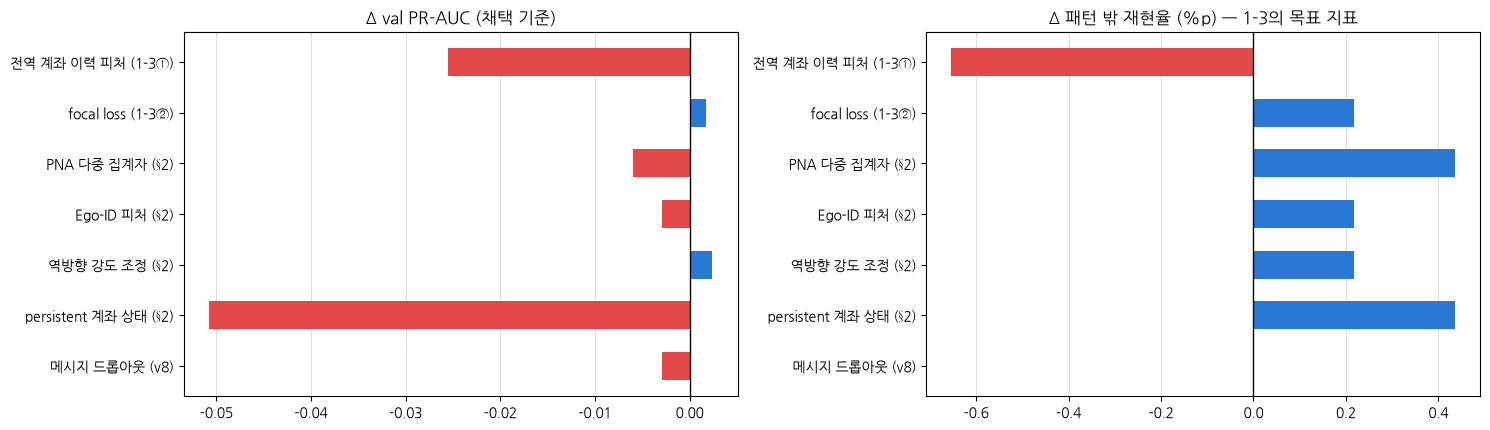


해석: Δval > 0 이면 채택 근거가 유지되는 장치, Δ패턴밖 > 0 이면 요청사항 1-3 의 목표를
      실제로 달성한 장치입니다. 둘의 부호가 엇갈리면 §20 에 그대로 기록합니다.


In [30]:
V9_LOO_ROWS = []
V9_DEVICES = [
    ("전역 계좌 이력 피처 (1-3①)", "GLOBAL_ACCT", False),
    ("focal loss (1-3②)",         "LOSS",        "bce"),
    ("PNA 다중 집계자 (§2)",       "AGGRS",       "sum"),
    ("Ego-ID 피처 (§2)",          "EGO",         False),
    ("역방향 강도 조정 (§2)",       "REV_W",       1.0),
    ("persistent 계좌 상태 (§2)",   "PERSIST",     0),
    ("메시지 드롭아웃 (v8)",        "MSG_DROPOUT", 0.0),
]

if RUN_V9_LOO:
    if HP_BEST_RUN is not None:
        _on_v, _on_t = HP_BEST_RUN["val_prob"], HP_BEST_RUN["test_prob"]
    else:
        print("최종 구성(ON) 학습 중...", flush=True)
        _r0 = train_one_seed(42, cfg=FINAL_CFG, verbose=False)
        _on_v, _on_t = _r0["val_prob"], _r0["test_prob"]; del _r0
    _on = eval_full(_on_v, _on_t, "v9 최종(전체 ON)")
    print(f"기준(전체 ON): val={_on['val PR-AUC']:.4f} test={_on['test PR-AUC']:.4f} "
          f"패턴내/밖={scen_get(_on,'패턴내 R@예산'):.1f}/{scen_get(_on,'패턴밖 R@예산'):.1f}%\n")

    _sweep_by_cfg = {cfg_key(r["_cfg"]): r for r in HP_SWEEP_ROWS} if HP_SWEEP_ROWS else {}

    def _axis_pair(key, off_val):
        '''스윕에서 **그 축 하나만 다른** (ON 행, OFF 행) 짝을 찾는다.

        [v9 수정] 예전에는 "장치를 켠 행 중 val 최대" vs "최종 구성"을 비교했는데, 두 구성은
        최대 8개 축이 동시에 다르고(교란) 최종 구성이 스윕 전체의 argmax 라 Δval 이 구조적으로
        항상 ≤ 0 이 되어 아무 정보가 없었습니다. 여기서는 시행 행의 `_base`(그 시행이 1축만
        바꾼 원본 구성)를 이용해 교란 없는 짝만 인용합니다.
        '''
        best_pair = None
        for r in HP_SWEEP_ROWS:
            b = _sweep_by_cfg.get(r.get("_base")) if r.get("_base") else None
            if b is None:
                continue
            rv, bv = r["_cfg"].get(key), b["_cfg"].get(key)
            if rv == bv:
                continue                       # 이 축이 바뀐 시행이 아님
            on_r, off_r = (r, b) if rv != off_val else (b, r)
            if off_r["_cfg"].get(key) != off_val:
                continue                       # OFF 쪽이 진짜 OFF 값이어야 함
            if best_pair is None or on_r["_val"] > best_pair[0]["_val"]:
                best_pair = (on_r, off_r)
        return best_pair

    for _label, _key, _off_val in V9_DEVICES:
        _adopted = FINAL_CFG.get(_key) != _off_val
        if not _adopted:
            # 미채택 — 스윕에서 이 축만 다른 1축 짝을 인용 (재학습 없음)
            _pair = _axis_pair(_key, _off_val)
            if _pair:
                _bon, _boff = _pair
                V9_LOO_ROWS.append({
                    "장치": _label, "채택": "❌ 미채택",
                    "근거": f"§10-3 스윕 1축 짝({_bon['축'] or _boff['축']})",
                    "val ON": _bon["val PR-AUC"], "val OFF": _boff["val PR-AUC"],
                    "Δval(ON-OFF)": _bon["val PR-AUC"] - _boff["val PR-AUC"],
                    "test ON": _bon["test PR-AUC"], "test OFF": _boff["test PR-AUC"],
                    "패턴밖 ON": _bon.get("패턴밖 R@예산", float("nan")),
                    "패턴밖 OFF": _boff.get("패턴밖 R@예산", float("nan")),
                    "Δ패턴밖": (_bon.get("패턴밖 R@예산", float("nan"))
                             - _boff.get("패턴밖 R@예산", float("nan")))})
                print(f"  {_label:<26s} 미채택 — 1축 짝 인용 "
                      f"(ON {_bon['val PR-AUC']:.4f} vs OFF {_boff['val PR-AUC']:.4f}, 재학습 생략)",
                      flush=True)
            else:
                V9_LOO_ROWS.append({"장치": _label, "채택": "❌ 미채택",
                                    "근거": "스윕에 1축 짝 기록 없음"})
                print(f"  {_label:<26s} 미채택 — 인용할 1축 짝이 없어 수치 생략", flush=True)
            continue

        _t0 = time.time()
        _off_cfg = dict(FINAL_CFG); _off_cfg[_key] = _off_val
        _r = train_one_seed(42, cfg=_off_cfg, verbose=False)
        _off = eval_full(_r["val_prob"], _r["test_prob"], f"OFF: {_label}")
        del _r
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        V9_LOO_ROWS.append({
            "장치": _label, "채택": "✅ 채택", "근거": f"LOO 재학습({_key}={_off_val})",
            "val ON": _on["val PR-AUC"], "val OFF": _off["val PR-AUC"],
            "Δval(ON-OFF)": _on["val PR-AUC"] - _off["val PR-AUC"],
            "test ON": _on["test PR-AUC"], "test OFF": _off["test PR-AUC"],
            "패턴밖 ON": scen_get(_on, "패턴밖 R@예산"), "패턴밖 OFF": scen_get(_off, "패턴밖 R@예산"),
            "Δ패턴밖": scen_get(_on, "패턴밖 R@예산") - scen_get(_off, "패턴밖 R@예산")})
        print(f"  {_label:<26s} ON {_on['val PR-AUC']:.4f} vs OFF {_off['val PR-AUC']:.4f} "
              f"(Δval {_on['val PR-AUC']-_off['val PR-AUC']:+.4f}, "
              f"Δ패턴밖 {scen_get(_on,'패턴밖 R@예산')-scen_get(_off,'패턴밖 R@예산'):+.1f}%p)  "
              f"{(time.time()-_t0)/60:.1f}분", flush=True)

    LOO_DF = pd.DataFrame(V9_LOO_ROWS)
    print("\n── v9 신규 장치 ON/OFF 비교표 (시드 42 동일 프로토콜) ──")
    print(LOO_DF.round(4).to_string(index=False))

    _plot = LOO_DF.dropna(subset=["Δ패턴밖"]) if "Δ패턴밖" in LOO_DF else LOO_DF.iloc[0:0]
    if len(_plot):
        fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
        for ax, col, ttl in [(axes[0], "Δval(ON-OFF)", "Δ val PR-AUC (채택 기준)"),
                             (axes[1], "Δ패턴밖", "Δ 패턴 밖 재현율 (%p) — 1-3의 목표 지표")]:
            v = _plot[col].to_numpy(dtype=float)
            colors = ["#2a78d6" if x > 0 else "#e34948" for x in v]
            ax.barh(_plot["장치"][::-1], v[::-1], color=colors[::-1], height=0.55)
            ax.axvline(0, color="k", lw=1)
            ax.set_title(ttl); ax.grid(axis="x", lw=0.6, alpha=0.5); ax.set_axisbelow(True)
        plt.tight_layout(); plt.show()
    print("\n해석: Δval > 0 이면 채택 근거가 유지되는 장치, Δ패턴밖 > 0 이면 요청사항 1-3 의 목표를")
    print("      실제로 달성한 장치입니다. 둘의 부호가 엇갈리면 §20 에 그대로 기록합니다.")
else:
    LOO_DF = None
    print("RUN_V9_LOO = False — LOO ablation 생략.")

## 14. [v9 전면 개편 · 요청사항 1-2] GBT 대조군 정상화

**v8에서 무엇이 잘못됐나.** GBT의 `class_weight` 를 **GNN 스윕이 고른 `POS_WEIGHT_CAP` 에 그대로 종속**시켰습니다.
v6은 cap=15 로 GBT test PR-AUC **0.5022**, v8은 GNN 스윕이 cap=5 를 고르면서 GBT도 5를 물려받아 **0.2837 로 붕괴**.
그 결과 "그래프 구조의 순수 기여분"이 **+0.3119** 로 부풀려져 신뢰할 수 없는 수치가 됐습니다.

**v9의 처리**

1. **완전 분리** — `GBT_POS_WEIGHT` 는 `POS_WEIGHT_CAP` 과 무관한 독립 변수이고, **GBT 자체 스윕**으로 고릅니다.
2. **피처 동등성 검증** — GBT 입력 = GNN `EDGE_FEATURES` 와 **완전히 동일**함을 코드로 확인하고,
   GNN만 추가로 보는 입력(방향 플래그·포트 번호·노드 피처)을 명시합니다.
3. **하이퍼파라미터도 기본값 방치 금지** — 학습률·잎 수·L2·반복수를 val PR-AUC 기준 탐욕 스윕.
4. **기여분 2단 분해** — 계좌 전역 이력 피처는 "그래프 메시지 전달"이 아니라 "계좌 집계 피처"입니다.
   그래서 **GBT-B(+계좌 전역 이력)** 대조군을 추가해 기여분을 *계좌 집계* 와 *메시지 전달/구조* 로 나눕니다.


In [31]:
from sklearn.ensemble import HistGradientBoostingClassifier

# ── 14-1. 피처 동등성 검증 (요청사항 1-2 ②) ────────────────────────────
GBT_FEATURES = list(EDGE_FEATURES)
assert GBT_FEATURES == EDGE_FEATURES, "GBT 입력이 GNN 엣지 피처와 다릅니다 — 공정 비교 불가"
_only_gnn = ([f"방향 플래그 ×2"] + ([f"포트 번호·다중도 ×2"] if USE_PORTS else [])
             + [f"노드(계좌) 피처 ×{node_dim_total()}"] + ["이웃 메시지 전달(그래프 구조)"])
print("── §14-1 피처 동등성 검증 ──")
print(f"GBT 입력 : EDGE_FEATURES {len(GBT_FEATURES)}개 "
      f"(기본 {len(BASE_FEATURES)} + 시간차 {len(TIME_FEATURES)}) — 그래프 구조 피처 없음")
print(f"GNN 입력 : 동일한 {len(EDGE_FEATURES)}개 + 아래 항목")
for _o in _only_gnn:
    print(f"           └ {_o}")
print(f"→ 두 모델의 성능 차이 = 위 '추가 항목'의 기여분입니다. "
      f"{'계좌 전역 이력이 노드 피처에 포함되므로' if USE_GLOBAL_ACCT_FEATS else ''}"
      f"{' §14-3 에서 GBT-B 로 계좌 집계분을 분리합니다.' if USE_GLOBAL_ACCT_FEATS else ''}")
print(f"\n[분리 확인] GNN POS_WEIGHT_CAP = {POS_WEIGHT_CAP:g} / "
      f"GBT_POS_WEIGHT = {GBT_POS_WEIGHT:g} (독립 변수 — 아래 스윕이 val 기준으로 갱신)")


── §14-1 피처 동등성 검증 ──
GBT 입력 : EDGE_FEATURES 64개 (기본 48 + 시간차 16) — 그래프 구조 피처 없음
GNN 입력 : 동일한 64개 + 아래 항목
           └ 방향 플래그 ×2
           └ 포트 번호·다중도 ×2
           └ 노드(계좌) 피처 ×9
           └ 이웃 메시지 전달(그래프 구조)
→ 두 모델의 성능 차이 = 위 '추가 항목'의 기여분입니다. 

[분리 확인] GNN POS_WEIGHT_CAP = 5 / GBT_POS_WEIGHT = 15 (독립 변수 — 아래 스윕이 val 기준으로 갱신)


── GBT-A 독립 탐욕 스윕 (선택 기준 = val PR-AUC, test 미사용) ──
  [기준      ] w=15    lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5800  (1.4분)
  [weight  ] w=1     lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5680  (1.5분)
  [weight  ] w=5     lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5269  (1.5분)
  [weight  ] w=30    lr=0.1   leaf=63   l2=1     → best_iter=100  val PR-AUC=0.5913  (1.5분)
  [weight  ] w=50    lr=0.1   leaf=63   l2=1     → best_iter=100  val PR-AUC=0.5954  (1.4분)
  ── weight 확정: 50.0
  ── lr 확정: 0.1
  ── leaf 확정: 63
  ── l2 확정: 1.0

>>> GBT-A 최종: weight=50, lr=0.1, leaf=63, l2=1, max_iter=100 (val PR-AUC 0.5954)

GBT-A 최종 적합 44s
  test PR-AUC=0.5355  F1@0.5=23.29%  패턴내/밖=82.5/3.1%

── GBT-A 스윕 전체 결과 ──
     축  weight  learning_rate  max_leaf_nodes  l2_regularization  max_iter  val PR-AUC  적합(분)
    기준    15.0            0.1              63                1.0       200      0.5800    1.4
weight     1.0            0.1              63           

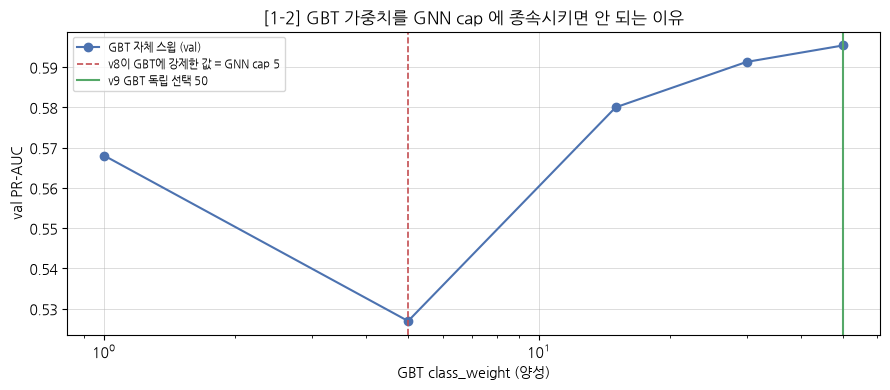

In [32]:
# ── 14-2. GBT 독립 탐욕 스윕 (요청사항 1-2 ①·③) ───────────────────────
def gbt_chain(X_tr, y_tr, X_va, y_va, params, weight, iters, log=True):
    '''warm_start 로 max_iter 를 늘려가며 한 체인에서 반복수 축까지 함께 평가.
    반환: [(max_iter, val_ap), ...]'''
    mdl = HistGradientBoostingClassifier(**params, class_weight={0: 1.0, 1: float(weight)},
                                         warm_start=True, early_stopping=False,
                                         random_state=42, max_iter=int(iters[0]))
    out = []
    for it in iters:
        mdl.set_params(max_iter=int(it))
        mdl.fit(X_tr, y_tr)
        ap = float(average_precision_score(y_va, mdl.predict_proba(X_va)[:, 1]))
        out.append((int(it), ap))
    del mdl
    return out


def gbt_sweep(X, y_int, tag="GBT-A", w_grid=None, lr_grid=None, leaf_grid=None, l2_grid=None,
              start=None, w_start=None):
    '''val PR-AUC 기준 탐욕 스윕 — 가중치 → 학습률 → 잎 수 → L2 (반복수는 각 체인에서 동시 평가).'''
    w_grid = GBT_W_GRID if w_grid is None else w_grid
    lr_grid = GBT_LR_GRID if lr_grid is None else lr_grid
    leaf_grid = GBT_LEAF_GRID if leaf_grid is None else leaf_grid
    l2_grid = GBT_L2_GRID if l2_grid is None else l2_grid
    Xtr, ytr = X[:n_tr], y_int[:n_tr]
    Xva, yva = X[n_tr:n_va], y_int[n_tr:n_va]

    cur = dict(start) if start else dict(learning_rate=0.1, max_leaf_nodes=63, l2_regularization=1.0)
    cur_w = float(w_start if w_start is not None else w_grid[len(w_grid) // 2])
    rows, best, seen = [], None, {}

    def _run(params, w, axis):
        nonlocal best
        ck = (round(float(w), 6), params["learning_rate"], params["max_leaf_nodes"],
              params["l2_regularization"])
        if ck in seen:                       # 같은 설정 재적합 방지 (적합 1회가 수 분)
            return seen[ck]
        t0 = time.time()
        path = gbt_chain(Xtr, ytr, Xva, yva, params, w, GBT_ITER_PATH)
        it, ap = max(path, key=lambda z: z[1])
        rec = {"축": axis, "weight": w, **params, "max_iter": it, "val PR-AUC": ap,
               "적합(분)": round((time.time() - t0) / 60, 1),
               "_path": path}
        rows.append(rec); seen[ck] = rec
        if best is None or ap > best["val PR-AUC"]:
            best = rec
        print(f"  [{axis:<8s}] w={w:<5g} lr={params['learning_rate']:<5g} "
              f"leaf={params['max_leaf_nodes']:<4d} l2={params['l2_regularization']:<5g} "
              f"→ best_iter={it:<4d} val PR-AUC={ap:.4f}  ({rec['적합(분)']}분)", flush=True)
        return rec

    print(f"── {tag} 독립 탐욕 스윕 (선택 기준 = val PR-AUC, test 미사용) ──")
    _run(dict(cur), cur_w, "기준")
    for axis, grid, key in [("weight", w_grid, None),
                            ("lr", lr_grid, "learning_rate"),
                            ("leaf", leaf_grid, "max_leaf_nodes"),
                            ("l2", l2_grid, "l2_regularization")]:
        for v in grid:
            if (key is None and v == cur_w) or (key is not None and v == cur[key]):
                continue
            p = dict(cur); w = cur_w
            if key is None:
                w = float(v)
            else:
                p[key] = v
            r = _run(p, w, axis)
            if r is best:
                cur, cur_w = p, w
        print(f"  ── {axis} 확정: {cur_w if key is None else cur[key]}", flush=True)

    print(f"\n>>> {tag} 최종: weight={best['weight']:g}, lr={best['learning_rate']:g}, "
          f"leaf={best['max_leaf_nodes']}, l2={best['l2_regularization']:g}, "
          f"max_iter={best['max_iter']} (val PR-AUC {best['val PR-AUC']:.4f})")
    return best, rows


def gbt_fit_final(X, y_int, best):
    '''선택된 설정으로 최종 적합 → (val 확률, test 확률, 적합 초).'''
    t0 = time.time()
    mdl = HistGradientBoostingClassifier(
        learning_rate=best["learning_rate"], max_leaf_nodes=best["max_leaf_nodes"],
        l2_regularization=best["l2_regularization"], max_iter=best["max_iter"],
        class_weight={0: 1.0, 1: float(best["weight"])},
        early_stopping=False, random_state=42)
    mdl.fit(X[:n_tr], y_int[:n_tr])
    return (mdl.predict_proba(X[n_tr:n_va])[:, 1], mdl.predict_proba(X[n_va:])[:, 1],
            time.time() - t0, mdl)


y_int = Y.astype(int)
X_A = EF                                  # GNN 과 완전히 동일한 엣지 피처
GBT_SWEEP_ROWS_A, GBT_BEST_A = [], None
if RUN_GBT_SWEEP:
    GBT_BEST_A, GBT_SWEEP_ROWS_A = gbt_sweep(X_A, y_int, "GBT-A")
    GBT_POS_WEIGHT = float(GBT_BEST_A["weight"])
else:
    GBT_BEST_A = {"weight": GBT_POS_WEIGHT, "learning_rate": 0.1, "max_leaf_nodes": 63,
                  "l2_regularization": 1.0, "max_iter": 500, "val PR-AUC": float("nan")}
    print(f"RUN_GBT_SWEEP = False — 스윕 생략 (weight={GBT_POS_WEIGHT:g}, 기본 하이퍼파라미터).")

gbt_v, gbt_t, _gbt_sec, GBT_MODEL_A = gbt_fit_final(X_A, y_int, GBT_BEST_A)
print(f"\nGBT-A 최종 적합 {_gbt_sec:.0f}s")
row_gbt = eval_full(gbt_v, gbt_t, "GBT-A (거래 피처만, 독립 스윕)")
print(f"  test PR-AUC={row_gbt['test PR-AUC']:.4f}  F1@0.5={row_gbt['F1@0.5']:.2f}%  "
      f"패턴내/밖={scen_get(row_gbt,'패턴내 R@예산'):.1f}/{scen_get(row_gbt,'패턴밖 R@예산'):.1f}%")

if RUN_GBT_SWEEP and GBT_SWEEP_ROWS_A:
    _sw = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                        for r in GBT_SWEEP_ROWS_A])
    print("\n── GBT-A 스윕 전체 결과 ──")
    print(_sw.round(4).to_string(index=False))
    fig, ax = plt.subplots(figsize=(9, 4))
    _wr = _sw[_sw["축"].isin(["기준", "weight"])].sort_values("weight")
    ax.plot(_wr["weight"], _wr["val PR-AUC"], "o-", color="#4C72B0", label="GBT 자체 스윕 (val)")
    ax.axvline(POS_WEIGHT_CAP, color="#C44E52", ls="--", lw=1.2,
               label=f"v8이 GBT에 강제한 값 = GNN cap {POS_WEIGHT_CAP:g}")
    ax.axvline(GBT_POS_WEIGHT, color="#55A868", ls="-", lw=1.5,
               label=f"v9 GBT 독립 선택 {GBT_POS_WEIGHT:g}")
    ax.set_xscale("log"); ax.set_xlabel("GBT class_weight (양성)"); ax.set_ylabel("val PR-AUC")
    ax.set_title("[1-2] GBT 가중치를 GNN cap 에 종속시키면 안 되는 이유"); ax.legend(fontsize=8)
    ax.grid(lw=0.6, alpha=0.5); plt.tight_layout(); plt.show()


In [33]:
# ── 14-3. GBT-B(+계좌 전역 이력) + 그래프 순수 기여분 재계산 (요청사항 1-2 ④) ──
row_gbt_b, GBT_BEST_B = None, None
if RUN_GBT_B:
    print(f"GBT-B 입력 구성 중 — EDGE_FEATURES {len(EDGE_FEATURES)} + "
          f"계좌 전역 이력 (송신 {GACC_DIM} + 수신 {GACC_DIM}) = {len(EDGE_FEATURES)+2*GACC_DIM}차원")
    X_B = np.concatenate([EF, GACC[SRC], GACC[DST]], axis=1).astype(np.float32)
    print(f"  메모리 {X_B.nbytes/1e9:.2f} GB")
    # A에서 고른 나머지 하이퍼파라미터를 재사용하고 가중치 축만 다시 확인 (비용 절감 — 아래에 명시)
    _startB = {k: GBT_BEST_A[k] for k in ("learning_rate", "max_leaf_nodes", "l2_regularization")}
    GBT_BEST_B, _rows_b = gbt_sweep(X_B, y_int, "GBT-B", start=_startB,
                                    w_start=GBT_BEST_A["weight"],
                                    lr_grid=[_startB["learning_rate"]],
                                    leaf_grid=[_startB["max_leaf_nodes"]],
                                    l2_grid=[_startB["l2_regularization"]])
    gbt_bv, gbt_bt, _sec_b, _ = gbt_fit_final(X_B, y_int, GBT_BEST_B)
    row_gbt_b = eval_full(gbt_bv, gbt_bt, "GBT-B (+계좌 전역 이력)")
    print(f"\nGBT-B 최종 적합 {_sec_b:.0f}s → test PR-AUC={row_gbt_b['test PR-AUC']:.4f}  "
          f"패턴내/밖={scen_get(row_gbt_b,'패턴내 R@예산'):.1f}/{scen_get(row_gbt_b,'패턴밖 R@예산'):.1f}%")
    print("  (비용 절감: B는 A가 고른 lr/leaf/l2 를 재사용하고 class_weight 축만 다시 스윕했습니다.)")
    del X_B

# ── 비교표 ──
ROW_ENS_FULL = eval_full(ens_v, ens_t, f"GNN 앙상블({len(runs)}시드)")
_seed_rows = [eval_full(r["val_prob"], r["test_prob"], f"seed{r['seed']}") for r in runs]
_seed_df = pd.DataFrame(_seed_rows)
_single = {"모델": "GNN 단일 평균"}
for _k in ROW_ENS_FULL:
    if _k != "모델" and _k in _seed_df.columns:
        _single[_k] = float(_seed_df[_k].mean())

_tbl = [row_gbt] + ([row_gbt_b] if row_gbt_b is not None else []) + [_single, ROW_ENS_FULL]
comp = pd.DataFrame(_tbl)[["모델", "val PR-AUC", "test PR-AUC", "F1@0.5", "P@F1튜닝", "R@F1튜닝",
                           "F1@F1튜닝", "F1@예산0.1%"] + SCEN_COLS]
print("\n── §14 대조군 비교 (동일 분할·동일 지표) ──")
print(comp.round(4).to_string(index=False))

CONTRIB_A = float(row_ens["test PR-AUC"] - row_gbt["test PR-AUC"])
CONTRIB_B = (float(row_ens["test PR-AUC"] - row_gbt_b["test PR-AUC"])
             if row_gbt_b is not None else None)
print(f"\n■ 그래프+계좌맥락 전체 기여분 (GNN − GBT-A) = {CONTRIB_A:+.4f}")
if CONTRIB_B is not None:
    print(f"■ 메시지 전달·구조 피처의 순수 기여분 (GNN − GBT-B) = {CONTRIB_B:+.4f}")
    print(f"■ 계좌 전역 이력(집계 피처)의 기여분 = {CONTRIB_A - CONTRIB_B:+.4f}")

# ── v6 / v8 / v9 기여분 정직성 비교 (요청사항 1-2 ④) ──
CONTRIB_TABLE = pd.DataFrame([
    {"버전": "v6", "GBT class_weight": "15 (= 당시 GNN cap)", "결정 방식": "GNN cap 에 종속",
     "GBT test PR-AUC": 0.5022, "GNN 앙상블 test PR-AUC": 0.5742, "그래프 기여분": 0.0720,
     "신뢰도": "우연히 합리적 — cap 15 가 GBT에도 나쁘지 않았을 뿐"},
    {"버전": "v8", "GBT class_weight": "5 (= 당시 GNN cap)", "결정 방식": "GNN cap 에 종속",
     "GBT test PR-AUC": 0.2837, "GNN 앙상블 test PR-AUC": 0.5956, "그래프 기여분": 0.3119,
     "신뢰도": "❌ 신뢰 불가 — GBT가 붕괴한 만큼 기여분이 부풀려짐"},
    {"버전": "v9", "GBT class_weight": f"{GBT_POS_WEIGHT:g} (독립 스윕)",
     "결정 방식": "GBT 자체 val PR-AUC 스윕",
     "GBT test PR-AUC": round(float(row_gbt["test PR-AUC"]), 4),
     "GNN 앙상블 test PR-AUC": round(float(row_ens["test PR-AUC"]), 4),
     "그래프 기여분": round(CONTRIB_A, 4),
     "신뢰도": "✅ 대조군이 자기 최적점에서 경쟁 — 이 값이 가장 정직"},
])
print("\n── [1-2 ④] 그래프 순수 기여분의 버전별 비교 ──")
print(CONTRIB_TABLE.to_string(index=False))
print("\n판정: v8의 +0.3119 는 **GBT를 불리한 가중치로 묶어 만든 수치**이므로 채택하지 않습니다.")
print(f"      v9의 {CONTRIB_A:+.4f} 가 '두 모델이 각자 최적점에서 경쟁한' 정직한 값입니다.")
if CONTRIB_B is not None:
    print(f"      계좌 집계 피처를 대조군에도 준 GBT-B 기준으로는 {CONTRIB_B:+.4f} 이며, "
          f"이것이 '메시지 전달' 자체의 기여분에 가장 가깝습니다.")


GBT-B 입력 구성 중 — EDGE_FEATURES 64 + 계좌 전역 이력 (송신 8 + 수신 8) = 80차원
  메모리 1.62 GB
── GBT-B 독립 탐욕 스윕 (선택 기준 = val PR-AUC, test 미사용) ──
  [기준      ] w=50    lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5801  (1.9분)
  [weight  ] w=1     lr=0.1   leaf=63   l2=1     → best_iter=100  val PR-AUC=0.5509  (2.0분)
  [weight  ] w=5     lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5205  (1.9분)
  [weight  ] w=15    lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.5605  (1.9분)
  [weight  ] w=30    lr=0.1   leaf=63   l2=1     → best_iter=200  val PR-AUC=0.6000  (2.0분)
  ── weight 확정: 30.0
  ── lr 확정: 0.1
  ── leaf 확정: 63
  ── l2 확정: 1.0

>>> GBT-B 최종: weight=30, lr=0.1, leaf=63, l2=1, max_iter=200 (val PR-AUC 0.6000)

GBT-B 최종 적합 113s → test PR-AUC=0.5181  패턴내/밖=78.8/3.5%
  (비용 절감: B는 A가 고른 lr/leaf/l2 를 재사용하고 class_weight 축만 다시 스윕했습니다.)

── §14 대조군 비교 (동일 분할·동일 지표) ──
                   모델  val PR-AUC  test PR-AUC  F1@0.5  P@F1튜닝  R@F1튜닝  F1@F1튜닝  F1@예산0.1%  패턴내 R@예산  패

### 14-4. [v9 신규 · 1-3 ③] 하이브리드 스코어링 — 그래프 신호가 약한 곳을 비그래프 신호로 보완

패턴 밖 세탁은 **로컬 그래프 신호가 약한 것이 원인**이므로(§8-4 진단), 그래프에 의존하지 않는 보조 점수를
결합해 보완합니다. 두 종류를 모두 시험합니다.

| 보조 모델 | 성격 | 근거 |
|---|---|---|
| **Isolation Forest** | 비지도 이상치 — 금액/시간 등 거래 자체의 이상도 | 라벨 없이도 "튀는 거래"를 잡음 |
| **GBT-A** | 지도 학습, **비그래프 피처만** | §14의 대조군을 그대로 보조 신호로 재활용 |

* 결합은 **순위 평균**: `score = (1-w)·rank(GNN) + w·rank(보조)` — 척도가 다른 두 점수를 안전하게 섞습니다
* `w` 는 **val PR-AUC로만** 선택하며 **`w=0`(순수 GNN)도 후보**입니다 → 이득이 없으면 자동으로 기각됩니다
* 각 `w` 에 대해 **패턴 밖 재현율**을 함께 표기해, 전체 지표가 아니라 **목표 지표가 실제로 올랐는지** 확인합니다


Isolation Forest: train 200,000행 적합 + 채점 (10s), 단독 val PR-AUC=0.0018 (test=0.0019)

── 하이브리드 결합 가중치 스윕 (선택 기준 = val PR-AUC) ──
                   조합    w  val PR-AUC  test PR-AUC  F1@예산0.1%  패턴내 R@예산  패턴밖 R@예산  시나리오 재현율%
GNN + IsolationForest 0.00      0.6385       0.5876    57.9898   89.9123    2.3965    94.5355
GNN + IsolationForest 0.05      0.2233       0.2227    27.8833   41.3743    3.9216    65.5738
GNN + IsolationForest 0.10      0.0622       0.1299    22.1399   32.0175    4.3573    57.3770
GNN + IsolationForest 0.20      0.0111       0.0261     5.4655    8.0409    0.8715    19.1257
GNN + IsolationForest 0.30      0.0067       0.0105     2.1306    2.9240    0.6536     9.2896
GNN + IsolationForest 0.50      0.0042       0.0047     0.6481    0.4386    0.8715     1.6393
    GNN + GBT-A(비그래프) 0.00      0.6385       0.5876    57.9898   89.9123    2.3965    94.5355
    GNN + GBT-A(비그래프) 0.05      0.6438       0.5968    58.8235   90.9357    2.8322    92.3497
    GNN + GBT-A(비그래프) 0.10 

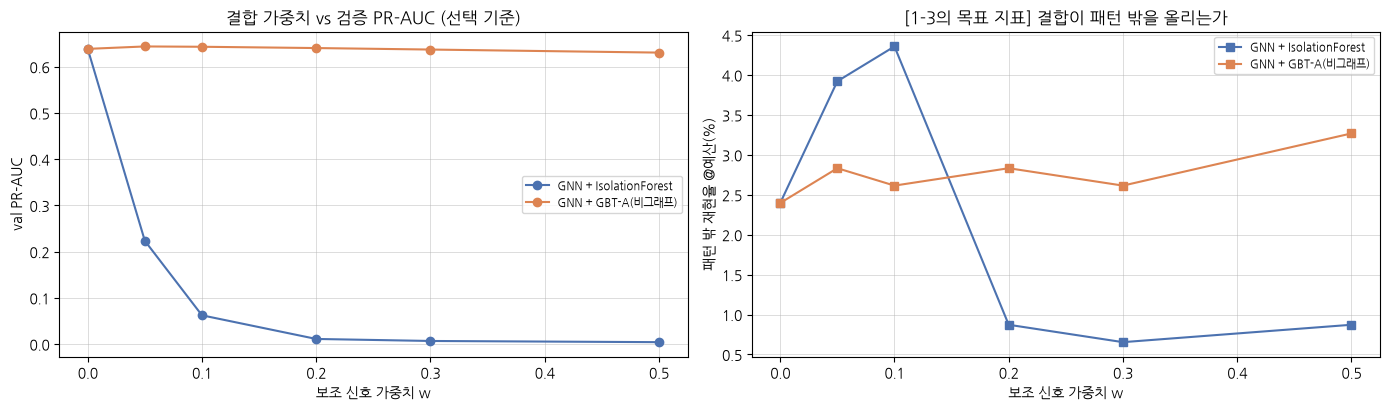

In [34]:
HYBRID_RESULT = None
if RUN_HYBRID:
    from sklearn.ensemble import IsolationForest

    def rank01(a):
        return pd.Series(a).rank(pct=True, method="average").to_numpy()

    # ── 보조 ①: Isolation Forest (비지도, 비그래프) ──
    _t0 = time.time()
    _rs = np.random.RandomState(42)
    _idx = _rs.choice(n_tr, size=min(IFOREST_FIT_ROWS, n_tr), replace=False)
    iso = IsolationForest(n_estimators=100, max_samples=256, random_state=42, n_jobs=-1)
    iso.fit(EF[_idx])
    iso_v = -iso.score_samples(EF[n_tr:n_va])      # 클수록 이상
    iso_t = -iso.score_samples(EF[n_va:])
    print(f"Isolation Forest: train {len(_idx):,}행 적합 + 채점 ({time.time()-_t0:.0f}s), "
          f"단독 val PR-AUC={average_precision_score(val_y, iso_v):.4f} "
          f"(test={average_precision_score(test_y, iso_t):.4f})")

    _aux = [("GNN + IsolationForest", iso_v, iso_t),
            ("GNN + GBT-A(비그래프)", gbt_v, gbt_t)]
    _rg_v, _rg_t = rank01(ens_v), rank01(ens_t)

    HY_ROWS = []
    for _nm, _av, _at in _aux:
        _ra_v, _ra_t = rank01(_av), rank01(_at)
        for _w in HYBRID_W_GRID:
            _cv = (1 - _w) * _rg_v + _w * _ra_v
            _ct = (1 - _w) * _rg_t + _w * _ra_t
            _r = eval_full(_cv, _ct, f"{_nm} w={_w:g}")
            HY_ROWS.append({"조합": _nm, "w": _w, **{k: v for k, v in _r.items() if k != "모델"}})
    HY = pd.DataFrame(HY_ROWS)

    print("\n── 하이브리드 결합 가중치 스윕 (선택 기준 = val PR-AUC) ──")
    print(HY[["조합", "w", "val PR-AUC", "test PR-AUC", "F1@예산0.1%"] + SCEN_COLS]
          .round(4).to_string(index=False))

    _best = HY.loc[HY["val PR-AUC"].idxmax()]
    _pure = HY[(HY["w"] == 0)].iloc[0]
    print(f"\n>>> val 기준 최적: {_best['조합']} w={_best['w']:g} "
          f"(val {_best['val PR-AUC']:.4f} vs 순수 GNN {_pure['val PR-AUC']:.4f}, "
          f"Δ{_best['val PR-AUC']-_pure['val PR-AUC']:+.4f})")
    if _best["w"] == 0:
        print("    → 보조 신호가 val 기준 이득을 주지 못했습니다. **하이브리드 미채택**(순수 GNN 유지).")
    else:
        print(f"    → 채택. test PR-AUC {_pure['test PR-AUC']:.4f} → {_best['test PR-AUC']:.4f}, "
              f"패턴 밖 재현율 {scen_get(_pure,'패턴밖 R@예산'):.1f}% → {scen_get(_best,'패턴밖 R@예산'):.1f}% "
              f"({scen_get(_best,'패턴밖 R@예산')-scen_get(_pure,'패턴밖 R@예산'):+.1f}%p)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    for _nm, _c in zip(HY["조합"].unique(), ["#4C72B0", "#DD8452"]):
        _s = HY[HY["조합"] == _nm]
        axes[0].plot(_s["w"], _s["val PR-AUC"], "o-", color=_c, label=_nm)
        axes[1].plot(_s["w"], _s["패턴밖 R@예산"], "s-", color=_c, label=_nm)
    axes[0].set_xlabel("보조 신호 가중치 w"); axes[0].set_ylabel("val PR-AUC")
    axes[0].set_title("결합 가중치 vs 검증 PR-AUC (선택 기준)"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("보조 신호 가중치 w"); axes[1].set_ylabel("패턴 밖 재현율 @예산(%)")
    axes[1].set_title("[1-3의 목표 지표] 결합이 패턴 밖을 올리는가"); axes[1].legend(fontsize=8)
    for a in axes:
        a.grid(lw=0.6, alpha=0.5); a.set_axisbelow(True)
    plt.tight_layout(); plt.show()

    HYBRID_RESULT = {"rows": HY.drop(columns=[c for c in HY.columns if c.startswith("thr_")]
                                     ).to_dict("records"),
                     "best": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                              for k, v in _best.items()},
                     "adopted": bool(_best["w"] > 0),
                     "iso_val_ap": float(average_precision_score(val_y, iso_v)),
                     "iso_test_ap": float(average_precision_score(test_y, iso_t))}
else:
    print("RUN_HYBRID = False — 하이브리드 스코어링 생략.")


## 15. 세트 간 비교 + zero-shot 전이 평가 (화두 7)

**HI-Small로 학습한 앙상블을 그대로** 타 세트에 적용해 채점합니다 — 재학습 없이 얼마나 버티는지가
일반화의 가장 엄격한 척도입니다.

* 피처 파이프라인은 동일하게 적용하되 **범주 어휘(pf/pc/rc)는 학습 세트 것**을 사용해 입력 차원 일치
* **[v9]** 전역 계좌 이력 피처도 **타깃 세트의 train 구간에서 자체 산출**합니다(운영에서 신규 기관 데이터에
  자체 통계를 적용하는 것과 동일 조건 — 라벨은 사용하지 않음)
* **[v9]** persistent account state 는 계좌 id 체계가 다르므로 전이 채점에서 **자동 비활성화**합니다
* 세트마다 유병률이 달라 PR-AUC 절대값 비교는 불공정 → **lift = PR-AUC ÷ 유병률** 병기

> 파일이 없으면 자동 스킵되고 §20 「여전히 남은 것」에 미해결로 기록됩니다.


In [35]:
CANDIDATE_SETS = ["HI-Small", "LI-Small", "HI-Medium", "LI-Medium"]
available, missing = [], []
for ds in CANDIDATE_SETS:
    p = Path("IBM_AML_dataset") / f"{ds}_Trans.csv"
    in_zip = zf is not None and any(nm.endswith(f"{ds}_Trans.csv") for nm in zf.namelist())
    (available if (p.exists() or in_zip) else missing).append(ds)
print("사용 가능:", available)
print("없음     :", missing, "→ 해당 세트는 스킵합니다.")

ens_models = [r["model"] for r in runs]


def prepare_bundle(ds):
    '''타 세트를 본학습과 동일 파이프라인으로 정제·피처화해 번들로 반환 (zero-shot 채점용).'''
    raw = load_transactions(ds)
    d2, _meta = clean_frame(raw, verbose=False)
    m = len(d2)
    m_tr, m_va = int(m * TRAIN_FRAC), int(m * (TRAIN_FRAC + VAL_FRAC))
    d2["order_idx"] = np.arange(m, dtype=np.int64)
    is_tr2 = np.zeros(m, bool); is_tr2[:m_tr] = True

    sk = d2["From Bank"].astype(str) + "_" + d2["Account"].astype(str)
    dk = d2["To Bank"].astype(str) + "_" + d2["Account.1"].astype(str)
    codes2, uniq2 = pd.factorize(pd.concat([sk, dk], ignore_index=True))
    d2["src_id"] = codes2[:m].astype(np.int64)
    d2["dst_id"] = codes2[m:].astype(np.int64)
    d2["self_loop"] = (d2["src_id"] == d2["dst_id"]).astype(np.float32)

    d2, base2, _ = add_base_features(d2, is_tr2, cats=(PF_CATS, PC_CATS, RC_CATS))
    d2, tf2 = add_time_features(d2)
    feats2 = base2 + tf2
    assert feats2 == EDGE_FEATURES, "피처 이름/순서가 학습 세트와 다릅니다 — 전이 평가 불가"

    B = dict(SRC=d2["src_id"].to_numpy(), DST=d2["dst_id"].to_numpy(),
             Y=d2["Is Laundering"].to_numpy().astype(np.float32),
             EF=np.ascontiguousarray(d2[feats2].to_numpy(dtype=np.float32)),
             AP=d2["amt_paid_z"].to_numpy(), AR=d2["amt_recv_z"].to_numpy(),
             n=m, n_tr=m_tr, n_va=m_va, cache={}, cache_sig=None, ef_tag="full")
    if USE_GLOBAL_ACCT_FEATS:
        ts2 = d2["Timestamp"].to_numpy().astype("datetime64[s]").astype(np.int64)
        day2 = ((ts2 - ts2.min()) // 86400).astype(np.int64)
        B["GACC"] = build_global_acct_feats(B["SRC"], B["DST"], B["AP"], B["AR"],
                                            day2, m_tr, len(uniq2))
    return B


@torch.no_grad()
def predict_bundle(models, wins, B):
    '''앙상블 평균 확률 — 번들 윈도우를 캐시 없이 1회 순회 (메모리 절약).'''
    amp_on = USE_AMP and DEVICE.type == "cuda"
    amp_dt = AMP_DTYPE if amp_on else torch.float32
    ps = []
    for w in wins:
        g = to_dev(build_window(*w, D=B))
        g.pop("nodes", None)          # [v9] 계좌 id 체계가 달라 persistent state 비활성화
        outs = []
        for mdl in models:
            mdl.eval()
            with torch.autocast("cuda", amp_dt, enabled=amp_on):
                el, _ = mdl(g)
            outs.append(torch.sigmoid(el.float()).cpu().numpy())
        ps.append(np.mean(outs, axis=0))
        del g
    return np.concatenate(ps)


_prev_in = float(test_y.mean())
TRANSFER_ROWS = [{"세트": DATASET, "평가": "in-set (학습 세트)", "거래 수": int(n),
                  "세탁 유병률(%)": round(_prev_in * 100, 4),
                  "test PR-AUC": round(float(row_ens["test PR-AUC"]), 4),
                  "lift(=AP/유병률)": round(float(row_ens["test PR-AUC"]) / max(_prev_in, 1e-9), 1),
                  "F1@F1튜닝": round(float(row_ens["F1@F1튜닝"]), 2),
                  "F1@예산0.1%": round(float(row_ens["F1@예산0.1%"]), 2)}]
TRANSFER_SKIPPED = []

if RUN_TRANSFER:
    targets = [s for s in TRANSFER_SETS if s in available and s != DATASET]
    TRANSFER_SKIPPED = [s for s in TRANSFER_SETS if s not in available]
    if TRANSFER_SKIPPED:
        print(f"\n스킵(파일 없음): {TRANSFER_SKIPPED}")
    for ds in targets:
        print(f"\n===== {ds} zero-shot 전이 평가 =====", flush=True)
        try:
            _t0 = time.time()
            B = prepare_bundle(ds)
            vw = window_ranges(B["n_tr"], B["n_va"])
            tw = window_ranges(B["n_va"], B["n"])
            vp = predict_bundle(ens_models, vw, B)
            tp = predict_bundle(ens_models, tw, B)
            vy2, ty2 = B["Y"][B["n_tr"]:B["n_va"]], B["Y"][B["n_va"]:]
            row = evaluate(vp, tp, ds, vy=vy2, ty=ty2)
            prev2 = float(ty2.mean())
            TRANSFER_ROWS.append({"세트": ds, "평가": "zero-shot (HI-Small 학습 앙상블)",
                                  "거래 수": int(B["n"]), "세탁 유병률(%)": round(prev2 * 100, 4),
                                  "test PR-AUC": round(float(row["test PR-AUC"]), 4),
                                  "lift(=AP/유병률)": round(float(row["test PR-AUC"]) / max(prev2, 1e-9), 1),
                                  "F1@F1튜닝": round(float(row["F1@F1튜닝"]), 2),
                                  "F1@예산0.1%": round(float(row["F1@예산0.1%"]), 2)})
            print(f"  test PR-AUC={row['test PR-AUC']:.4f} (유병률 {prev2*100:.4f}%), "
                  f"F1@튜닝={row['F1@F1튜닝']:.2f}%  ({(time.time()-_t0)/60:.1f}분)")
            del B, vp, tp
        except FileNotFoundError as e:
            print(f"  스킵: {e}"); TRANSFER_SKIPPED.append(ds)
        except MemoryError:
            print(f"  스킵: 메모리 부족 — {ds}"); TRANSFER_SKIPPED.append(ds)

cross = pd.DataFrame(TRANSFER_ROWS)
print("\n── 세트 간 비교표 (화두 7) ──")
print(cross.to_string(index=False))
if len(cross) > 1:
    _zs = cross[cross["평가"].str.startswith("zero")]
    if len(_zs):
        _keep = _zs["lift(=AP/유병률)"].max() / max(cross.iloc[0]["lift(=AP/유병률)"], 1e-9)
        print(f"\nzero-shot lift 유지율(최고 세트 기준): {_keep*100:.1f}% — "
              "높을수록 학습 세트 특이 패턴이 아닌 일반 신호를 학습했다는 뜻입니다.")
else:
    print("\n타 세트 파일이 없어 in-set 1행만 표시됩니다 → §20 「여전히 남은 것」에 미해결로 기록됩니다.")


사용 가능: ['HI-Small']
없음     : ['LI-Small', 'HI-Medium', 'LI-Medium'] → 해당 세트는 스킵합니다.

스킵(파일 없음): ['LI-Small']

── 세트 간 비교표 (화두 7) ──
      세트             평가    거래 수  세탁 유병률(%)  test PR-AUC  lift(=AP/유병률)  F1@F1튜닝  F1@예산0.1%
HI-Small in-set (학습 세트) 5077228     0.1126       0.5876          522.0    62.77      57.99

타 세트 파일이 없어 in-set 1행만 표시됩니다 → §20 「여전히 남은 것」에 미해결로 기록됩니다.


## 16. 드리프트 모니터링 — 검증→테스트 하락폭의 운영 지표화

| 지표 | 임계값 | 운영 조치 |
|---|---|---|
| **PR-AUC 상대 하락** | 주의 ≥ 10%, 경보 ≥ 20% | 주의: 원인 분석 / 경보: 재학습 + 임계값 재캘리브레이션 |
| **점수 분포 PSI** (val→test) | 주의 ≥ 0.10, 경보 ≥ 0.25 | 라벨 없이 먼저 울리는 조기 경보 |
| **경보율 안정성** | 예산의 0.5~2배 이탈 시 주의 | 예산(분위수) 기반 임계값 운영 근거 |
| **윈도우별 롤링 PR-AUC** | 추세 감시 | 하락이 국소적인지 전역적인지 구분 |


── val→test PR-AUC 하락 (주의 ≥ 10%, 경보 ≥ 20%) ──
    모델  val PR-AUC  test PR-AUC     하락  상대 하락(%)   상태
seed 0      0.6382       0.5891 0.0491    7.6974 🟢 정상
seed 1      0.6347       0.5803 0.0543    8.5596 🟢 정상
   앙상블      0.6385       0.5876 0.0509    7.9762 🟢 정상

점수 분포 PSI (val→test) = 0.0097  [🟢 정상]
경보율 안정성: 검증 임계값 0.4452 고정 시 테스트 경보율 0.1113% (예산의 1.11배) [🟢 정상]


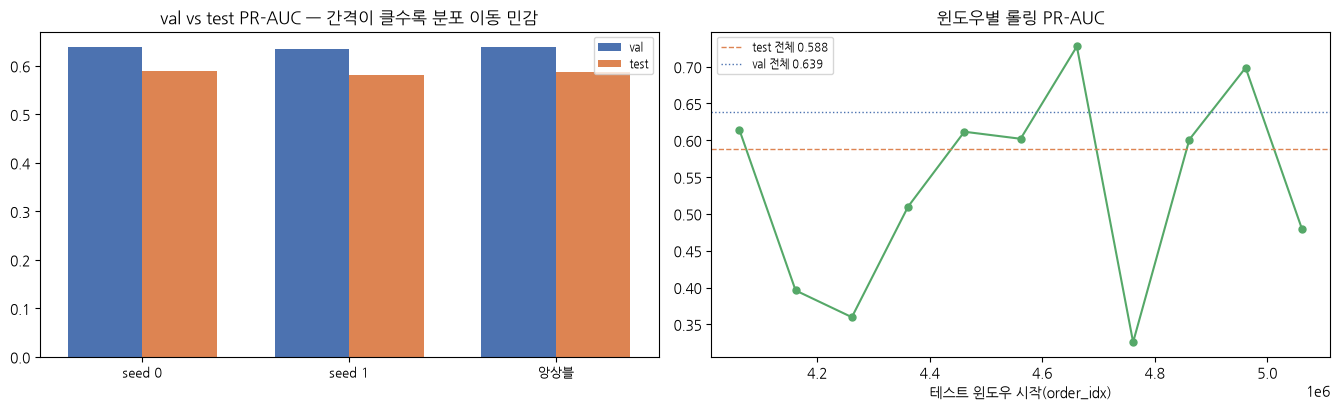


종합 판정: 앙상블 상대 하락 8.0% [🟢 정상], PSI [🟢 정상], 경보율 [🟢 정상]
권장 조치: 정상 — 정기 모니터링 유지


In [36]:
def psi(expected, actual, bins=10):
    '''Population Stability Index — expected(기준) 분위 구간에 대한 actual 분포 이동량.'''
    qs = np.quantile(expected, np.linspace(0, 1, bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    e = np.histogram(expected, qs)[0] / max(len(expected), 1)
    a = np.histogram(actual, qs)[0] / max(len(actual), 1)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))


def drift_status(rel_drop):
    if rel_drop >= DRIFT_ALERT: return "🔴 경보"
    if rel_drop >= DRIFT_WARN:  return "🟡 주의"
    return "🟢 정상"


drift_rows = []
for r in runs:
    va_ = average_precision_score(val_y, r["val_prob"])
    te_ = average_precision_score(test_y, r["test_prob"])
    rel = (va_ - te_) / max(va_, 1e-9)
    drift_rows.append({"모델": f"seed {r['seed']}", "val PR-AUC": va_, "test PR-AUC": te_,
                       "하락": va_ - te_, "상대 하락(%)": rel * 100, "상태": drift_status(rel)})
_va = average_precision_score(val_y, ens_v)
_te = average_precision_score(test_y, ens_t)
_rel_ens = (_va - _te) / max(_va, 1e-9)
drift_rows.append({"모델": "앙상블", "val PR-AUC": _va, "test PR-AUC": _te,
                   "하락": _va - _te, "상대 하락(%)": _rel_ens * 100, "상태": drift_status(_rel_ens)})
drift_df = pd.DataFrame(drift_rows)
print("── val→test PR-AUC 하락 (주의 ≥ {:.0f}%, 경보 ≥ {:.0f}%) ──".format(DRIFT_WARN*100, DRIFT_ALERT*100))
print(drift_df.round(4).to_string(index=False))

score_psi = psi(ens_v, ens_t)
psi_status = "🔴 경보" if score_psi >= PSI_ALERT else ("🟡 주의" if score_psi >= PSI_WARN else "🟢 정상")
print(f"\n점수 분포 PSI (val→test) = {score_psi:.4f}  [{psi_status}]")

thr_val_budget = float(np.quantile(ens_v, 1 - ALERT_BUDGET))
realized = float((ens_t >= thr_val_budget).mean())
ratio = realized / ALERT_BUDGET
rate_status = "🟢 정상" if 0.5 <= ratio <= 2.0 else "🟡 주의"
print(f"경보율 안정성: 검증 임계값 {thr_val_budget:.4f} 고정 시 테스트 경보율 "
      f"{realized*100:.4f}% (예산의 {ratio:.2f}배) [{rate_status}]")

roll = []
for (c_, lo_, hi_) in TEST_W:
    yw = Y[lo_:hi_]
    pw_ = ens_t[lo_ - n_va:hi_ - n_va]
    if yw.sum() >= 5:
        roll.append({"윈도우 시작": lo_, "양성 수": int(yw.sum()),
                     "PR-AUC": average_precision_score(yw, pw_)})
roll_df = pd.DataFrame(roll)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
xs = np.arange(len(drift_df))
axes[0].bar(xs - 0.18, drift_df["val PR-AUC"], width=0.36, color="#4C72B0", label="val")
axes[0].bar(xs + 0.18, drift_df["test PR-AUC"], width=0.36, color="#DD8452", label="test")
axes[0].set_xticks(xs); axes[0].set_xticklabels(drift_df["모델"], fontsize=9)
axes[0].set_title("val vs test PR-AUC — 간격이 클수록 분포 이동 민감"); axes[0].legend(fontsize=8)
if len(roll_df):
    axes[1].plot(roll_df["윈도우 시작"], roll_df["PR-AUC"], "o-", color="#55A868", ms=5)
    axes[1].axhline(_te, color="#DD8452", ls="--", lw=1, label=f"test 전체 {_te:.3f}")
    axes[1].axhline(_va, color="#4C72B0", ls=":", lw=1, label=f"val 전체 {_va:.3f}")
    axes[1].set_xlabel("테스트 윈도우 시작(order_idx)"); axes[1].set_title("윈도우별 롤링 PR-AUC")
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, "양성 5건 이상 윈도우 없음", ha="center")
plt.tight_layout(); plt.show()

DRIFT_REPORT = {
    "metric": "val_to_test_pr_auc_drop",
    "thresholds": {"warn": DRIFT_WARN, "alert": DRIFT_ALERT,
                   "psi_warn": PSI_WARN, "psi_alert": PSI_ALERT},
    "ensemble": {"val_pr_auc": _va, "test_pr_auc": _te, "rel_drop": _rel_ens,
                 "status": drift_status(_rel_ens)},
    "per_seed": [{k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                  for k, v in row.items()} for row in drift_rows[:-1]],
    "score_psi": score_psi, "psi_status": psi_status,
    "alert_rate": {"budget": ALERT_BUDGET, "realized_at_val_thr": realized, "ratio": ratio,
                   "status": rate_status},
    "rolling_pr_auc": roll_df.to_dict("records") if len(roll_df) else [],
    "recommendation": ("재학습 트리거 + 임계값 재캘리브레이션" if _rel_ens >= DRIFT_ALERT else
                       "원인 분석 착수 (피처 드리프트 분해)" if _rel_ens >= DRIFT_WARN else
                       "정상 — 정기 모니터링 유지"),
}
print(f"\n종합 판정: 앙상블 상대 하락 {_rel_ens*100:.1f}% [{drift_status(_rel_ens)}], "
      f"PSI [{psi_status}], 경보율 [{rate_status}]")
print(f"권장 조치: {DRIFT_REPORT['recommendation']}")


## 17. 케이스 조사 지원 → STR 초안 (화두 4)

고위험 거래 Top-K 추출 → 주변 계좌 관계 서브그래프 → 조사노트 JSON → STR(의심거래보고) 초안.
**[v9]** 조사노트에 **패턴 내/밖 여부**와 **계좌 전역 이력 요약**을 추가해 조사관이
"이 건이 정형 패턴의 일부인가, 고립 건인가"를 바로 알 수 있게 했습니다.


In [37]:
TOP_K = 4
os.makedirs("case_notes", exist_ok=True)

_ord = np.argsort(-ens_t)[:TOP_K]
CASE_NOTES = []
for _rank, _li in enumerate(_ord, start=1):
    gi = int(_li + n_va)
    row = df.iloc[gi]
    s_id, d_id = int(row["src_id"]), int(row["dst_id"])
    note = {
        "case_id": f"CASE-{DATASET}-{_rank:03d}",
        "risk_score": round(float(ens_t[_li]), 6),
        "rank": _rank,
        "transaction": {
            "timestamp": str(row["Timestamp"]), "from_bank": str(row["From Bank"]),
            "from_account": str(row["Account"]), "to_bank": str(row["To Bank"]),
            "to_account": str(row["Account.1"]),
            "amount_paid": float(row["Amount Paid"]), "payment_currency": str(row["Payment Currency"]),
            "amount_received": float(row["Amount Received"]),
            "receiving_currency": str(row["Receiving Currency"]),
            "payment_format": str(row["Payment Format"]),
        },
        "label_for_reference": int(row["Is Laundering"]),
        "in_known_pattern": bool(PAT_MASK[gi]),          # [v9]
        "counterparty_history": {                          # [v9] 계좌 전역 이력 요약
            "sender":   {nm: round(float(GACC[s_id, j]), 4) for j, nm in enumerate(GACC_NAMES)},
            "receiver": {nm: round(float(GACC[d_id, j]), 4) for j, nm in enumerate(GACC_NAMES)},
        },
        "alert_threshold": {"budget": ALERT_BUDGET, "value": round(float(row_ens["thr_예산"]), 6)},
        "model": {"version": "v9", "config": cfg_label(FINAL_CFG),
                  "ensemble_seeds": [int(r["seed"]) for r in runs]},
    }
    # 주변 서브그래프 (같은 계좌가 관여한 테스트 구간 거래)
    nb = df.iloc[n_va:]
    rel = nb[(nb["src_id"].isin([s_id, d_id])) | (nb["dst_id"].isin([s_id, d_id]))]
    note["neighborhood"] = {
        "n_related_tx": int(len(rel)),
        "n_counterparties": int(pd.concat([rel["src_id"], rel["dst_id"]]).nunique()),
        "related_high_risk": int((ens_t[rel["order_idx"].to_numpy() - n_va]
                                  >= float(row_ens["thr_예산"])).sum()),
    }
    CASE_NOTES.append(note)
    with open(f"case_notes/{note['case_id']}.json", "w", encoding="utf-8") as fp:
        json.dump(note, fp, ensure_ascii=False, indent=2)

print(f"조사노트 {len(CASE_NOTES)}건 저장 → ./case_notes/")
for _nt in CASE_NOTES:
    print(f"  {_nt['case_id']} 위험도 {_nt['risk_score']:.4f} / "
          f"패턴 내={_nt['in_known_pattern']} / 관련 거래 {_nt['neighborhood']['n_related_tx']}건 / "
          f"참고 라벨={_nt['label_for_reference']}")


조사노트 4건 저장 → ./case_notes/
  CASE-HI-Small-001 위험도 0.9733 / 패턴 내=True / 관련 거래 40건 / 참고 라벨=1
  CASE-HI-Small-002 위험도 0.9722 / 패턴 내=True / 관련 거래 25건 / 참고 라벨=1
  CASE-HI-Small-003 위험도 0.9705 / 패턴 내=True / 관련 거래 13건 / 참고 라벨=1
  CASE-HI-Small-004 위험도 0.9689 / 패턴 내=True / 관련 거래 29건 / 참고 라벨=1


In [38]:
def make_str_draft(note: dict) -> str:
    '''조사노트 JSON -> STR(의심거래보고) 초안 마크다운. 규칙 기반, 사람 검토 필수.'''
    t = note["transaction"]; nb = note["neighborhood"]
    sender, receiver = note["counterparty_history"]["sender"], note["counterparty_history"]["receiver"]
    reasons = []
    if t["payment_currency"] != t["receiving_currency"]:
        reasons.append("송금/수취 통화가 달라 크로스커런시 이전 정황이 있음")
    if nb["n_counterparties"] >= 5:
        reasons.append(f"관련 계좌가 {nb['n_counterparties']}개로 다수 상대방과 연결(팬인/팬아웃 가능성)")
    if nb["related_high_risk"] >= 2:
        reasons.append(f"동일 계좌 관련 고위험 거래가 {nb['related_high_risk']}건으로 반복 관찰")
    if note["in_known_pattern"]:
        reasons.append("알려진 정형 세탁 패턴 블록에 속한 거래")
    else:
        reasons.append("정형 패턴 밖의 고립 거래 — 계좌 이력 기반 신호로 적발(v9 전역 계좌 피처)")
    if sender.get("g_seen", 0) == 0:
        reasons.append("송신 계좌가 학습 구간에 이력이 없는 신규/저활동 계좌")
    elif sender.get("g_burst", 0) > sender.get("g_out_cnt", 0):
        reasons.append("송신 계좌에서 특정일 거래 폭주가 관찰됨")
    if not reasons:
        reasons.append("모델 위험도 상위 구간에 해당")

    L = []
    L.append(f"# 의심거래보고(STR) 초안 — {note['case_id']}")
    L.append("")
    L.append("> ⚠️ 본 문서는 **모델이 생성한 초안**입니다. 보고 전 반드시 준법감시인 검토·확정이 필요합니다.")
    L.append("")
    L.append("## 1. 거래 개요")
    L.append("| 항목 | 내용 |")
    L.append("|---|---|")
    L.append(f"| 거래일시 | {t['timestamp']} |")
    L.append(f"| 송금 | {t['from_bank']} / {t['from_account']} |")
    L.append(f"| 수취 | {t['to_bank']} / {t['to_account']} |")
    L.append(f"| 금액 | {t['amount_paid']:,.2f} {t['payment_currency']} -> "
             f"{t['amount_received']:,.2f} {t['receiving_currency']} |")
    L.append(f"| 지급수단 | {t['payment_format']} |")
    L.append("")
    L.append("## 2. 탐지 근거")
    L.append(f"* 모델 위험도 **{note['risk_score']:.4f}** "
             f"(경보 예산 {note['alert_threshold']['budget']*100:.1f}% "
             f"임계값 {note['alert_threshold']['value']:.4f} 초과)")
    L.append(f"* 정형 패턴 소속 여부: **{'예' if note['in_known_pattern'] else '아니오(고립 건)'}**")
    L.append(f"* 관련 거래 {nb['n_related_tx']}건 / 관련 계좌 {nb['n_counterparties']}개 / "
             f"그중 고위험 {nb['related_high_risk']}건")
    L.append("")
    L.append("## 3. 의심 사유")
    for i, r in enumerate(reasons, 1):
        L.append(f"{i}. {r}")
    L.append("")
    L.append("## 4. 계좌 이력 요약 (학습 구간 기준)")
    L.append("| 지표 | 송신 계좌 | 수취 계좌 |")
    L.append("|---|---|---|")
    for k in GACC_NAMES:
        L.append(f"| {k} | {sender[k]} | {receiver[k]} |")
    L.append("")
    L.append("## 5. 조치 의견")
    L.append("- [ ] 계좌 모니터링 강화   - [ ] 추가 자료 요청   "
             "- [ ] STR 정식 보고   - [ ] 종결(정상 판단)")
    L.append("")
    L.append(f"*생성 모델: {note['model']['version']} / {note['model']['config']} / "
             f"시드 {note['model']['ensemble_seeds']}*")
    return chr(10).join(L)


for _nt in CASE_NOTES:
    with open(f"case_notes/{_nt['case_id']}_STR.md", "w", encoding="utf-8") as fp:
        fp.write(make_str_draft(_nt))
print(f"STR 초안 {len(CASE_NOTES)}건 저장 -> ./case_notes/*_STR.md")
print()
print(make_str_draft(CASE_NOTES[0])[:1600])


STR 초안 4건 저장 -> ./case_notes/*_STR.md

# 의심거래보고(STR) 초안 — CASE-HI-Small-001

> ⚠️ 본 문서는 **모델이 생성한 초안**입니다. 보고 전 반드시 준법감시인 검토·확정이 필요합니다.

## 1. 거래 개요
| 항목 | 내용 |
|---|---|
| 거래일시 | 2022-09-08 18:01:00 |
| 송금 | 02591 / 800AEAC00 |
| 수취 | 01665 / 8006A4A30 |
| 금액 | 172,117.87 US Dollar -> 172,117.87 US Dollar |
| 지급수단 | ACH |

## 2. 탐지 근거
* 모델 위험도 **0.9733** (경보 예산 0.1% 임계값 0.4778 초과)
* 정형 패턴 소속 여부: **예**
* 관련 거래 40건 / 관련 계좌 17개 / 그중 고위험 6건

## 3. 의심 사유
1. 관련 계좌가 17개로 다수 상대방과 연결(팬인/팬아웃 가능성)
2. 동일 계좌 관련 고위험 거래가 6건으로 반복 관찰
3. 알려진 정형 세탁 패턴 블록에 속한 거래
4. 송신 계좌에서 특정일 거래 폭주가 관찰됨

## 4. 계좌 이력 요약 (학습 구간 기준)
| 지표 | 송신 계좌 | 수취 계좌 |
|---|---|---|
| g_out_cnt | 0.4114 | 1.0896 |
| g_in_cnt | 0.7242 | 0.7087 |
| g_amt_mean | -0.2173 | -0.3787 |
| g_amt_std | 0.6271 | 0.6513 |
| g_peers | 0.458 | 0.6557 |
| g_days | 0.7186 | 0.7186 |
| g_burst | 0.5886 | 0.9014 |
| g_seen | 1.0 | 1.0 |

## 5. 조치 의견
- [ ] 계좌 모니터링 강화   - [ ] 추가 자료 요청   - [ ] STR 정식 보고   - [ ] 종결(정상 판단)

*생성 모델: v9 / h256/L2/aux0.6/md0.1/g

## 18. 분 단위 배치 추론 데모 + [v9] 앙상블 개수별 지연

학습 윈도우와 동일한 구조(과거 `CONTEXT_EDGES` 건 + 대상 구간)로 채점합니다 — 학습·서빙 그래프 정합 유지.
§12-4 의 이득/비용 표에 **여기서 측정한 실제 지연**을 채워 넣습니다.


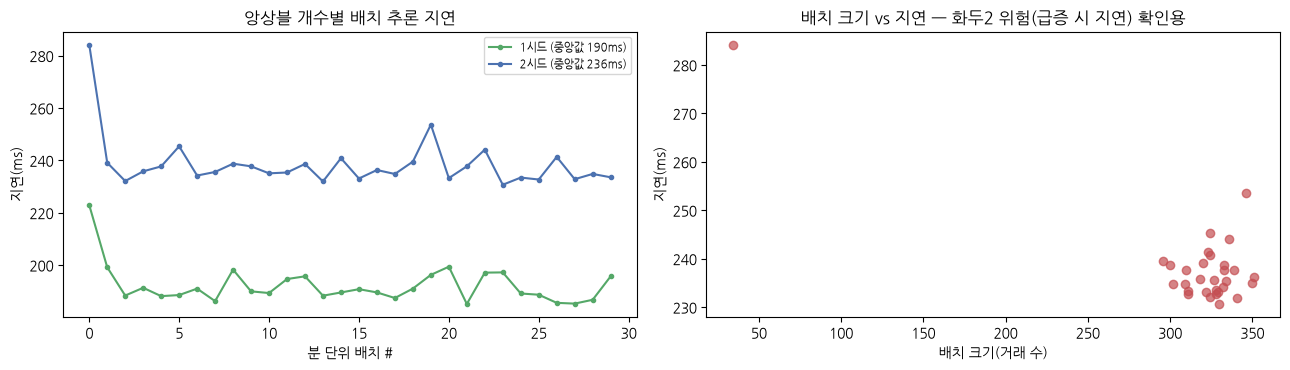

── [§12-4 완성] 앙상블 개수별 이득 / 비용 ──
 앙상블 개수  val PR-AUC  test PR-AUC  F1@F1튜닝  F1@예산0.1%  패턴밖 R@예산  파라미터 합  Δ test PR-AUC(직전 대비)  지연(ms, 중앙값)  지연 배수(vs 단일)
      1      0.6382       0.5891  62.8821    57.7510    2.1786 1039876                   NaN     189.7271          1.00
      2      0.6385       0.5876  62.7682    57.9898    2.3965 2079752               -0.0015     235.6488          1.24

판정: 2시드 앙상블은 단일 대비 test PR-AUC -0.0015 를 얻는 대가로 지연 1.2배·파라미터 2배를 씁니다.
      SLA가 빠듯하면 §12 표의 '단일 평균' 성능으로 판단하고 단일 모델 운영을 권장합니다.


In [39]:
@torch.no_grad()
def score_batch(batch_end_gi, batch_size, models=None):
    models = models or ens_models
    lo = batch_end_gi + 1 - batch_size
    g = to_dev(build_window(max(0, lo - CONTEXT_EDGES), lo, batch_end_gi + 1))
    amp_on = USE_AMP and DEVICE.type == "cuda"
    ps = []
    for mdl in models:
        mdl.eval()
        with torch.autocast("cuda", AMP_DTYPE if amp_on else torch.float32, enabled=amp_on):
            el, _ = mdl(g)
        ps.append(torch.sigmoid(el.float()).cpu().numpy())
    return np.mean(ps, axis=0)


test_df = df.iloc[n_va:]
minute_groups = list(test_df.groupby(test_df["Timestamp"].dt.floor("min"), sort=True))
N_DEMO = min(30, len(minute_groups))

LAT = {k: [] for k in range(1, len(ens_models) + 1)}
sizes = []
for i, (minute, g_) in enumerate(minute_groups[:N_DEMO]):
    end_gi = int(g_["order_idx"].iloc[-1])
    sizes.append(len(g_))
    for k in LAT:
        t = time.perf_counter()
        score_batch(end_gi, len(g_), ens_models[:k])
        LAT[k].append((time.perf_counter() - t) * 1000)

_med = {k: float(np.median(v)) for k, v in LAT.items()}
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for k, c in zip(sorted(LAT), ["#55A868", "#4C72B0", "#DD8452", "#C44E52", "#8172B2", "#937860"]):
    axes[0].plot(LAT[k], "o-", ms=3, color=c, label=f"{k}시드 (중앙값 {_med[k]:.0f}ms)")
axes[0].set_xlabel("분 단위 배치 #"); axes[0].set_ylabel("지연(ms)"); axes[0].legend(fontsize=8)
axes[0].set_title("앙상블 개수별 배치 추론 지연")
axes[1].scatter(sizes, LAT[max(LAT)], color="#C44E52", alpha=0.7)
axes[1].set_xlabel("배치 크기(거래 수)"); axes[1].set_ylabel("지연(ms)")
axes[1].set_title("배치 크기 vs 지연 — 화두2 위험(급증 시 지연) 확인용")
plt.tight_layout(); plt.show()

# §12-4 표에 실제 지연 채우기
ENS_COST["지연(ms, 중앙값)"] = [_med.get(k, np.nan) for k in ENS_COST["앙상블 개수"]]
ENS_COST["지연 배수(vs 단일)"] = (ENS_COST["지연(ms, 중앙값)"] / _med[1]).round(2)
ENS_COST = ENS_COST.drop(columns=["지연(ms, §18에서 채움)"], errors="ignore")
print("── [§12-4 완성] 앙상블 개수별 이득 / 비용 ──")
print(ENS_COST.round(4).to_string(index=False))
_d_ap = ENS_COST["test PR-AUC"].iloc[-1] - ENS_COST["test PR-AUC"].iloc[0]
_d_lat = ENS_COST["지연 배수(vs 단일)"].iloc[-1]
print(f"\n판정: {len(runs)}시드 앙상블은 단일 대비 test PR-AUC {_d_ap:+.4f} 를 얻는 대가로 "
      f"지연 {_d_lat:.1f}배·파라미터 {len(runs)}배를 씁니다.")
print("      SLA가 빠듯하면 §12 표의 '단일 평균' 성능으로 판단하고 단일 모델 운영을 권장합니다.")


## 19. 모델·설정·리포트 저장 (배포/재현용)


In [40]:
os.makedirs("artifacts_v9", exist_ok=True)
for r in runs:
    # [v9] acct_state 는 persistent=False 버퍼라 state_dict 에 없습니다 →
    #   재현 가능하도록 best 에폭 스냅샷을 함께 저장합니다(없으면 None).
    torch.save({"state_dict": r["state"], "acct_state": r.get("acct_state"),
                "config": FINAL_CFG, "version": "v9"},
               f"artifacts_v9/{DATASET}_edge_gine_seed{r['seed']}.pt")
print("체크포인트 형식: {'state_dict', 'acct_state', 'config', 'version'} — "
      "로드 시 acct_state 를 model.acct_state 에 복사해야 persistent state 성능이 재현됩니다.")

def _num(o):
    if isinstance(o, (np.floating, np.integer)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(str(type(o)))

_cfg_json = {
    "version": "v9-root-cause+benchmark", "dataset": DATASET, "seeds": SEED_LIST,
    "final_config": FINAL_CFG, "config_label": cfg_label(FINAL_CFG),
    "edge_features": EDGE_FEATURES, "time_features": TIME_FEATURES,
    "global_acct_features": GACC_NAMES,
    "node_dim": node_dim_total(), "edge_dim": EDGE_DIM, "edge_extra": EDGE_EXTRA,
    "hidden": HIDDEN, "layers": N_LAYERS, "dropout": DROPOUT,
    "loss": {"type": LOSS_TYPE, "focal_gamma": FOCAL_GAMMA, "pos_weight_cap": POS_WEIGHT_CAP},
    "aggregators": list(PNA_AGGRS), "rev_edge_w": REV_EDGE_W,
    "persist": {"dim": PERSIST_DIM, "alpha": PERSIST_ALPHA},
    "use_global_acct_feats": bool(USE_GLOBAL_ACCT_FEATS), "use_ego_id": bool(USE_EGO_ID),
    "window_size": WINDOW_SIZE, "context_edges": CONTEXT_EDGES,
    "amp": {"enabled": bool(USE_AMP), "dtype": str(AMP_DTYPE).split(".")[-1],
            "agg_clamp": bool(AGG_CLAMP), "clamp_frac": AGG_CLAMP_FRAC,
            "diag": AMP_DIAG, "ab": AMP_AB_RESULT},
    "pos_cap_sweep": [{k: v for k, v in r_.items() if not str(k).startswith("_")}
                      for r_ in POS_SWEEP_ROWS],
    "hp_sweep": [{k: v for k, v in r_.items() if not str(k).startswith("_")}
                 for r_ in HP_SWEEP_ROWS],
    "v9_loo_ablation": V9_LOO_ROWS,
    "ablation_ladder": ABLATION,
    "gbt": {"pos_weight": GBT_POS_WEIGHT,
            "best_A": {k: v for k, v in GBT_BEST_A.items() if not str(k).startswith("_")},
            "best_B": ({k: v for k, v in GBT_BEST_B.items() if not str(k).startswith("_")}
                       if GBT_BEST_B else None),
            "test_pr_auc_A": float(row_gbt["test PR-AUC"]),
            "test_pr_auc_B": (float(row_gbt_b["test PR-AUC"]) if row_gbt_b is not None else None),
            "graph_contribution_vs_A": CONTRIB_A, "graph_contribution_vs_B": CONTRIB_B},
    "hybrid": HYBRID_RESULT,
    "scenario_eval": SCENARIO_RESULT,
    "account_level_eval": ACCT_RESULT,
    "time_feature_ab": TIME_AB_RESULT,
    "transfer_eval": TRANSFER_ROWS, "transfer_skipped": TRANSFER_SKIPPED,
    "ensemble_cost": ENS_COST.to_dict("records"),
    "alert_budget": ALERT_BUDGET,
    "threshold_f1": float(row_ens["thr_F1"]), "threshold_budget": float(row_ens["thr_예산"]),
    "val_pr_auc_per_seed": [r["val_ap"] for r in runs],
    "test_pr_auc_ensemble": float(row_ens["test PR-AUC"]),
    "test_pr_auc_single_mean": float(res["test PR-AUC"].mean()),
    "test_pr_auc_single_std": float(res["test PR-AUC"].std(ddof=1)),
    "pf_cats": PF_CATS, "pc_cats": PC_CATS, "rc_cats": RC_CATS,
    "tail_min_frac": TAIL_MIN_FRAC,
    "main_period": [str(main_start.date()), str(main_end.date())],
}
with open(f"artifacts_v9/{DATASET}_config.json", "w", encoding="utf-8") as fp:
    json.dump(_cfg_json, fp, ensure_ascii=False, indent=2, default=_num)
with open(f"artifacts_v9/{DATASET}_drift_report.json", "w", encoding="utf-8") as fp:
    json.dump(DRIFT_REPORT, fp, ensure_ascii=False, indent=2, default=_num)
res.to_csv(f"artifacts_v9/{DATASET}_seed_results.csv", index=False)
if LOO_DF is not None:
    LOO_DF.to_csv(f"artifacts_v9/{DATASET}_v9_ablation.csv", index=False)
print("저장 완료 → ./artifacts_v9/  (config / drift_report / seed_results / v9_ablation / 모델)")


체크포인트 형식: {'state_dict', 'acct_state', 'config', 'version'} — 로드 시 acct_state 를 model.acct_state 에 복사해야 persistent state 성능이 재현됩니다.
저장 완료 → ./artifacts_v9/  (config / drift_report / seed_results / v9_ablation / 모델)


## 20. 결론 — v6 vs v8 vs v9 전체 비교 · ablation 요약 · 여전히 남은 것

아래 표의 **v6·v8 값은 각 노트북의 실제 실행 기록**이고, **v9 값은 이번 실행에서 계산된 값**입니다.


In [41]:
# ── v6 / v8 실행 기록 (하드코딩 = 과거 노트북의 실측 출력) ───────────────
V6_REC = {
    "버전": "v6 (일반화 강화판)", "구성": "h128/L3, 4시드",
    "test PR-AUC": 0.5742, "F1@0.5": 47.60, "F1@F1튜닝": 60.85, "F1@예산0.1%": 57.62,
    "패턴 내 R@예산": None, "패턴 밖 R@예산": None, "시나리오 재현율%": None,
    "GBT test PR-AUC": 0.5022, "GBT 가중치 결정": "GNN cap(15)에 종속",
    "그래프 기여분": 0.0720, "파라미터(단일)": 356740, "지연 배수(앙상블/단일)": 1.3,
}
V8_REC = {
    "버전": "v8 (일반화 강화 2차)", "구성": "h256/L2/aux0.6/md0.1, 4시드",
    "test PR-AUC": 0.5956, "F1@0.5": 61.71, "F1@F1튜닝": 63.89, "F1@예산0.1%": 59.19,
    "패턴 내 R@예산": 91.7, "패턴 밖 R@예산": 2.6, "시나리오 재현율%": 95.1,
    "GBT test PR-AUC": 0.2837, "GBT 가중치 결정": "GNN cap(5)에 종속 → 붕괴",
    "그래프 기여분": 0.3119, "파라미터(단일)": None, "지연 배수(앙상블/단일)": 1.7,
}
# v8 파라미터 수는 구조가 v9와 동일(단일 sum 집계)하므로 같은 코드로 계산해 채웁니다.
with window_config(USE_GLOBAL_ACCT_FEATS=False, USE_EGO_ID=False, NODE_FEAT_DIM=9):
    _v8m = make_model({"HIDDEN": 256, "N_LAYERS": 2, "AGGRS": "sum", "PERSIST": 0,
                       "MSG_DROPOUT": 0.1, "REV_W": 1.0})
    V8_REC["파라미터(단일)"] = int(sum(p.numel() for p in _v8m.parameters()))
    del _v8m

_scen9 = SCENARIO_RESULT or {}
V9_REC = {
    "버전": "v9 (원인 해결 + 벤치마크)", "구성": f"{cfg_label(FINAL_CFG)}, {len(runs)}시드",
    "test PR-AUC": round(float(row_ens["test PR-AUC"]), 4),
    "F1@0.5": round(float(row_ens["F1@0.5"]), 2),
    "F1@F1튜닝": round(float(row_ens["F1@F1튜닝"]), 2),
    "F1@예산0.1%": round(float(row_ens["F1@예산0.1%"]), 2),
    "패턴 내 R@예산": (round(_scen9.get("tx_recall_in_pattern", float("nan")), 1)),
    "패턴 밖 R@예산": (round(_scen9.get("tx_recall_out_pattern", float("nan")), 1)),
    "시나리오 재현율%": (round(_scen9.get("scenario_recall", float("nan")) * 100, 1)
                   if _scen9.get("scenario_recall") is not None else None),
    "GBT test PR-AUC": round(float(row_gbt["test PR-AUC"]), 4),
    "GBT 가중치 결정": f"독립 스윕 → {GBT_POS_WEIGHT:g}",
    "그래프 기여분": round(CONTRIB_A, 4),
    "파라미터(단일)": int(runs[0]["n_params"]),
    "지연 배수(앙상블/단일)": float(ENS_COST["지연 배수(vs 단일)"].iloc[-1]),
}
VERSION_TABLE = pd.DataFrame([V6_REC, V8_REC, V9_REC])
print("══ v6 vs v8 vs v9 전체 지표 비교 ══")
print(VERSION_TABLE.set_index("버전").T.to_string())

with open("artifacts_v9/version_comparison.csv", "w", encoding="utf-8-sig") as fp:
    VERSION_TABLE.to_csv(fp, index=False)
print("\n→ artifacts_v9/version_comparison.csv 저장")


══ v6 vs v8 vs v9 전체 지표 비교 ══
버전                  v6 (일반화 강화판)             v8 (일반화 강화 2차)                                              v9 (원인 해결 + 벤치마크)
구성                  h128/L3, 4시드  h256/L2/aux0.6/md0.1, 4시드  h256/L2/aux0.6/md0.1/glob0/focal1.0/sum/ego0/rev0.5/pst0, 2시드
test PR-AUC               0.5742                     0.5956                                                         0.5876
F1@0.5                      47.6                      61.71                                                          59.02
F1@F1튜닝                    60.85                      63.89                                                          62.77
F1@예산0.1%                  57.62                      59.19                                                          57.99
패턴 내 R@예산                    NaN                       91.7                                                           89.9
패턴 밖 R@예산                    NaN                        2.6                                                  

In [42]:
# ── 이번 버전에서 새로 추가/수정된 항목별 ablation 결과 요약 ───────────────
print("══ v9 신규/수정 항목별 ablation 요약 ══\n")

_summary = []
_summary.append({"항목": "1-1 AMP 안전장치 (bf16 우선 + fp16 clamp)",
                 "측정": "§10-4 A/B",
                 "결과": ("A/B 미실행(CPU/AMP off)" if AMP_AB_RESULT is None else
                        " | ".join(f"{r['팔']}: {r['상태']}, val={r['val PR-AUC']:.4f}"
                                   for r in AMP_AB_RESULT["rows"]))})
_summary.append({"항목": "1-2 GBT 대조군 독립 스윕",
                 "측정": "§14-2·14-3",
                 "결과": (f"GBT weight {POS_WEIGHT_CAP:g}(v8 종속) → {GBT_POS_WEIGHT:g}(독립), "
                        f"GBT test PR-AUC {row_gbt['test PR-AUC']:.4f}, "
                        f"기여분 {CONTRIB_A:+.4f} (v8 +0.3119 는 기각)")})
if CONTRIB_B is not None:
    _summary.append({"항목": "1-2 기여분 2단 분해 (GBT-B)", "측정": "§14-3",
                     "결과": f"메시지 전달 순수 기여분 {CONTRIB_B:+.4f} / "
                            f"계좌 집계 피처 기여분 {CONTRIB_A - CONTRIB_B:+.4f}"})
if LOO_DF is not None:
    for _r in V9_LOO_ROWS:
        if "Δval(ON-OFF)" not in _r or _r.get("Δval(ON-OFF)") is None:
            _summary.append({"항목": _r["장치"], "측정": _r.get("근거", "-"), "결과": _r["채택"]})
            continue
        _summary.append({"항목": _r["장치"], "측정": _r.get("근거", "-"),
                         "결과": (f"{_r['채택']} | Δval {_r['Δval(ON-OFF)']:+.4f} | "
                                f"Δ패턴밖 {_r.get('Δ패턴밖', float('nan')):+.1f}%p")})
if HYBRID_RESULT is not None:
    _b = HYBRID_RESULT["best"]
    _summary.append({"항목": "1-3③ 하이브리드 스코어링", "측정": "§14-4",
                     "결과": ("미채택 (w=0 이 val 최적 — 보조 신호 이득 없음)"
                            if not HYBRID_RESULT["adopted"] else
                            f"채택: {_b['조합']} w={_b['w']:g}, test PR-AUC {_b['test PR-AUC']:.4f}")})
if TIME_AB_RESULT:
    _summary.append({"항목": "상대 시간차 피처 의존도 (재확인)", "측정": "§13-2",
                     "결과": f"상대 하락 {TIME_AB_RESULT['rel_drop']*100:.1f}% — "
                            f"{TIME_AB_RESULT['verdict'].split('—')[0].strip()}"})
_summary.append({"항목": "앙상블 개수 대비 이득/비용", "측정": "§12-4·§18",
                 "결과": (f"1→{len(runs)}시드 test PR-AUC "
                        f"{ENS_COST['test PR-AUC'].iloc[-1]-ENS_COST['test PR-AUC'].iloc[0]:+.4f}, "
                        f"지연 {ENS_COST['지연 배수(vs 단일)'].iloc[-1]:.1f}배")})

ABL_SUMMARY = pd.DataFrame(_summary)
pd.set_option("display.max_colwidth", 110)
print(ABL_SUMMARY.to_string(index=False))
ABL_SUMMARY.to_csv("artifacts_v9/ablation_summary.csv", index=False, encoding="utf-8-sig")
print("\n→ artifacts_v9/ablation_summary.csv 저장")


══ v9 신규/수정 항목별 ablation 요약 ══

                                 항목                       측정                                                                                                                결과
1-1 AMP 안전장치 (bf16 우선 + fp16 clamp)                §10-4 A/B A: fp16 + clamp(ON): 정상, val=0.4958 | B: fp16, clamp 없음(OFF): 정상, val=0.4945 | C: bf16 (v9 기본 경로): 정상, val=0.4935
                  1-2 GBT 대조군 독립 스윕               §14-2·14-3                               GBT weight 5(v8 종속) → 50(독립), GBT test PR-AUC 0.5355, 기여분 +0.0521 (v8 +0.3119 는 기각)
              1-2 기여분 2단 분해 (GBT-B)                    §14-3                                                                      메시지 전달 순수 기여분 +0.0695 / 계좌 집계 피처 기여분 -0.0174
                 전역 계좌 이력 피처 (1-3①)        §10-3 스윕 1축 짝(기준)                                                                                ❌ 미채택 | Δval -0.0255 | Δ패턴밖 -0.7%p
                  focal loss (1-3②)        LOO 재학습(LOSS=bce)                                 

In [43]:
# ── 여전히 남은 것 (숨기지 않고 명시) ─────────────────────────────────
_left = []
if TRANSFER_SKIPPED:
    _left.append(f"**타 세트 zero-shot 전이 미수행** — {TRANSFER_SKIPPED} 파일이 작업공간에 없습니다. "
                 f"`IBM_AML_dataset/LI-Small_Trans.csv` 를 올린 뒤 §15 셀만 재실행하면 "
                 f"모델 재학습 없이 즉시 채점됩니다. (v6·v7·v8에서도 동일 사유로 미해결)")
_out9 = _scen9.get("tx_recall_out_pattern", float("nan"))
if not (_out9 == _out9):    # nan
    _left.append("**패턴 밖 재현율 미측정** — 패턴 블록 매칭 결과가 비었습니다.")
elif _out9 < 20:
    _left.append(f"**패턴 밖 재현율이 여전히 낮음** — v9 {_out9:.1f}% (v8 2.6%). "
                 f"§13-3 표의 Δ패턴밖 컬럼이 각 장치의 실제 기여를 보여줍니다. "
                 f"근본 해법은 계좌 시퀀스 인코더(거래 이력 자체를 시계열로 모델링)이며 "
                 f"구조 변경 규모가 커서 이번 버전에도 미반영입니다.")
_left.append("**PNA degree scaler 미구현** — 다중 집계자만 구현했고 PNA 원논문의 증폭/감쇠 스케일러는 "
             "넣지 않았습니다.")
_left.append("**AMP 안전장치는 '크래시 방지'이지 '정보 보존'이 아님** — fp16 폴백에서 clamp 가 실제로 "
             "발동하면 허브 계좌의 집계 크기 정보가 잘립니다. §10-4 A/B 가 '발동했는지'를 여유율로 "
             "보고하므로, 발동한 경우에는 bf16 GPU 로 옮기는 것이 정답입니다(clamp 는 임시 방편).")
_left.append("**Ego-ID 는 윈도우 적응형 근사** — Egressy et al. 의 원형(대상 엣지별 ego 서브그래프에 "
             "중심 노드를 표시)은 창 단위 전체 그래프 학습과 맞지 않아, '대상 구간 등장 여부/대상 차수' "
             "2종으로 근사했습니다. 원형 구현은 이웃 샘플링 기반 미니배치로의 전환이 선행돼야 합니다.")
_left.append("**persistent account state 의 시간 의미 불완전** — 학습 창 순서가 무작위라 상태가 엄밀한 "
             "스트리밍 순서를 따르지 않습니다(평가는 읽기 전용이라 누수는 없음). "
             "시간순 학습으로 바꾸면 최적화가 불안정해지는 트레이드오프가 있습니다.")
_left.append("**세트별 전면 재학습 비교 미수행** — Medium(수천만 건) 메모리 프로파일링이 선행돼야 합니다.")
_left.append("**계좌 시퀀스 모델 미구현** — 화두 1의 근본 해법 후보로 계속 남습니다.")
_left.append("**중복 거래 횟수 피처 미반영** — 화두 11(동일 송금 반복 자체가 신호)은 v9에서도 미검토입니다.")
_left.append("**시나리오 평가 표본 한계** — test 구간에 걸친 패턴 블록 수가 적어 유형별 수치는 신뢰구간이 "
             "넓습니다. Medium 세트(블록 2,756개)로의 확장이 근본 해법입니다.")

print("══ 여전히 남은 것 (다음 버전 후보) ══\n")
for i, s in enumerate(_left, 1):
    print(f"{i}. {s}\n")
with open("artifacts_v9/remaining_issues.md", "w", encoding="utf-8") as fp:
    fp.write("# v9 — 여전히 남은 것\n\n" + "\n".join(f"{i}. {s}" for i, s in enumerate(_left, 1)))
print("→ artifacts_v9/remaining_issues.md 저장")


══ 여전히 남은 것 (다음 버전 후보) ══

1. **타 세트 zero-shot 전이 미수행** — ['LI-Small'] 파일이 작업공간에 없습니다. `IBM_AML_dataset/LI-Small_Trans.csv` 를 올린 뒤 §15 셀만 재실행하면 모델 재학습 없이 즉시 채점됩니다. (v6·v7·v8에서도 동일 사유로 미해결)

2. **패턴 밖 재현율이 여전히 낮음** — v9 2.4% (v8 2.6%). §13-3 표의 Δ패턴밖 컬럼이 각 장치의 실제 기여를 보여줍니다. 근본 해법은 계좌 시퀀스 인코더(거래 이력 자체를 시계열로 모델링)이며 구조 변경 규모가 커서 이번 버전에도 미반영입니다.

3. **PNA degree scaler 미구현** — 다중 집계자만 구현했고 PNA 원논문의 증폭/감쇠 스케일러는 넣지 않았습니다.

4. **AMP 안전장치는 '크래시 방지'이지 '정보 보존'이 아님** — fp16 폴백에서 clamp 가 실제로 발동하면 허브 계좌의 집계 크기 정보가 잘립니다. §10-4 A/B 가 '발동했는지'를 여유율로 보고하므로, 발동한 경우에는 bf16 GPU 로 옮기는 것이 정답입니다(clamp 는 임시 방편).

5. **Ego-ID 는 윈도우 적응형 근사** — Egressy et al. 의 원형(대상 엣지별 ego 서브그래프에 중심 노드를 표시)은 창 단위 전체 그래프 학습과 맞지 않아, '대상 구간 등장 여부/대상 차수' 2종으로 근사했습니다. 원형 구현은 이웃 샘플링 기반 미니배치로의 전환이 선행돼야 합니다.

6. **persistent account state 의 시간 의미 불완전** — 학습 창 순서가 무작위라 상태가 엄밀한 스트리밍 순서를 따르지 않습니다(평가는 읽기 전용이라 누수는 없음). 시간순 학습으로 바꾸면 최적화가 불안정해지는 트레이드오프가 있습니다.

7. **세트별 전면 재학습 비교 미수행** — Medium(수천만 건) 메모리 프로파일링이 선행돼야 합니다.

8. **계좌 시퀀스 모델 미구현** —

### 20-1. 요청사항 대응 요약

| 요청 | 위치 | 상태 |
|---|---|---|
| **1-1 ①** bf16 우선 자동 선택 | §4 `AMP_DTYPE` | ✅ |
| **1-1 ②** fp16 폴백에서만 clamp | §9-2 `MegaConv` | ✅ |
| **1-1 ③** 레이어별 여유율 계측·로그·경고 | §10-1 진단, §10 에폭 로그, §11 그래프 | ✅ |
| **1-1 ④** 안전장치 ON/OFF A/B | §10-4 | ✅ |
| **1-2 ①** GBT 가중치 독립 변수 + 자체 스윕 | §4 `GBT_POS_WEIGHT`, §14-2 | ✅ |
| **1-2 ②** 피처 동등성 확인 | §14-1 | ✅ |
| **1-2 ③** GBT 하이퍼파라미터 그리드 서치 | §14-2 (lr/leaf/l2/max_iter) | ✅ |
| **1-2 ④** 기여분 재계산 + v6/v8 비교표 | §14-3 `CONTRIB_TABLE` | ✅ |
| **1-3 ①** 전역 계좌 이력 노드 피처 | §7-4, §9-1 | ✅ (채택 여부는 val 결정) |
| **1-3 ②** focal / hard-example 가중 | §10 `focal_bce_with_logits`, §10-3 축 | ✅ (채택 여부는 val 결정) |
| **1-3 ③** 하이브리드 스코어링 | §14-4 (IsolationForest + 비그래프 GBT) | ✅ (채택 여부는 val 결정) |
| **1-3 ④** 패턴 내/밖 분리 ablation 유지 | §8-4 선행계산 + 모든 표의 `SCEN_COLS` | ✅ |
| **§2** PNA 다중 집계자 | §9-2, §10-3 축 | ✅ (degree scaler 제외) |
| **§2** Ego-ID | §9-1, §10-3 축 | ✅ (윈도우 적응형 근사) |
| **§2** 역방향 강도 스윕 | §9-2 `REV_EDGE_W`, §10-3 축 | ✅ |
| **§2** persistent account state | §9-2, §10-3 축 | ✅ (메모리/제약 명시) |
| **§2** 탐욕 스윕 + 시드 고정 + val 선택 | §10-2·§10-3 | ✅ |
| **§2** 앙상블 이득/비용 표 | §12-4 + §18 | ✅ |
| **§2** LI-Small zero-shot | §15 | ⚠️ 파일 없으면 스킵 → §20 명시 |
| **§3** 모든 신규 장치 ON/OFF 비교표 | §13-3 LOO + §10-3 스윕표 | ✅ |
| **§3** val 로만 채택, test 는 표기만 | 전 구간 | ✅ |
| **§3** 남은 것 명시 | §20 | ✅ |
